# Deep Learning Project: Time-series data and application to stock markets {-}

This project includes time-series data analysis and its application to stock markets. Datasets we will be working on are Nasdaq and Vietnam stock datasets.

In [ ]:
# Import libraries
import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [ ]:
# Mount dataset from Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Task 1 (15%): Nasdaq stock price prediction (Nasdaq dataset)

In [ ]:
# Directory of files
DATA_DIR = "/content/drive/MyDrive/..." # Fix this 

NASDAQ_DATA_DIR = DATA_DIR + "nasdaq/"

Choose stocks of large American companies in technology, electronics, retail, and services.

In [ ]:
# List of selected Nasdaq tickers
# These tickers will be iterated over to build a multi-stock dataset
TICKERS = [
    "AAPL", "ADBE", "AMD", "AMZN", "COST",
    "INTC", "MSFT", "NFLX", "NVDA", "QCOM", "CSCO"
]

stock_date_info = []

for ticker in TICKERS:
    file_path = os.path.join(NASDAQ_DATA_DIR, f"{ticker}.csv")
    try:
        df = pd.read_csv(file_path)
        df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
        start_date = df['Date'].min().strftime('%Y-%m-%d')
        end_date = df['Date'].max().strftime('%Y-%m-%d')
        stock_date_info.append({
            'Ticker': ticker,
            'Start Date': start_date,
            'End Date': end_date,
            'Total Days': len(df)
        })
    # Catch exception
    except FileNotFoundError:
        print(f"Warning: {ticker}.csv not found at {file_path}")
    except Exception as e:
        print(f"Error processing {ticker}: {e}")
# Data overview
dates_df = pd.DataFrame(stock_date_info)
print("Nasdaq Stock Data Overview:")
print(dates_df.to_markdown(index=False))


Nasdaq Stock Data Overview:
| Ticker   | Start Date   | End Date   |   Total Days |
|:---------|:-------------|:-----------|-------------:|
| AAPL     | 1980-12-12   | 2022-12-12 |        10590 |
| ADBE     | 1986-08-13   | 2022-12-12 |         9158 |
| AMD      | 1980-03-17   | 2022-12-12 |        10778 |
| AMZN     | 1997-05-15   | 2022-12-12 |         6438 |
| COST     | 1986-07-09   | 2022-12-12 |         9183 |
| INTC     | 1980-03-17   | 2022-12-12 |        10778 |
| MSFT     | 1986-03-13   | 2022-12-12 |         9264 |
| NFLX     | 2002-05-23   | 2022-12-12 |         5176 |
| NVDA     | 1999-01-22   | 2022-12-12 |         6013 |
| QCOM     | 1991-12-13   | 2022-12-12 |         7808 |
| CSCO     | 1990-02-16   | 2022-12-12 |         8269 |


In [ ]:
# STEP 0. SET GLOBAL DESIGN

# Number of past trading days used as input features
WINDOW_SIZE = 30

# Forecast horizon (day)
FORECAST_HORIZON = 1

#  The point to separate training and testing data (same for all stock)
SPLIT_DATE = "2018-01-01"

# Feature names
FEATURE_NAMES = [
    "Open",
    "Adjusted Close",
    "High",
    "Low",
    "Volume"
]

# Indices of the selected features
FEATURE_INDICES = [2, 6, 4, 1, 3]

# Label name
TARGET_NAME = "Adjusted Close"
# Target index
TARGET_INDEX = 6


In [ ]:
# STEP 1A. DEFINE TIME-SERIES CROSS VALIDATION PARAMETERS

# Earliest date that all stocks have data
CV_START_DATE = "2003-01-01"

# Final test split date (the same as split date)
FINAL_TEST_DATE = "2018-01-01"

# Length of each validation period (years)
VAL_YEARS = 1

# Number of cross-validation folds
N_FOLDS = 3

In [ ]:
# STEP 1B. BUILD EXPANDING-WINDOW CV FOLDS

from datetime import datetime

# Convert string dates to datetime for arithmetic
cv_start = datetime.strptime(CV_START_DATE, "%Y-%m-%d")
final_test_date = datetime.strptime(FINAL_TEST_DATE, "%Y-%m-%d")

# Container to store CV fold definitions
cv_folds = []

# Build folds using an expanding training window
for i in range(N_FOLDS):
    # Training always starts from the same initial date
    train_start = cv_start

    # Training ends earlier for earlier folds, expands over time
    train_end = datetime(cv_start.year + i + 10, 1, 1)

    # Validation period immediately follows the training period
    val_start = train_end
    val_end = datetime(val_start.year + VAL_YEARS, 1, 1)

    # Ensure validation does not cross into final test period
    if val_end >= final_test_date:
        break

    # Store fold definition
    cv_folds.append({
        "train_start": train_start.strftime("%Y-%m-%d"),
        "train_end": train_end.strftime("%Y-%m-%d"),
        "val_start": val_start.strftime("%Y-%m-%d"),
        "val_end": val_end.strftime("%Y-%m-%d"),
    })

print(cv_folds)


[{'train_start': '2003-01-01', 'train_end': '2013-01-01', 'val_start': '2013-01-01', 'val_end': '2014-01-01'}, {'train_start': '2003-01-01', 'train_end': '2014-01-01', 'val_start': '2014-01-01', 'val_end': '2015-01-01'}, {'train_start': '2003-01-01', 'train_end': '2015-01-01', 'val_start': '2015-01-01', 'val_end': '2016-01-01'}]


In [ ]:
# STEP 2A. LOAD RAW DATA FOR EACH STOCK

# Function to load stock data
def load_stock_data(ticker, data_dir):
    file_path = os.path.join(data_dir, f"{ticker}.csv")
    df = pd.read_csv(file_path)

    # Convert Date column to datetime (dd-mm-yyyy)
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
    df = df.sort_values("Date").reset_index(drop=True)

    # Extract raw data (feature indices, label index)
    raw_data = df.iloc[:, FEATURE_INDICES].values
    raw_target = df.iloc[:, TARGET_INDEX].values.reshape(-1, 1)

    return raw_data, raw_target, FEATURE_INDICES, TARGET_INDEX, df


# Dictionary to store raw dataframes for each ticker
raw_stock_data = {}

for ticker in TICKERS:
    # Load raw data of each ticker
    _, _, _, _, df = load_stock_data(ticker, NASDAQ_DATA_DIR)

    # Convert Date column to datetime for time-based operations
    df["Date"] = pd.to_datetime(df["Date"])

    # Sort data chronologically to ensure correct time order
    df = df.sort_values("Date").reset_index(drop=True)

    # Store cleaned raw dataframe
    raw_stock_data[ticker] = df


In [ ]:
# STEP 2B. SPLIT RAW DATA PER CV FOLD AND PER STOCK

# Container to store fold-specific raw splits
# Structure for each fold
#   fold_idx: {
#       ticker: {
#           "train_df": DataFrame,
#           "val_df": DataFrame
#       }
#   }

cv_raw_splits = {}

for fold_idx, fold in enumerate(cv_folds):
    # Initialize storage for this fold
    cv_raw_splits[fold_idx] = {}

    # Extract fold boundaries
    train_start = pd.to_datetime(fold["train_start"])
    train_end   = pd.to_datetime(fold["train_end"])
    val_start   = pd.to_datetime(fold["val_start"])
    val_end     = pd.to_datetime(fold["val_end"])

    for ticker in TICKERS:
        # Retrieve raw dataframe for the ticker
        df = raw_stock_data[ticker]

        # Select training data for this fold
        train_df = df[
            (df["Date"] >= train_start) &
            (df["Date"] < train_end)
        ].reset_index(drop=True)

        # Select validation data for this fold
        val_df = df[
            (df["Date"] >= val_start) &
            (df["Date"] < val_end)
        ].reset_index(drop=True)

        # Store raw splits for this ticker and fold
        cv_raw_splits[fold_idx][ticker] = {
            "train_df": train_df,
            "val_df": val_df
        }
print(cv_raw_splits)


{0: {'AAPL': {'train_df':            Date        Low       Open     Volume       High      Close  \
0    2003-01-02   0.256250   0.256429  181428800   0.266429   0.264286   
1    2003-01-03   0.260536   0.264286  147453600   0.266607   0.266071   
2    2003-01-06   0.265714   0.268393  390532800   0.274643   0.266071   
3    2003-01-07   0.258393   0.264107  342344800   0.267857   0.265179   
4    2003-01-08   0.257857   0.260357  229644800   0.262679   0.259821   
...         ...        ...        ...        ...        ...        ...   
2512 2012-12-24  18.525356  18.583929  175753200  18.723213  18.577499   
2513 2012-12-26  18.254286  18.535713  302436400  18.552143  18.321428   
2514 2012-12-27  18.023571  18.340714  455120400  18.437500  18.395000   
2515 2012-12-28  18.147142  18.224644  354278400  18.374287  18.199642   
2516 2012-12-31  18.178572  18.233213  659492400  19.121429  19.006071   

      Adjusted Close  
0           0.225282  
1           0.226804  
2           0.22

## Task 1.1 - Nasdaq multi-feature extension

In [ ]:
# STEP 3A: CREATE WINDOWED SAMPLES
# Each window is normalized independently:
#    - X: per-feature min-max normalization
#    - y: normalized using the same window statistics

import numpy as np

def create_windowed_samples_with_target_norm(
    df,
    window_size,
    feature_indices,
    target_index,
    target_feature_idx
):

    # Extract raw feature matrix and target vector
    features = df.iloc[:, feature_indices].values.astype(float)
    targets  = df.iloc[:, target_index].values.astype(float)

    X_windows_norm = []
    y_windows_norm = []

    # Store scaling info for de-normalization later (for test set)
    target_mins  = []
    target_diffs = []

    # Iterate over possible window end positions
    for i in range(window_size, len(df)):
        # Slice one window of features
        window = features[i - window_size:i]

        # Compute per-feature min and max inside this window
        feature_mins  = window.min(axis=0)
        feature_maxes = window.max(axis=0)

        # Compute feature-wise ranges
        diffs = feature_maxes - feature_mins
        diffs[diffs == 0] = 1e-8  # avoid division by zero

        # Normalize input window per feature
        window_norm = (window - feature_mins) / diffs

        # Normalize label using the same feature scale
        y_norm = (targets[i] - feature_mins[target_feature_idx]) / diffs[target_feature_idx]

        # Store normalized data
        X_windows_norm.append(window_norm)
        y_windows_norm.append(y_norm)

        # Store scaling info for later de-normalization
        target_mins.append(feature_mins[target_feature_idx])
        target_diffs.append(diffs[target_feature_idx])

    # Convert to numpy arrays
    X_windows_norm = np.array(X_windows_norm)
    y_windows_norm = np.array(y_windows_norm).reshape(-1, 1)

    target_mins  = np.array(target_mins).reshape(-1, 1)
    target_diffs = np.array(target_diffs).reshape(-1, 1)

    return X_windows_norm, y_windows_norm, target_mins, target_diffs

In [ ]:
# STEP 3B. APPLY WINDOWING + NORMALIZATION TO EACH CV FOLD AND EACH STOCK

# Container to store windowed and normalized data per fold
# Structure:
#   fold_idx: {
#       "X_train": np.array,
#       "y_train": np.array,
#       "X_val":   np.array,
#       "y_val":   np.array
#   }
cv_windowed_data = {}

for fold_idx, fold_data in cv_raw_splits.items():
    # Lists to collect samples from all stocks
    X_train_all, y_train_all = [], []
    X_val_all,   y_val_all   = [], []

    for ticker in TICKERS:
        # Retrieve raw train and validation dataframes
        train_df = fold_data[ticker]["train_df"]
        val_df   = fold_data[ticker]["val_df"]

        # Create normalized training windows for this stock
        X_train_stock, y_train_stock, _, _ = create_windowed_samples_with_target_norm(
            train_df,
            WINDOW_SIZE,
            FEATURE_INDICES,
            TARGET_INDEX,
            target_feature_idx=FEATURE_INDICES.index(TARGET_INDEX)
        )

        # Create normalized validation windows for this stock
        X_val_stock, y_val_stock, _, _ = create_windowed_samples_with_target_norm(
            val_df,
            WINDOW_SIZE,
            FEATURE_INDICES,
            TARGET_INDEX,
            target_feature_idx=FEATURE_INDICES.index(TARGET_INDEX)
        )

        # Accumulate across stocks
        X_train_all.append(X_train_stock)
        y_train_all.append(y_train_stock)
        X_val_all.append(X_val_stock)
        y_val_all.append(y_val_stock)

    # Concatenate samples from all stocks along sample axis
    cv_windowed_data[fold_idx] = {
        "X_train": np.concatenate(X_train_all, axis=0),
        "y_train": np.concatenate(y_train_all, axis=0),
        "X_val":   np.concatenate(X_val_all, axis=0),
        "y_val":   np.concatenate(y_val_all, axis=0),
    }

In [ ]:
# STEP 4A. BUILD THE MODEL ARCHITECTURE

import tensorflow as tf
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten,
    Dense, Dropout, Input, BatchNormalization
)
from tensorflow.keras.regularizers import l2

def build_model(window_size, num_features):
    model = tf.keras.Sequential()

    # Define input shape: (time_steps, features)
    model.add(Input(shape=(window_size, num_features)))

    # Convolutional block 1
    model.add(Conv1D(32, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    # Convolutional block 2
    model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    # Convolutional block 3
    model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    # Flatten
    model.add(Flatten())

    # Fully connected layers
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.3))

    # Output layer for 1-day ahead
    model.add(Dense(1))

    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [ ]:
# STEP 4B. TRAIN MODEL FOR EACH CV FOLD

# Store training histories and validation metrics
cv_results = {}

for fold_idx, data in cv_windowed_data.items():
    # Extract training and validation data for this fold
    X_train = data["X_train"]
    y_train = data["y_train"]
    X_val   = data["X_val"]
    y_val   = data["y_val"]

    # Build a fresh model for this CV fold
    model = build_model(
        window_size=WINDOW_SIZE,
        num_features=len(FEATURE_INDICES)
    )

    # Early stopping to prevent overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    # Train the model on the current fold
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        callbacks=[early_stop],
        verbose=1
    )

    # Evaluate model performance on validation data
    val_loss, val_mae = model.evaluate(X_val, y_val, verbose=0)

    # Store results for this fold
    cv_results[fold_idx] = {
        "history": history.history,
        "val_loss": val_loss,
        "val_mae": val_mae
    }


Epoch 1/30
855/855 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 0.1900 - mae: 0.2512 - val_loss: 0.1003 - val_mae: 0.1677
Epoch 2/30
855/855 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0923 - mae: 0.1702 - val_loss: 0.0724 - val_mae: 0.1317
Epoch 3/30
855/855 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0706 - mae: 0.1549 - val_loss: 0.0568 - val_mae: 0.1271
Epoch 4/30
855/855 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0570 - mae: 0.1516 - val_loss: 0.0509 - val_mae: 0.1413
Epoch 5/30
855/855 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0491 - mae: 0.1506 - val_loss: 0.0396 - val_mae: 0.1242
Epoch 6/30
855/855 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0454 - mae: 0.1509 - val_loss: 0.0432 - val_mae: 0.1401
Epoch 7/30
855/855 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0432 - mae: 0.1495 - val_loss: 0.0366 - val_mae: 0.1241
Epoch 8/30
855/855 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0425 - mae: 0.1491 - val_loss: 0.0397 - val_mae: 0.1326
Epoch 9/30
855/855 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - 

We can adjust the test_ticker name to see perfomance on other tickers. Below is the testing for NVDA.

In [ ]:
# STEP 5A. CREATE NORMALIZED WINDOWS TO TEST PERFORMANCE ON NVDA

TEST_TICKER = "NVDA"

# Retrieve raw data
df = raw_stock_data[TEST_TICKER]

# Select final test period
test_df = df[df["Date"] >= FINAL_TEST_DATE].reset_index(drop=True)

# Create normalized test windows + target scaling info
X_test_norm, y_test_norm, test_target_mins, test_target_diffs = (
    create_windowed_samples_with_target_norm(
        test_df,
        WINDOW_SIZE,
        FEATURE_INDICES,
        TARGET_INDEX,
        target_feature_idx=FEATURE_INDICES.index(TARGET_INDEX)
    )
)

In [ ]:
# STEP 5B. DE-NORMALIZATION THE TEST SET

from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Predict normalized targets
y_pred_norm = model.predict(X_test_norm)

# 2. De-normalize predictions to real price scale
y_pred_denorm = y_pred_norm * test_target_diffs + test_target_mins

# 3. De-normalize the actual value in test set
y_test_denorm = y_test_norm * test_target_diffs + test_target_mins

# 4. Metrics in real price space
mse_final = mean_squared_error(y_test_denorm, y_pred_denorm)
mae_final = mean_absolute_error(y_test_denorm, y_pred_denorm)

print("--- Test results of NVDA ---")
print(f"MSE: {mse_final:.4f}")
print(f"MAE: {mae_final:.2f} USD per share")

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
--- Test results of NVDA ---
MSE: 24.7286
MAE: 3.04 USD per share


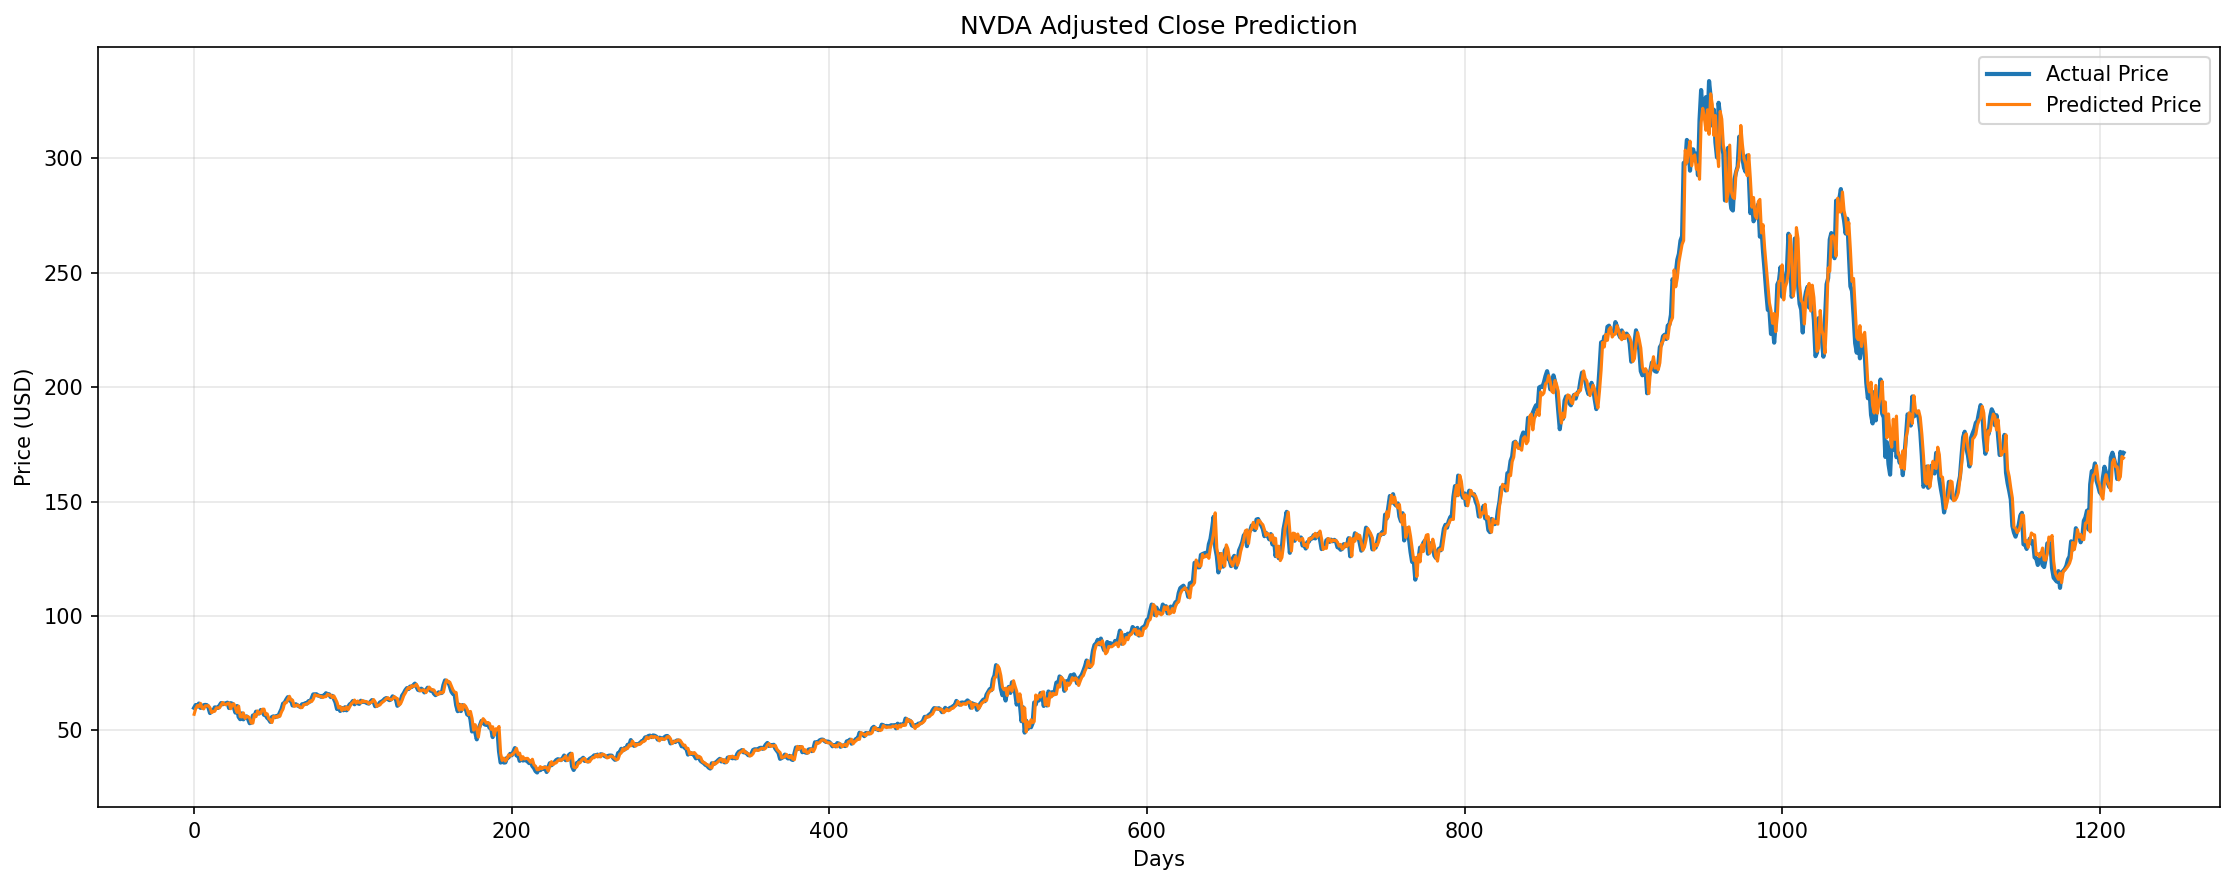

In [ ]:
# STEP 5C. VISUALIZATION

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6), dpi=150)

# Actual price
plt.plot(
    y_test_denorm.flatten(),
    label="Actual Price",
    linewidth=2
)
# Predicted price
plt.plot(
    y_pred_denorm.flatten(),
    label="Predicted Price",
    linewidth=1.5
)

plt.title("NVDA Adjusted Close Prediction")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Task 1.2 - Nasdaq k-th day forecast


In [ ]:
# STEP 3A. CREATE WINDOWED SAMPLES AND NORMALIZATION

# Input:
#    - X window: past `window_size` days
#    - y label: price at (t + k)

import numpy as np

def create_windowed_samples_with_target_norm_k(
    df,
    window_size,
    k,
    feature_indices,
    target_index,
    target_feature_idx
):

    # Extract raw feature matrix and target vector
    features = df.iloc[:, feature_indices].values.astype(float)
    targets  = df.iloc[:, target_index].values.astype(float)

    # Normalize with the same logic as task 1.1
    X_windows_norm = []
    y_windows_norm = []

    # Store scaling info for de-normalization
    target_mins  = []
    target_diffs = []

    # Iterate over valid window end positions
    # Last usable index is len(df) - k
    for i in range(window_size, len(df) - k + 1):
        # Slice input window: [t - window_size, ..., t - 1]
        window = features[i - window_size:i]

        # Compute per-feature min and max inside this window
        feature_mins  = window.min(axis=0)
        feature_maxes = window.max(axis=0)

        # Compute feature-wise ranges
        diffs = feature_maxes - feature_mins
        diffs[diffs == 0] = 1e-8  # avoid division by zero

        # Normalize input window per feature
        window_norm = (window - feature_mins) / diffs

        # Normalize k-th day target using the same window scale (day t + k)
        y_norm = (
            targets[i + k - 1] - feature_mins[target_feature_idx]
        ) / diffs[target_feature_idx]

        # Store normalized data
        X_windows_norm.append(window_norm)
        y_windows_norm.append(y_norm)

        # Store scaling info for later de-normalization
        target_mins.append(feature_mins[target_feature_idx])
        target_diffs.append(diffs[target_feature_idx])

    # Convert to numpy arrays
    X_windows_norm = np.array(X_windows_norm)
    y_windows_norm = np.array(y_windows_norm).reshape(-1, 1)

    target_mins  = np.array(target_mins).reshape(-1, 1)
    target_diffs = np.array(target_diffs).reshape(-1, 1)

    return X_windows_norm, y_windows_norm, target_mins, target_diffs

In [ ]:
# STEP 3B. APPLY TO EACH CV FOLD AND EACH STOCK

# Forecast horizon choice
K = 3

# Container to store windowed and normalized data per fold
# Structure:
#   fold_idx: {
#       "X_train": np.array,
#       "y_train": np.array,
#       "X_val":   np.array,
#       "y_val":   np.array
#   }

cv_windowed_data = {}

for fold_idx, fold_data in cv_raw_splits.items():
    # Lists to collect samples from all stocks
    X_train_all, y_train_all = [], []
    X_val_all,   y_val_all   = [], []

    for ticker in TICKERS:
        # Retrieve raw train and validation dataframes
        train_df = fold_data[ticker]["train_df"]
        val_df   = fold_data[ticker]["val_df"]

        # Create normalized training windows for this stock (k-th day ahead)
        X_train_stock, y_train_stock, _, _ = (
            create_windowed_samples_with_target_norm_k(
                train_df,
                WINDOW_SIZE,
                K,
                FEATURE_INDICES,
                TARGET_INDEX,
                target_feature_idx=FEATURE_INDICES.index(TARGET_INDEX)
            )
        )

        # Create normalized validation windows for this stock (k-th day ahead)
        X_val_stock, y_val_stock, _, _ = (
            create_windowed_samples_with_target_norm_k(
                val_df,
                WINDOW_SIZE,
                K,
                FEATURE_INDICES,
                TARGET_INDEX,
                target_feature_idx=FEATURE_INDICES.index(TARGET_INDEX)
            )
        )

        # Accumulate samples across stocks
        X_train_all.append(X_train_stock)
        y_train_all.append(y_train_stock)
        X_val_all.append(X_val_stock)
        y_val_all.append(y_val_stock)

    # Concatenate samples from all stocks along the sample axis
    cv_windowed_data[fold_idx] = {
        "X_train": np.concatenate(X_train_all, axis=0),
        "y_train": np.concatenate(y_train_all, axis=0),
        "X_val":   np.concatenate(X_val_all, axis=0),
        "y_val":   np.concatenate(y_val_all, axis=0),
    }

In [ ]:
# STEP 4A. BUILD THE MODEL ARCHITECTURE

import tensorflow as tf
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten,
    Dense, Dropout, Input, BatchNormalization
)
from tensorflow.keras.regularizers import l2

def build_model(window_size, num_features):

    model = tf.keras.Sequential()

    # Define input shape: (time_steps, features)
    model.add(Input(shape=(window_size, num_features)))

    # Convolutional block 1
    model.add(Conv1D(32, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    # Convolutional block 2
    model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    # Convolutional block 3
    model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    # Flatten
    model.add(Flatten())

    # Fully connected layers
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.3))

    # Output layer for 1 day
    model.add(Dense(1))

    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [ ]:
# STEP 4B. TRAIN FOR EACH CV FOLD

cv_results = {}

for fold_idx, data in cv_windowed_data.items():
    # Extract training and validation data for this fold
    X_train = data["X_train"]
    y_train = data["y_train"]
    X_val   = data["X_val"]
    y_val   = data["y_val"]

    # Build a fresh model for this CV fold
    model = build_model(
        window_size=WINDOW_SIZE,
        num_features=len(FEATURE_INDICES)
    )

    # Early stopping to prevent overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    # Train the model on the current fold
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        callbacks=[early_stop],
        verbose=1
    )

    # Evaluate model performance on validation data
    val_loss, val_mae = model.evaluate(X_val, y_val, verbose=0)

    # Store results for this fold
    cv_results[fold_idx] = {
        "history": history.history,
        "val_loss": val_loss,
        "val_mae": val_mae
    }


Epoch 1/30
855/855 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.2503 - mae: 0.3048 - val_loss: 0.1656 - val_mae: 0.2421
Epoch 2/30
855/855 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1485 - mae: 0.2406 - val_loss: 0.1403 - val_mae: 0.2265
Epoch 3/30
855/855 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1308 - mae: 0.2335 - val_loss: 0.1404 - val_mae: 0.2463
Epoch 4/30
855/855 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1179 - mae: 0.2300 - val_loss: 0.1271 - val_mae: 0.2375
Epoch 5/30
855/855 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1083 - mae: 0.2268 - val_loss: 0.1167 - val_mae: 0.2295
Epoch 6/30
855/855 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1034 - mae: 0.2256 - val_loss: 0.1087 - val_mae: 0.2225
Epoch 7/30
855/855 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0986 - mae: 0.2228 - val_loss: 0.1135 - val_mae: 0.2293
Epoch 8/30
855/855 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0952 - mae: 0.2197 - val_loss: 0.1188 - val_mae: 0.2354
Epoch 9/30
855/855 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - l

In [ ]:
# STEP 5A. CREATE NORMALIZED WINDOWS TO TEST FOR NVDA ONLY

TEST_TICKER = "NVDA"

# Retrieve raw data
df = raw_stock_data[TEST_TICKER]

# Select final test period
test_df = df[df["Date"] >= FINAL_TEST_DATE].reset_index(drop=True)

# Create normalized test windows + target scaling info for k-th day forecast
X_test_norm, y_test_norm, test_target_mins, test_target_diffs = (
    create_windowed_samples_with_target_norm_k(
        test_df,
        WINDOW_SIZE,
        K,
        FEATURE_INDICES,
        TARGET_INDEX,
        target_feature_idx=FEATURE_INDICES.index(TARGET_INDEX)
    )
)

In [ ]:
# STEP 5B. DE-NORMALIZATION AND EVALUATION

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predict normalized k-th day targets
y_pred_norm = model.predict(X_test_norm)

# De-normalize predictions to real price scale
# (using per-window target scaling information)
y_pred_denorm = y_pred_norm * test_target_diffs + test_target_mins

# De-normalize actual price in test set
y_test_denorm = y_test_norm * test_target_diffs + test_target_mins

# Compute evaluation metrics in real price space
mse_final = mean_squared_error(y_test_denorm, y_pred_denorm)
mae_final = mean_absolute_error(y_test_denorm, y_pred_denorm)

print("--- Final Test Results (NVDA, k = 3) ---")
print(f"MSE: {mse_final:.4f}")
print(f"MAE: {mae_final:.2f} USD per share")

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
--- Final Test Results (NVDA, k = 3) ---
MSE: 65.5472
MAE: 5.14 USD per share


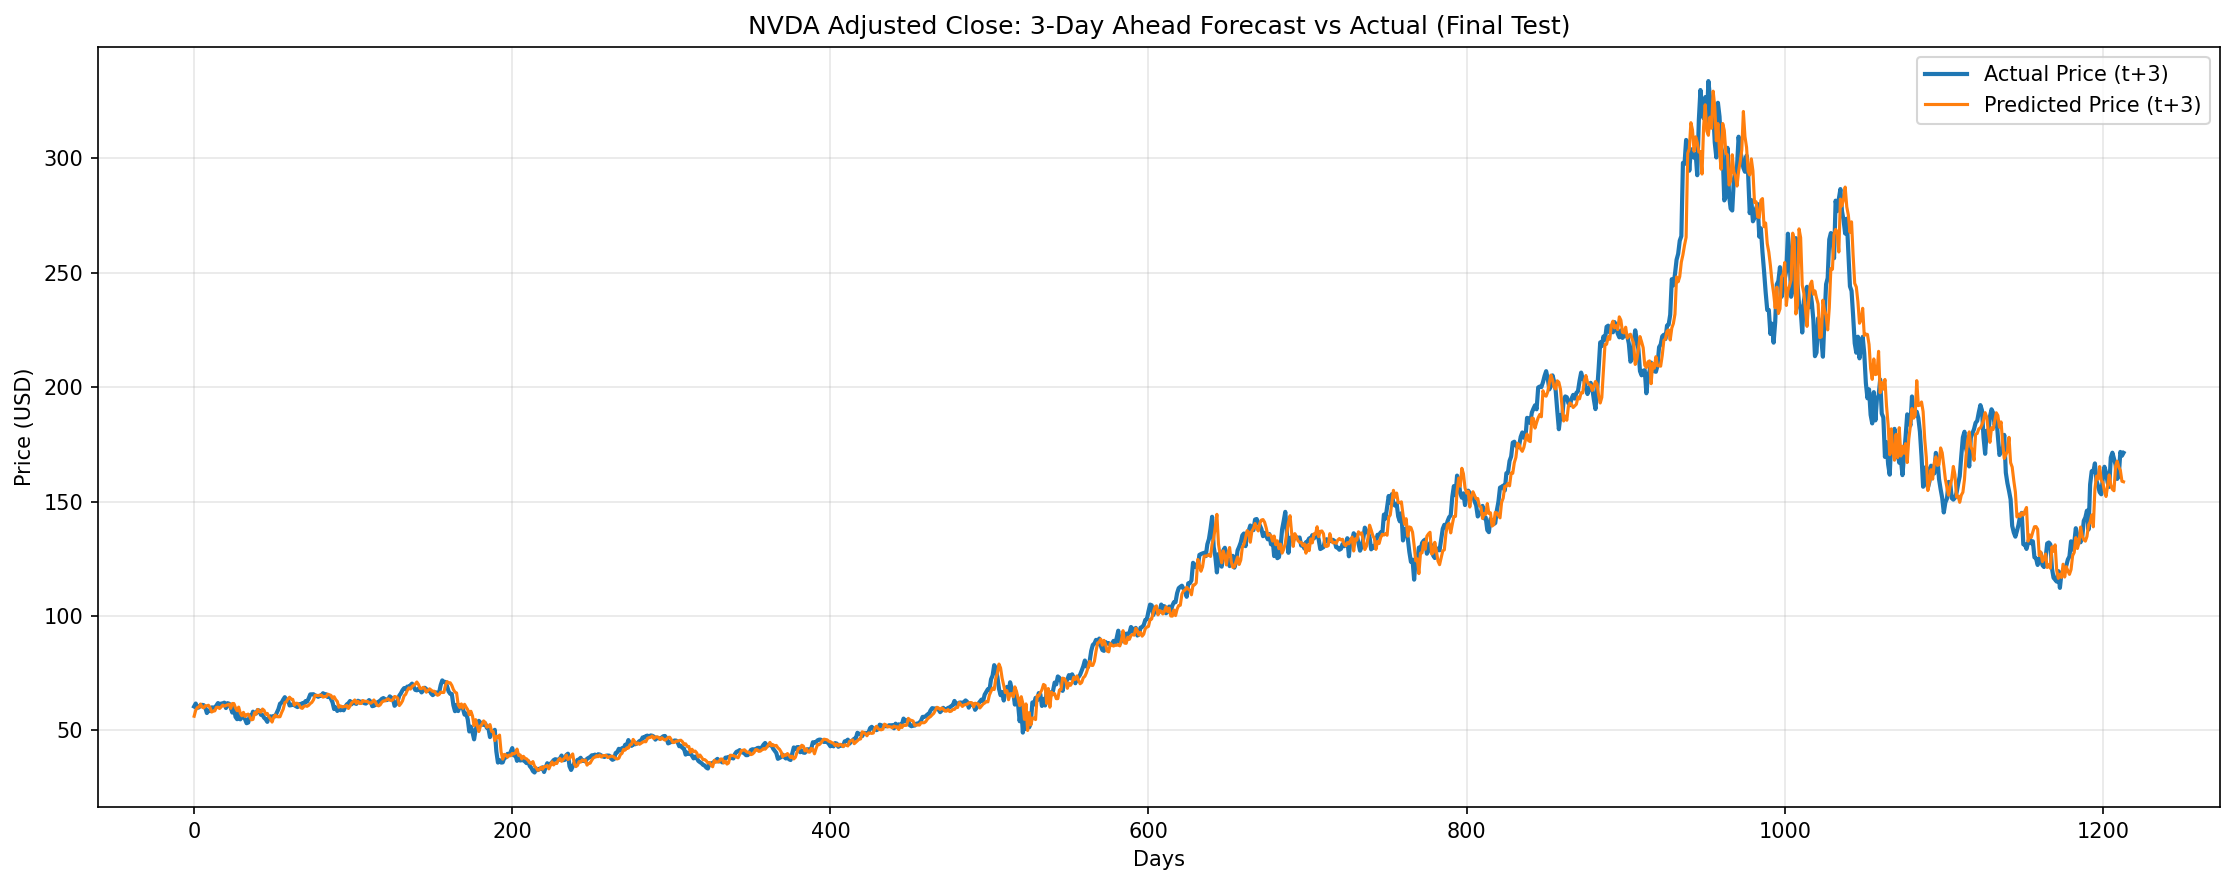

In [ ]:
# STEP 5C. VISUALIZATION

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6), dpi=150)

# Plot actual k-th day ahead prices
plt.plot(
    y_test_denorm.flatten(),
    label="Actual Price (t+3)",
    linewidth=2
)

# Plot predicted k-th day ahead prices
plt.plot(
    y_pred_denorm.flatten(),
    label="Predicted Price (t+3)",
    linewidth=1.5
)

# Formatting
plt.title("NVDA Adjusted Close: 3-Day Ahead Forecast vs Actual (Final Test)")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The further predicted horizon, the less accurate the forecast. This is expected in stock price prediction.

## Task 1.3 – Nasdaq k days forecast


In [ ]:
# STEP 3A. CREATE WINDOWED SAMPLES AND NORMALIZATION

# Input:
#    - X window: past `window_size` days
#    - y label: prices at [t+1, t+2, ..., t+k] (vector of length k)

import numpy as np

def create_windowed_samples_with_target_norm_k_days(
    df,
    window_size,
    k,
    feature_indices,
    target_index,
    target_feature_idx
):

    # Extract raw feature matrix and target vector
    features = df.iloc[:, feature_indices].values.astype(float)
    targets  = df.iloc[:, target_index].values.astype(float)

    # Normalization
    X_windows_norm = []
    y_windows_norm = []

    # Store scaling info for de-normalization later
    target_mins  = []
    target_diffs = []

    # Iterate over valid window end positions
    # Last usable index is len(df) - k
    for i in range(window_size, len(df) - k):
        # Slice input window: [t - window_size, ..., t - 1]
        window = features[i - window_size:i]

        # Compute per-feature min and max inside this window
        feature_mins  = window.min(axis=0)
        feature_maxes = window.max(axis=0)

        # Compute feature-wise ranges
        diffs = feature_maxes - feature_mins
        diffs[diffs == 0] = 1e-8  # avoid division by zero

        # Normalize input window (per feature)
        window_norm = (window - feature_mins) / diffs

        # Normalize k future targets using the SAME window scale
        # y = [price_{t+1}, price_{t+2}, ..., price_{t+k}]
        y_future = targets[i : i + k]
        y_norm = (y_future - feature_mins[target_feature_idx]) / diffs[target_feature_idx]

        # Store normalized data
        X_windows_norm.append(window_norm)
        y_windows_norm.append(y_norm)

        # Store scaling info for later de-normalization
        target_mins.append(feature_mins[target_feature_idx])
        target_diffs.append(diffs[target_feature_idx])

    # Convert to numpy arrays
    X_windows_norm = np.array(X_windows_norm)
    y_windows_norm = np.array(y_windows_norm)  # shape: (N, k)

    target_mins  = np.array(target_mins).reshape(-1, 1)
    target_diffs = np.array(target_diffs).reshape(-1, 1)

    return X_windows_norm, y_windows_norm, target_mins, target_diffs

In [ ]:
# STEP 3B. APPLY TO EACH CV FOLD AND EACH STOCK

# Forecast horizon (consecutive)
K = 3

# Container to store windowed and normalized data per fold
# Structure:
#   fold_idx: {
#       "X_train": np.array,   # shape: (N_train, WINDOW_SIZE, num_features)
#       "y_train": np.array,   # shape: (N_train, K)
#       "X_val":   np.array,   # shape: (N_val, WINDOW_SIZE, num_features)
#       "y_val":   np.array    # shape: (N_val, K)
#   }
cv_windowed_data = {}

for fold_idx, fold_data in cv_raw_splits.items():
    # Lists to collect samples from all stocks
    X_train_all, y_train_all = [], []
    X_val_all,   y_val_all   = [], []

    for ticker in TICKERS:
        # Retrieve raw train and validation dataframes
        train_df = fold_data[ticker]["train_df"]
        val_df   = fold_data[ticker]["val_df"]

        # Create normalized training windows for this stock (k-day ahead)
        X_train_stock, y_train_stock, _, _ = (
            create_windowed_samples_with_target_norm_k_days(
                train_df,
                WINDOW_SIZE,
                K,
                FEATURE_INDICES,
                TARGET_INDEX,
                target_feature_idx=FEATURE_INDICES.index(TARGET_INDEX)
            )
        )

        # Create normalized validation windows for this stock (k-day ahead)
        X_val_stock, y_val_stock, _, _ = (
            create_windowed_samples_with_target_norm_k_days(
                val_df,
                WINDOW_SIZE,
                K,
                FEATURE_INDICES,
                TARGET_INDEX,
                target_feature_idx=FEATURE_INDICES.index(TARGET_INDEX)
            )
        )

        # Accumulate samples across stocks
        X_train_all.append(X_train_stock)
        y_train_all.append(y_train_stock)
        X_val_all.append(X_val_stock)
        y_val_all.append(y_val_stock)

    # Concatenate samples from all stocks along the sample axis
    cv_windowed_data[fold_idx] = {
        "X_train": np.concatenate(X_train_all, axis=0),
        "y_train": np.concatenate(y_train_all, axis=0),
        "X_val":   np.concatenate(X_val_all, axis=0),
        "y_val":   np.concatenate(y_val_all, axis=0),
    }

In [ ]:
# STEP 4A: BUILD THE MODEL ARCHITECTURE

import tensorflow as tf
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten,
    Dense, Dropout, Input, BatchNormalization
)
from tensorflow.keras.regularizers import l2

def build_model(window_size, num_features):

    model = tf.keras.Sequential()

    # Define input shape: (time_steps, features)
    model.add(Input(shape=(window_size, num_features)))

    # Convolutional block 1
    model.add(Conv1D(32, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    # Convolutional block 2
    model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    # Convolutional block 3
    model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    # Flatten
    model.add(Flatten())

    # Fully connected layers
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.3))

    # Output layer for k-consecutive day
    model.add(Dense(3))

    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [ ]:
# STEP 4B. TRAIN MODEL FOR EACH CV FOLD

cv_results = {}

for fold_idx, data in cv_windowed_data.items():
    # Extract training and validation data for this fold
    X_train = data["X_train"]
    y_train = data["y_train"]
    X_val   = data["X_val"]
    y_val   = data["y_val"]

    # Build a fresh model for this CV fold
    model = build_model(
        window_size=WINDOW_SIZE,
        num_features=len(FEATURE_INDICES)
    )

    # Early stopping to prevent overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    # Train the model on the current fold
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        callbacks=[early_stop],
        verbose=1
    )

    # Evaluate model performance on validation data
    val_loss, val_mae = model.evaluate(X_val, y_val, verbose=0)

    # Store results for this fold
    cv_results[fold_idx] = {
        "history": history.history,
        "val_loss": val_loss,
        "val_mae": val_mae
    }

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - loss: 0.7497 - mae: 0.5757 - val_loss: 2.5775 - val_mae: 1.4918
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2206 - mae: 0.3043 - val_loss: 4.8170 - val_mae: 2.0556
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1851 - mae: 0.2725 - val_loss: 4.5948 - val_mae: 1.9859
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1692 - mae: 0.2521 - val_loss: 2.3993 - val_mae: 1.3568
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1572 - mae: 0.2416 - val_loss: 0.7048 - val_mae: 0.6661
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1441 - mae: 0.2251 - val_loss: 0.2935 - val_mae: 0.3767
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1393 - mae: 0.2185 - val_loss: 0.1716 - val_mae: 0.2559
Epoch 8/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1350 - mae: 0.2161 - val_loss: 0.1480 - val_mae: 0.2301
Epoch 9/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.12

In [ ]:
# STEP 5A. CREATE NORMALIZED WINDOWS TO TEST NVDA

TEST_TICKER = "NVDA"

# Retrieve raw data
df = raw_stock_data[TEST_TICKER]

# Select final test period
test_df = df[df["Date"] >= FINAL_TEST_DATE].reset_index(drop=True)

# Create normalized test windows + target scaling info
# y_test_norm has shape: (N_test, K)
X_test_norm, y_test_norm, test_target_mins, test_target_diffs = (
    create_windowed_samples_with_target_norm_k_days(
        test_df,
        WINDOW_SIZE,
        K,
        FEATURE_INDICES,
        TARGET_INDEX,
        target_feature_idx=FEATURE_INDICES.index(TARGET_INDEX)
    )
)

In [ ]:
# STEP 5B. DE-NORMALIZATION

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predict normalized k-day targets
y_pred_norm = model.predict(X_test_norm)

# 2. De-normalize predictions to real price scale
y_pred_denorm = y_pred_norm * test_target_diffs + test_target_mins

# 3. De-normalize actual price in the test set
y_test_denorm = y_test_norm * test_target_diffs + test_target_mins

# 4. Compute evaluation metrics
mse_final = mean_squared_error(
    y_test_denorm.reshape(-1),
    y_pred_denorm.reshape(-1)
)
mae_final = mean_absolute_error(
    y_test_denorm.reshape(-1),
    y_pred_denorm.reshape(-1)
)

print("--- Final Test Results (NVDA, k-day forecast) ---")
print(f"MSE: {mse_final:.4f}")
print(f"MAE: {mae_final:.2f} USD per share")


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
--- Final Test Results (NVDA, k-day forecast) ---
MSE: 49.4845
MAE: 4.29 USD per share


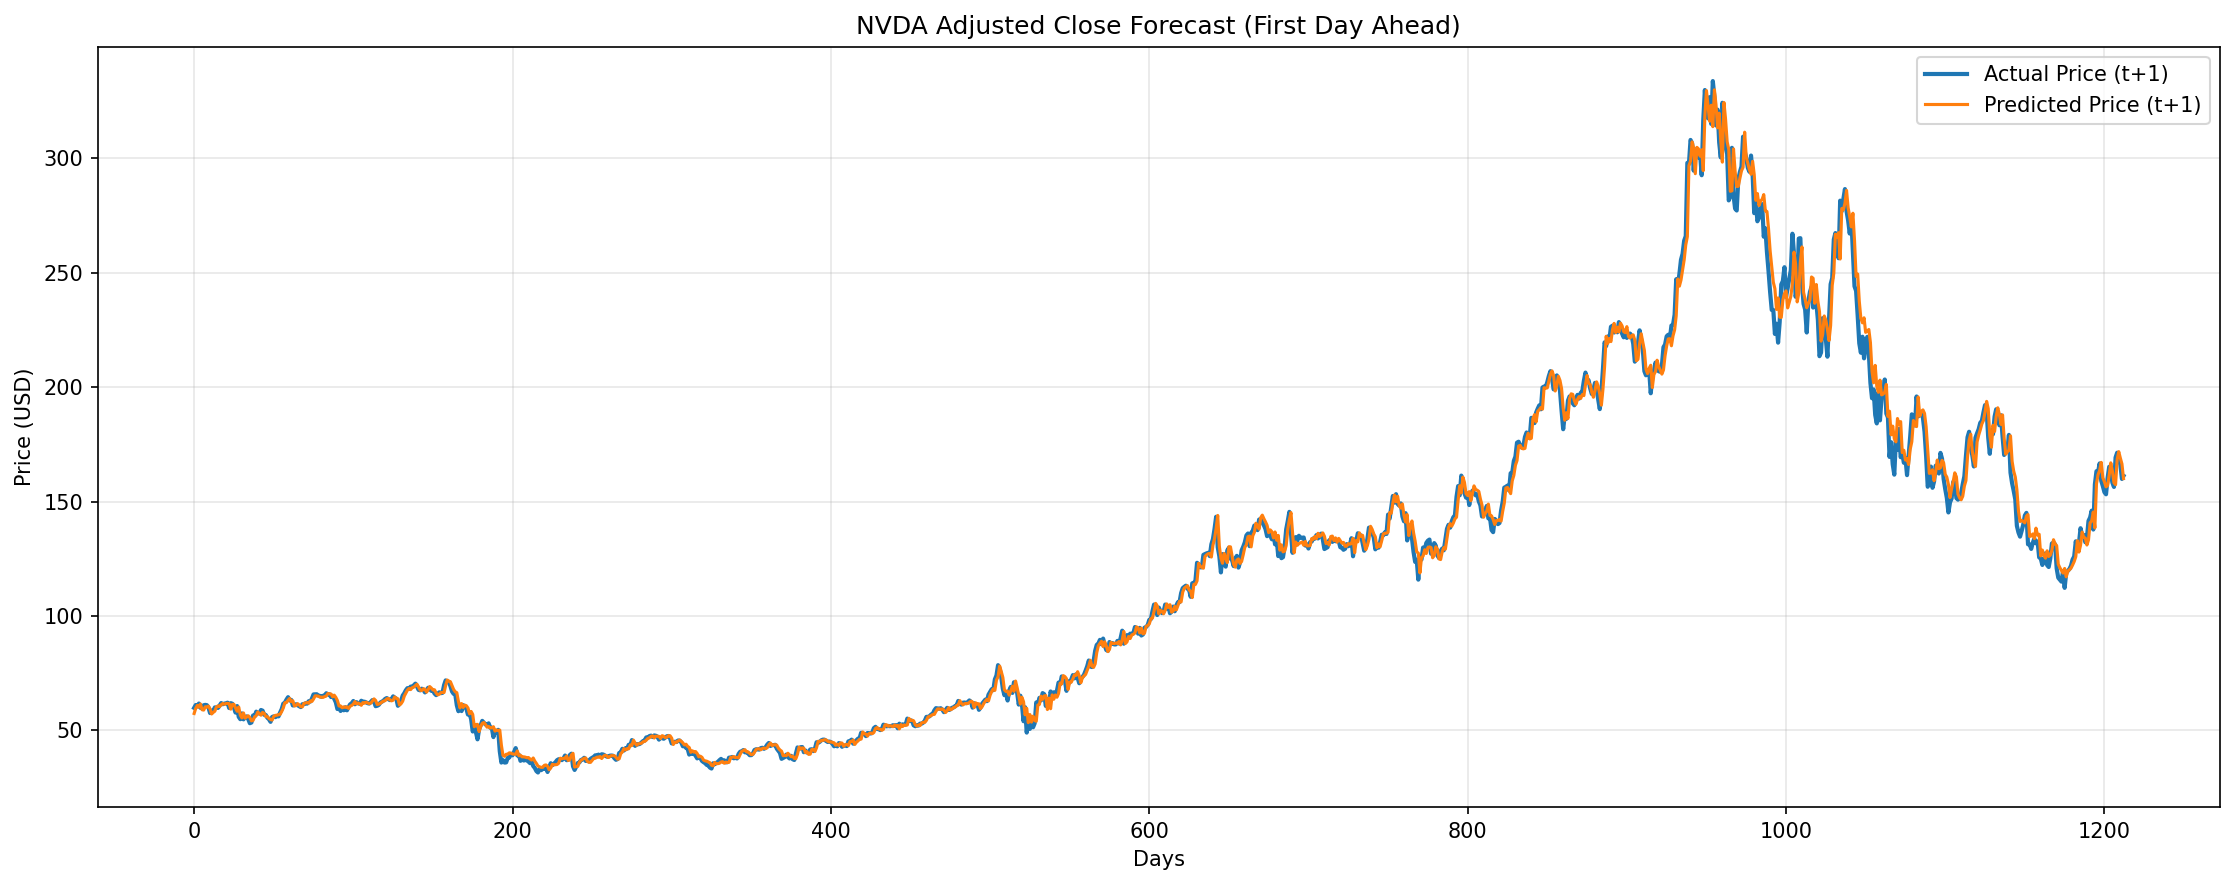

In [ ]:
# STEP 5C. VISUALIZATION

import matplotlib.pyplot as plt

# Visualize the first predicted day
plt.figure(figsize=(15, 6), dpi=150)

plt.plot(
    y_test_denorm[:, 0],
    label="Actual Price (t+1)",
    linewidth=2
)

plt.plot(
    y_pred_denorm[:, 0],
    label="Predicted Price (t+1)",
    linewidth=1.5
)

plt.title("NVDA Adjusted Close Forecast (First Day Ahead)")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

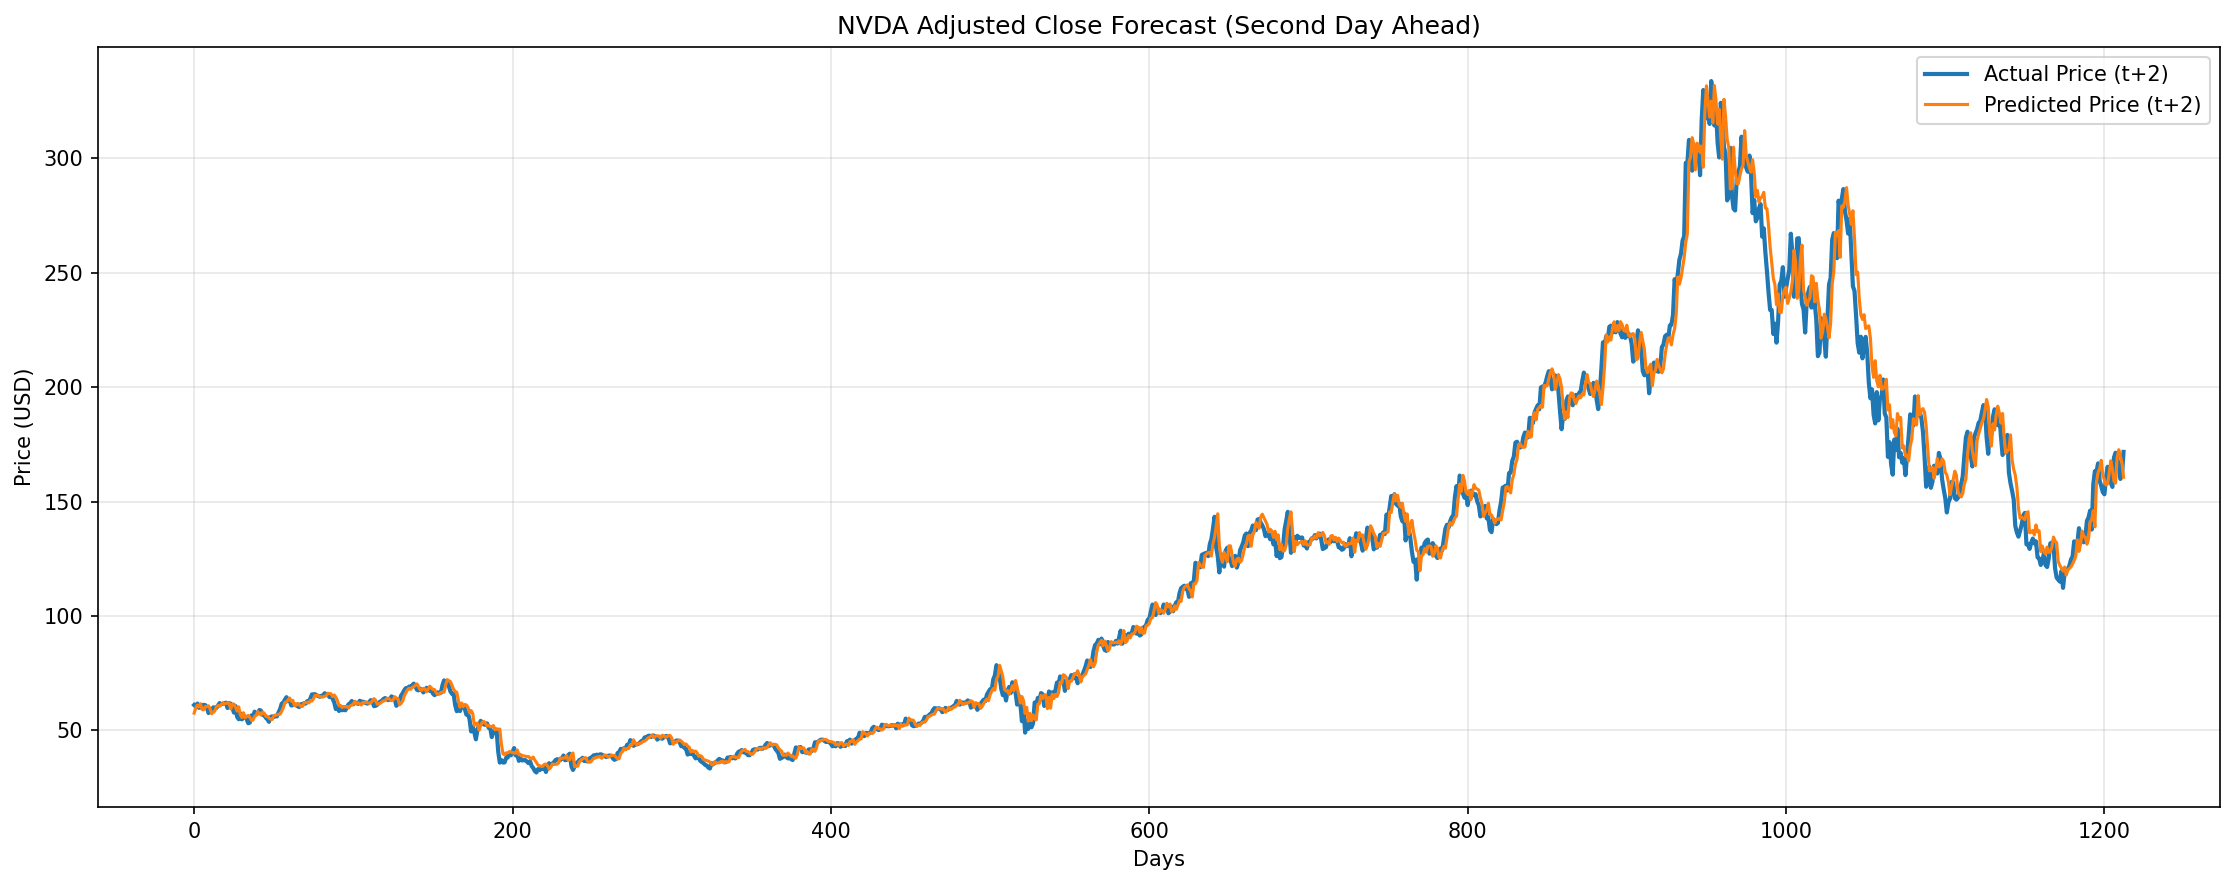

In [ ]:
# STEP 5C. VISUALIZATION

import matplotlib.pyplot as plt

# Visualize the second predicted day
plt.figure(figsize=(15, 6), dpi=150)

plt.plot(
    y_test_denorm[:, 1],
    label="Actual Price (t+2)",
    linewidth=2
)

plt.plot(
    y_pred_denorm[:, 1],
    label="Predicted Price (t+2)",
    linewidth=1.5
)

plt.title("NVDA Adjusted Close Forecast (Second Day Ahead)")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

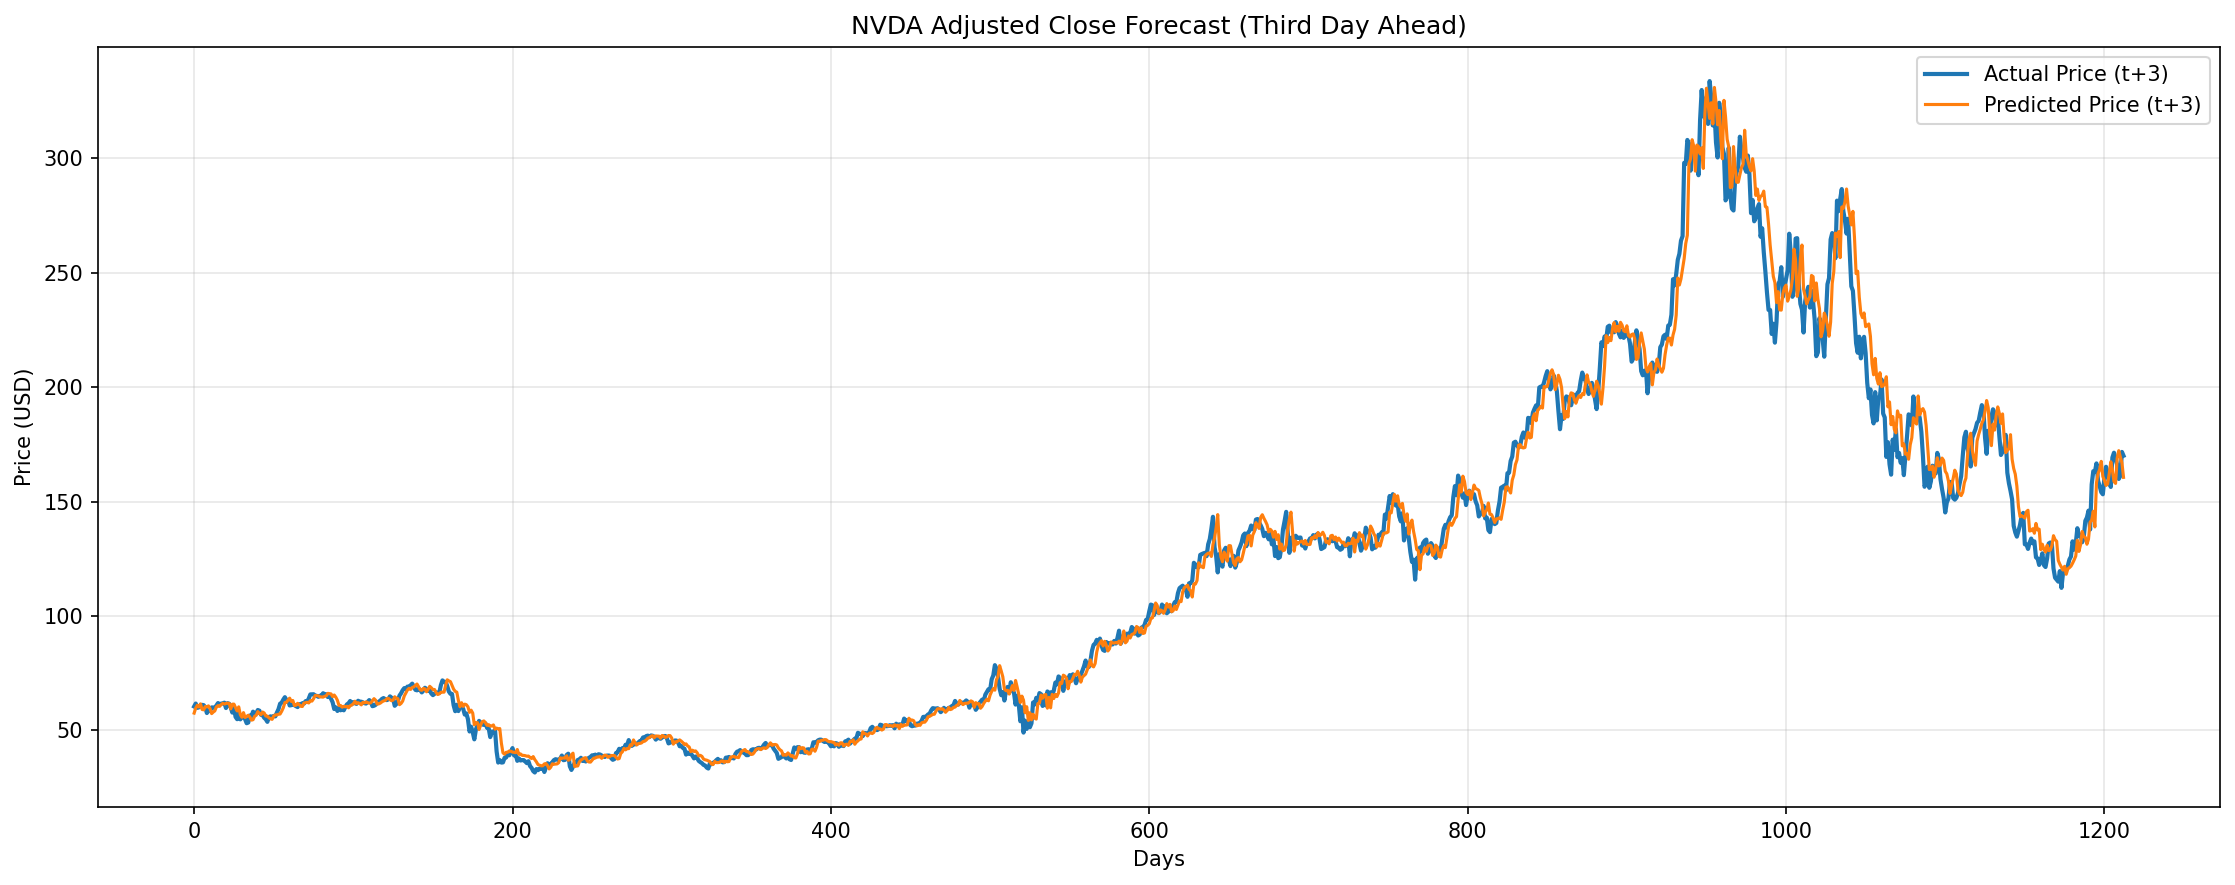

In [ ]:
# STEP 5C. VISUALIZATION

import matplotlib.pyplot as plt

# Visualize the third day
plt.figure(figsize=(15, 6), dpi=150)

plt.plot(
    y_test_denorm[:, 2],
    label="Actual Price (t+3)",
    linewidth=2
)

plt.plot(
    y_pred_denorm[:, 2],
    label="Predicted Price (t+3)",
    linewidth=1.5
)

plt.title("NVDA Adjusted Close Forecast (Third Day Ahead)")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Task 2 (15%) Vietnam stock price prediction (Vietnam dataset)

In [ ]:
# Directory
DATA_DIR = "/content/drive/MyDrive/..." # Fix this 

# Path to hose data
HOSE_DATA_DIR = DATA_DIR + "hose/"

We choose stocks of large companies in Vietnam to represent different industry sectors, from technology, energy to retail and services.

In [ ]:
# List of selected hose tickers
# These tickers will be iterated over to build a multi-stock dataset
TICKERS = [
    "BID", "FPT", "GAS", "HPG", "HSG", "MBB",
    "MWG", "CTG", "SSI", "VCB", "VIC", "VNM"
]

stock_date_info = []

for ticker in TICKERS:
    file_path = os.path.join(HOSE_DATA_DIR, f"{ticker}-VNINDEX-History.csv")
    try:
        df = pd.read_csv(file_path)
        df['TradingDate'] = pd.to_datetime(df['TradingDate'], dayfirst=True, format='mixed', utc=True)
        start_date = df['TradingDate'].min().strftime('%Y-%m-%d')
        end_date = df['TradingDate'].max().strftime('%Y-%m-%d')
        stock_date_info.append({
            'Ticker': ticker,
            'Start Date': start_date,
            'End Date': end_date,
            'Total Days': len(df)
        })
    except FileNotFoundError:
        print(f"Warning: {ticker}.csv not found at {file_path}")
    except Exception as e:
        print(f"Error processing {ticker}: {e}")

dates_df = pd.DataFrame(stock_date_info)
print("HOSE Stock Data Overview:")
print(dates_df.to_markdown(index=False))

HOSE Stock Data Overview:
| Ticker   | Start Date   | End Date   |   Total Days |
|:---------|:-------------|:-----------|-------------:|
| BID      | 2014-01-24   | 2023-02-28 |         2267 |
| FPT      | 2006-12-13   | 2023-02-28 |         4038 |
| GAS      | 2012-05-21   | 2023-02-28 |         2692 |
| HPG      | 2007-11-15   | 2023-02-28 |         3809 |
| HSG      | 2008-12-05   | 2023-02-28 |         3551 |
| MBB      | 2011-11-01   | 2023-02-28 |         2827 |
| MWG      | 2014-07-14   | 2023-02-28 |         2157 |
| CTG      | 2009-07-16   | 2023-02-28 |         3401 |
| SSI      | 2006-12-15   | 2023-02-28 |         4026 |
| VCB      | 2009-06-30   | 2023-02-28 |         3413 |
| VIC      | 2007-09-19   | 2023-02-28 |         3850 |
| VNM      | 2006-01-19   | 2023-02-28 |         4264 |


In [ ]:
# STEP 0: GLOBAL DESGIN

# Number of past trading days used as input features
WINDOW_SIZE = 30

# Forecast horizon (days)
FORECAST_HORIZON = 1

# Global time-based split to separate training and testing data
SPLIT_DATE = "2019-01-01"

# Feature names
FEATURE_NAMES = [
    "Open",
    "Close",
    "High",
    "Low",
    "Volume"
]

# Feature indices
FEATURE_INDICES = [1, 4, 2, 3, 5]

# Label
TARGET_NAME = "Close"
TARGET_INDEX = 4

In [ ]:
# STEP 1A: DEFINE TIME-SERIES CV PARAMETERS

# Earliest date that all selected Vietnam stocks have data after
CV_START_DATE = "2015-01-01"

# Final test split date (the same as split date)
FINAL_TEST_DATE = "2019-01-01"

# Length of each validation period (in years)
VAL_YEARS = 1

# Number of cross-validation folds
N_FOLDS = 3

In [ ]:
# STEP 1B: BUILD EXPANDING-WINDOW CV FOLDS

from datetime import datetime

# Convert string dates to datetime for arithmetic
cv_start = datetime.strptime(CV_START_DATE, "%Y-%m-%d")
final_test_date = datetime.strptime(FINAL_TEST_DATE, "%Y-%m-%d")

# Container to store CV fold definitions
cv_folds = []

# Build folds using an expanding yearly training window
for i in range(N_FOLDS):
    # Training always starts from the same initial date
    train_start = cv_start

    # Training end increases by 1 year per fold
    train_end = datetime(cv_start.year + i + 1, 1, 1)

    # Validation period immediately follows the training period
    val_start = train_end
    val_end = datetime(val_start.year + VAL_YEARS, 1, 1)

    # Ensure validation period does not overlap with final test set
    if val_end >= final_test_date:
        break

    # Store fold definition
    cv_folds.append({
        "train_start": train_start.strftime("%Y-%m-%d"),
        "train_end": train_end.strftime("%Y-%m-%d"),
        "val_start": val_start.strftime("%Y-%m-%d"),
        "val_end": val_end.strftime("%Y-%m-%d"),
    })

print(cv_folds)

[{'train_start': '2015-01-01', 'train_end': '2016-01-01', 'val_start': '2016-01-01', 'val_end': '2017-01-01'}, {'train_start': '2015-01-01', 'train_end': '2017-01-01', 'val_start': '2017-01-01', 'val_end': '2018-01-01'}]


In [ ]:
# STEP 2A: LOAD RAW DATA FOR EACH STOCK

# Helper function to load Vietnam stock data
def load_stock_data(ticker, data_dir):
    # Construct file path for the ticker CSV
    file_path = os.path.join(data_dir, f"{ticker}-VNINDEX-History.csv")

    # Read CSV file
    df = pd.read_csv(file_path)

    # Convert Date column to datetime
    # Vietnamese datasets typically use day-first format (DD-MM-YYYY)
    df["TradingDate"] = pd.to_datetime(df["TradingDate"], dayfirst=True, format='mixed', utc=True)

    # Sort data chronologically
    df = df.sort_values("TradingDate").reset_index(drop=True)

    # Extract raw feature matrix and target vector based on global indices
    raw_data = df.iloc[:, FEATURE_INDICES].values
    raw_target = df.iloc[:, TARGET_INDEX].values.reshape(-1, 1)

    return raw_data, raw_target, FEATURE_INDICES, TARGET_INDEX, df

# Dictionary to store raw dataframes for each ticker
raw_stock_data = {}

for ticker in TICKERS:
    # Load raw data using the helper function
    _, _, _, _, df = load_stock_data(ticker, HOSE_DATA_DIR)

    # Ensure Date column is in datetime format
    df["TradingDate"] = pd.to_datetime(df["TradingDate"], format='mixed', utc=True)

    # Sort again to enforce strict chronological order
    df = df.sort_values("TradingDate").reset_index(drop=True)

    # Store cleaned raw dataframe
    raw_stock_data[ticker] = df

In [ ]:
# STEP 2B: SPLIT RAW DATA PER CV FOLD AND PER STOCK

# Container to store fold-specific raw splits
# Structure:
#   fold_idx: {
#       ticker: {
#           "train_df": DataFrame,
#           "val_df": DataFrame
#       }
#   }

cv_raw_splits = {}

for fold_idx, fold in enumerate(cv_folds):
    # Initialize storage for this fold
    cv_raw_splits[fold_idx] = {}

    # Extract fold boundaries and convert to datetime
    # Ensure they are UTC-aware to match the 'TradingDate' column
    train_start = pd.to_datetime(fold["train_start"], utc=True)
    train_end   = pd.to_datetime(fold["train_end"], utc=True)
    val_start   = pd.to_datetime(fold["val_start"], utc=True)
    val_end     = pd.to_datetime(fold["val_end"], utc=True)

    for ticker in TICKERS:
        # Retrieve raw dataframe for the current ticker
        df = raw_stock_data[ticker]

        # Select training data for this fold
        train_df = df[
            (df["TradingDate"] >= train_start) &
            (df["TradingDate"] < train_end)
        ].reset_index(drop=True)

        # Select validation data for this fold
        val_df = df[
            (df["TradingDate"] >= val_start) &
            (df["TradingDate"] < val_end)
        ].reset_index(drop=True)

        # Store raw splits for this ticker and fold
        cv_raw_splits[fold_idx][ticker] = {
            "train_df": train_df,
            "val_df": val_df
        }
print(cv_raw_splits)


{0: {'BID': {'train_df':      Unnamed: 0     Open     High      Low    Close   Volume  \
0           231   8059.0   8122.0   8059.0   8059.0    66380   
1           232   7997.0   8309.0   7997.0   8247.0   403170   
2           233   8247.0   8497.0   8184.0   8497.0   830630   
3           234   8497.0   8622.0   8372.0   8497.0   798240   
4           235   8497.0   9059.0   8497.0   9059.0  3291280   
..          ...      ...      ...      ...      ...      ...   
243         474  14193.0  14401.0  14124.0  14124.0  1179440   
244         475  14124.0  14193.0  13847.0  13986.0  1567150   
245         476  14055.0  14332.0  13916.0  14332.0   979430   
246         477  14332.0  14609.0  14332.0  14401.0  1242400   
247         478  14332.0  14470.0  14193.0  14262.0  1000490   

                  TradingDate  
0   2015-01-05 00:00:00+00:00  
1   2015-01-06 00:00:00+00:00  
2   2015-01-07 00:00:00+00:00  
3   2015-01-08 00:00:00+00:00  
4   2015-01-09 00:00:00+00:00  
..            

## Task 2.1 - Vietnam multi-feature extension


In [ ]:
# STEP 3A: CREATE WINDOWED SAMPLES

def create_windowed_samples_with_target_norm(
    df,
    window_size,
    feature_indices,
    target_index,
    target_feature_idx
):

    # Extract raw feature matrix and target vector
    features = df.iloc[:, feature_indices].values.astype(float)
    targets  = df.iloc[:, target_index].values.astype(float)

    X_windows_norm = []
    y_windows_norm = []

    # Store scaling info for de-normalization (used later test set)
    target_mins  = []
    target_diffs = []

    # Generate sliding windows
    for i in range(window_size, len(df)):
        # Slice one input window of size `window_size`
        window = features[i - window_size:i]

        # Compute per-feature min and max inside this window
        feature_mins  = window.min(axis=0)
        feature_maxes = window.max(axis=0)

        # Compute feature-wise ranges
        diffs = feature_maxes - feature_mins
        diffs[diffs == 0] = 1e-8 #  avoid division by zero

        # Normalize input window (per feature)
        window_norm = (window - feature_mins) / diffs

        # Normalize target (Close price at t+1)
        y_norm = (
            targets[i] - feature_mins[target_feature_idx]
        ) / diffs[target_feature_idx]

        # Store normalized samples
        X_windows_norm.append(window_norm)
        y_windows_norm.append(y_norm)

        # Store scaling info for later de-normalization
        target_mins.append(feature_mins[target_feature_idx])
        target_diffs.append(diffs[target_feature_idx])

    # Convert lists to numpy arrays
    X_windows_norm = np.array(X_windows_norm)
    y_windows_norm = np.array(y_windows_norm).reshape(-1, 1)

    target_mins  = np.array(target_mins).reshape(-1, 1)
    target_diffs = np.array(target_diffs).reshape(-1, 1)

    return X_windows_norm, y_windows_norm, target_mins, target_diffs

In [ ]:
# STEP 3B: APPLY WINDOWING + NORMALIZATION

# Container to store windowed and normalized data per fold
# Structure:
#   fold_idx: {
#       "X_train": np.array,
#       "y_train": np.array,
#       "X_val":   np.array,
#       "y_val":   np.array
#   }

cv_windowed_data = {}

for fold_idx, fold_data in cv_raw_splits.items():
    # Lists to collect samples from all stocks
    X_train_all, y_train_all = [], []
    X_val_all,   y_val_all   = [], []

    for ticker in TICKERS:
        # Retrieve raw train and validation dataframes for this ticker
        train_df = fold_data[ticker]["train_df"]
        val_df   = fold_data[ticker]["val_df"]

        # Create normalized training windows
        X_train_stock, y_train_stock, _, _ = create_windowed_samples_with_target_norm(
            train_df,
            WINDOW_SIZE,
            FEATURE_INDICES,
            TARGET_INDEX,
            target_feature_idx=FEATURE_INDICES.index(TARGET_INDEX)
        )

        # Create normalized validation windows
        X_val_stock, y_val_stock, _, _ = create_windowed_samples_with_target_norm(
            val_df,
            WINDOW_SIZE,
            FEATURE_INDICES,
            TARGET_INDEX,
            target_feature_idx=FEATURE_INDICES.index(TARGET_INDEX)
        )

        # Accumulate samples across stocks
        X_train_all.append(X_train_stock)
        y_train_all.append(y_train_stock)
        X_val_all.append(X_val_stock)
        y_val_all.append(y_val_stock)

    # Concatenate samples from all stocks along the sample axis
    cv_windowed_data[fold_idx] = {
        "X_train": np.concatenate(X_train_all, axis=0),
        "y_train": np.concatenate(y_train_all, axis=0),
        "X_val":   np.concatenate(X_val_all, axis=0),
        "y_val":   np.concatenate(y_val_all, axis=0),
    }

In [ ]:
# STEP 4A: BUILD THE DEEP LEARNING MODEL

import tensorflow as tf
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten,
    Dense, Dropout, Input, BatchNormalization
)
from tensorflow.keras.regularizers import l2

def build_model(window_size, num_features):
    model = tf.keras.Sequential()

    # Define input shape
    model.add(Input(shape=(window_size, num_features)))

    # Convolutional block 1
    model.add(Conv1D(32, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    # Convolutional block 2
    model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    # Convolutional block 3
    model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    # Flatten temporal features
    model.add(Flatten())

    # Fully connected layers
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.3))

    # Output layer for 1-day ahead forecasr
    model.add(Dense(1))

    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [ ]:
# STEP 4B: TRAIN AND VALIDATE MODEL FOR EACH CV FOLD

# Container to store training histories and validation metrics
cv_results = {}

for fold_idx, data in cv_windowed_data.items():
    # Extract training and validation data for this fold
    X_train = data["X_train"]
    y_train = data["y_train"]
    X_val   = data["X_val"]
    y_val   = data["y_val"]

    # Build a model for this CV fold
    model = build_model(
        window_size=WINDOW_SIZE,
        num_features=len(FEATURE_INDICES)
    )

    # Early stopping to prevent overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    # Train the model on the current fold
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        callbacks=[early_stop],
        verbose=1
    )

    # Evaluate model performance on validation data
    val_loss, val_mae = model.evaluate(X_val, y_val, verbose=0)

    # Store results for this fold
    cv_results[fold_idx] = {
        "history": history.history,
        "val_loss": val_loss,
        "val_mae": val_mae
    }


Epoch 1/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - loss: 1.2099 - mae: 0.7259 - val_loss: 0.2124 - val_mae: 0.3333
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.2172 - mae: 0.3102 - val_loss: 0.2069 - val_mae: 0.3146
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1653 - mae: 0.2540 - val_loss: 0.3185 - val_mae: 0.4118
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1432 - mae: 0.2297 - val_loss: 0.3599 - val_mae: 0.4378
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1306 - mae: 0.2123 - val_loss: 0.2687 - val_mae: 0.3580
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1240 - mae: 0.2029 - val_loss: 0.2001 - val_mae: 0.2913
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1156 - mae: 0.1920 - val_loss: 0.1634 - val_mae: 0.2499
Epoch 8/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1094 - mae: 0.1826 - val_loss: 0.1460 - val_mae: 0.2324
Epoch 9/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1071 - ma

In [ ]:
# STEP 5A. CREATE NORMALIZED WINDOWS FOR FPT

TEST_TICKER = "FPT"

# Retrieve raw data for the selected stock
df = raw_stock_data[TEST_TICKER]

# Select final test period
test_df = df[df["TradingDate"] >= FINAL_TEST_DATE].reset_index(drop=True)

# Create normalized test windows and target scaling information
X_test_norm, y_test_norm, test_target_mins, test_target_diffs = (
    create_windowed_samples_with_target_norm(
        test_df,
        WINDOW_SIZE,
        FEATURE_INDICES,
        TARGET_INDEX,
        target_feature_idx=FEATURE_INDICES.index(TARGET_INDEX)
    )
)

In [ ]:
# STEP 5B. INFERENCE AND DE-NORMALIZATION

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predict normalized targets on the final test set
y_pred_norm = model.predict(X_test_norm)

# De-normalize predictions back to real price scale
# Uses per-window scaling information stored during Step 3A
y_pred_denorm = y_pred_norm * test_target_diffs + test_target_mins

# De-normalize actual test set
y_test_denorm = y_test_norm * test_target_diffs + test_target_mins

# Compute evaluation metrics in real price space
mse_final = mean_squared_error(y_test_denorm, y_pred_denorm)
mae_final = mean_absolute_error(y_test_denorm, y_pred_denorm)

print(f"--- Final Test Results ({TEST_TICKER}) ---")
print(f"MSE: {mse_final:.4f}")
print(f"MAE: {mae_final:.2f} VND per share")


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
--- Final Test Results (FPT) ---
MSE: 1657376.7180
MAE: 846.95 VND per share


MAE of 847 VND per share is a good result for Vietnam's stock market.

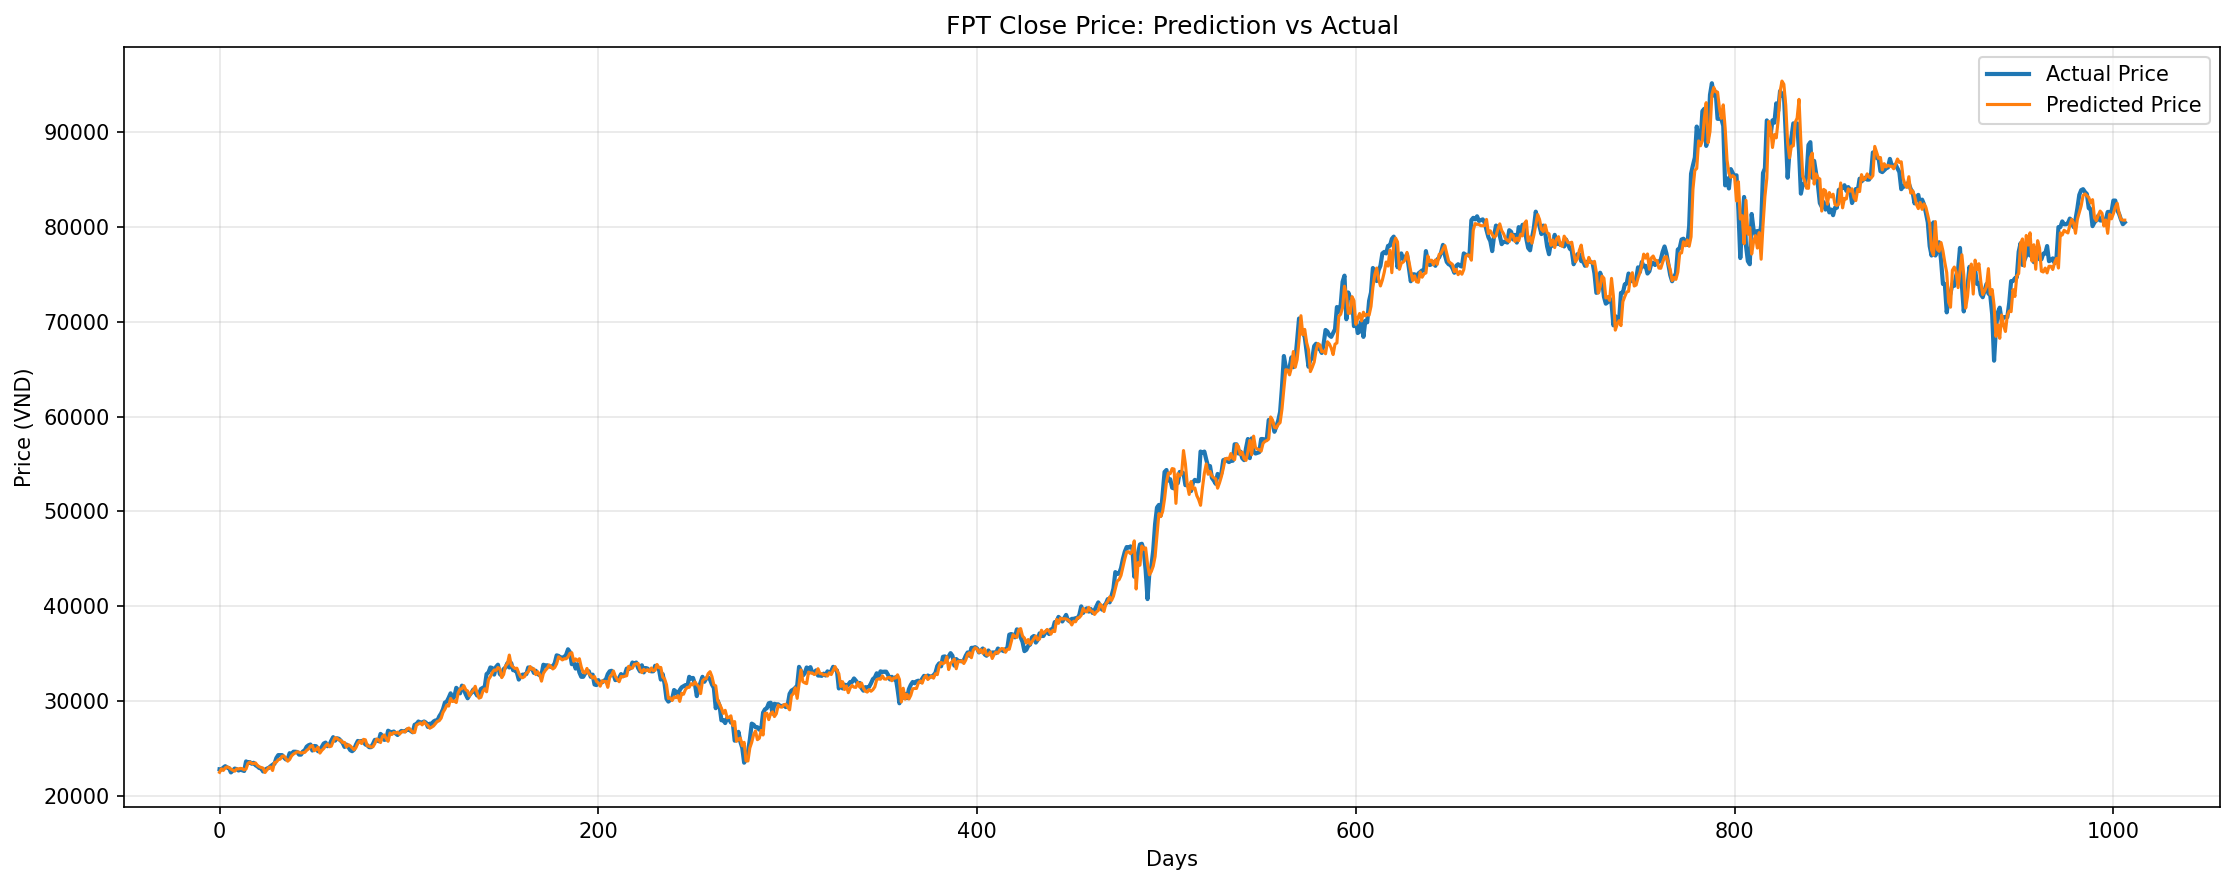

In [ ]:
# STEP 5C. VISUALIZATION

plt.figure(figsize=(15, 6), dpi=150)

# Plot actual Close prices
plt.plot(
    y_test_denorm.flatten(),
    label="Actual Price",
    linewidth=2
)

# Plot predicted Close prices
plt.plot(
    y_pred_denorm.flatten(),
    label="Predicted Price",
    linewidth=1.5
)

# Formatting
plt.title(f"{TEST_TICKER} Close Price: Prediction vs Actual")
plt.xlabel("Days")
plt.ylabel("Price (VND)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Task 2.2 - Vietnam k-th day forecast


In [ ]:
# STEP 3A. CREATE WINDOWED SAMPLES AND NORMALIZATION

# Input:
#    - X window: past `window_size` days
#    - y label: price at (t + k)

import numpy as np

def create_windowed_samples_with_target_norm_k(
    df,
    window_size,
    k,
    feature_indices,
    target_index,
    target_feature_idx
):

    # Extract raw feature matrix and target vector
    features = df.iloc[:, feature_indices].values.astype(float)
    targets  = df.iloc[:, target_index].values.astype(float)

    # Normalize with the same logic as task 1.1
    X_windows_norm = []
    y_windows_norm = []

    # Store scaling info for de-normalization
    target_mins  = []
    target_diffs = []

    # Iterate over valid window end positions
    # Last usable index is len(df) - k
    for i in range(window_size, len(df) - k + 1):
        # Slice input window: [t - window_size, ..., t - 1]
        window = features[i - window_size:i]

        # Compute per-feature min and max inside this window
        feature_mins  = window.min(axis=0)
        feature_maxes = window.max(axis=0)

        # Compute feature-wise ranges
        diffs = feature_maxes - feature_mins
        diffs[diffs == 0] = 1e-8  # avoid division by zero

        # Normalize input window per feature
        window_norm = (window - feature_mins) / diffs

        # Normalize k-th day target using the same window scale (day t + k)
        y_norm = (
            targets[i + k - 1] - feature_mins[target_feature_idx]
        ) / diffs[target_feature_idx]

        # Store normalized data
        X_windows_norm.append(window_norm)
        y_windows_norm.append(y_norm)

        # Store scaling info for later de-normalization
        target_mins.append(feature_mins[target_feature_idx])
        target_diffs.append(diffs[target_feature_idx])

    # Convert to numpy arrays
    X_windows_norm = np.array(X_windows_norm)
    y_windows_norm = np.array(y_windows_norm).reshape(-1, 1)

    target_mins  = np.array(target_mins).reshape(-1, 1)
    target_diffs = np.array(target_diffs).reshape(-1, 1)

    return X_windows_norm, y_windows_norm, target_mins, target_diffs

In [ ]:
# STEP 3B. APPLY TO EACH CV FOLD AND EACH STOCK

# Forecast horizon choice
K = 3

# Container to store windowed and normalized data per fold
# Structure:
#   fold_idx: {
#       "X_train": np.array,
#       "y_train": np.array,
#       "X_val":   np.array,
#       "y_val":   np.array
#   }

cv_windowed_data = {}

for fold_idx, fold_data in cv_raw_splits.items():
    # Lists to collect samples from all stocks
    X_train_all, y_train_all = [], []
    X_val_all,   y_val_all   = [], []

    for ticker in TICKERS:
        # Retrieve raw train and validation dataframes
        train_df = fold_data[ticker]["train_df"]
        val_df   = fold_data[ticker]["val_df"]

        # Create normalized training windows for this stock (k-th day ahead)
        X_train_stock, y_train_stock, _, _ = (
            create_windowed_samples_with_target_norm_k(
                train_df,
                WINDOW_SIZE,
                K,
                FEATURE_INDICES,
                TARGET_INDEX,
                target_feature_idx=FEATURE_INDICES.index(TARGET_INDEX)
            )
        )

        # Create normalized validation windows for this stock (k-th day ahead)
        X_val_stock, y_val_stock, _, _ = (
            create_windowed_samples_with_target_norm_k(
                val_df,
                WINDOW_SIZE,
                K,
                FEATURE_INDICES,
                TARGET_INDEX,
                target_feature_idx=FEATURE_INDICES.index(TARGET_INDEX)
            )
        )

        # Accumulate samples across stocks
        X_train_all.append(X_train_stock)
        y_train_all.append(y_train_stock)
        X_val_all.append(X_val_stock)
        y_val_all.append(y_val_stock)

    # Concatenate samples from all stocks along the sample axis
    cv_windowed_data[fold_idx] = {
        "X_train": np.concatenate(X_train_all, axis=0),
        "y_train": np.concatenate(y_train_all, axis=0),
        "X_val":   np.concatenate(X_val_all, axis=0),
        "y_val":   np.concatenate(y_val_all, axis=0),
    }

In [ ]:
# STEP 4A: BUILD THE DEEP LEARNING MODEL

import tensorflow as tf
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten,
    Dense, Dropout, Input, BatchNormalization
)
from tensorflow.keras.regularizers import l2

def build_model(window_size, num_features):
    model = tf.keras.Sequential()

    # Define input shape
    model.add(Input(shape=(window_size, num_features)))

    # Convolutional block 1
    model.add(Conv1D(32, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    # Convolutional block 2
    model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    # Convolutional block 3
    model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    # Flatten temporal features
    model.add(Flatten())

    # Fully connected layers
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.3))

    # Output layer for 1-day ahead forecasr
    model.add(Dense(1))

    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [ ]:
# STEP 4B: TRAIN AND VALIDATE MODEL FOR EACH CV FOLD

# Container to store training histories and validation metrics
cv_results = {}

for fold_idx, data in cv_windowed_data.items():
    # Extract training and validation data for this fold
    X_train = data["X_train"]
    y_train = data["y_train"]
    X_val   = data["X_val"]
    y_val   = data["y_val"]

    # Build a model for this CV fold
    model = build_model(
        window_size=WINDOW_SIZE,
        num_features=len(FEATURE_INDICES)
    )

    # Early stopping to prevent overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    # Train the model on the current fold
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        callbacks=[early_stop],
        verbose=1
    )

    # Evaluate model performance on validation data
    val_loss, val_mae = model.evaluate(X_val, y_val, verbose=0)

    # Store results for this fold
    cv_results[fold_idx] = {
        "history": history.history,
        "val_loss": val_loss,
        "val_mae": val_mae
    }


Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.8048 - mae: 0.6137 - val_loss: 0.4558 - val_mae: 0.5106
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2308 - mae: 0.3127 - val_loss: 0.6027 - val_mae: 0.6191
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1890 - mae: 0.2726 - val_loss: 0.8195 - val_mae: 0.7598
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1680 - mae: 0.2494 - val_loss: 0.6613 - val_mae: 0.6521
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1511 - mae: 0.2290 - val_loss: 0.4610 - val_mae: 0.5114
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1402 - mae: 0.2187 - val_loss: 0.2979 - val_mae: 0.3866
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1320 - mae: 0.2088 - val_loss: 0.2276 - val_mae: 0.3151
Epoch 8/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1263 - mae: 0.2049 - val_loss: 0.1947 - val_mae: 0.2853
Epoch 9/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.1230 - mae

In [ ]:
# STEP 5A. CREATE NORMALIZED WINDOWS FOR FPT

TEST_TICKER = "FPT"

# Retrieve raw data for the selected stock
df = raw_stock_data[TEST_TICKER]

# Select final test period
test_df = df[df["TradingDate"] >= FINAL_TEST_DATE].reset_index(drop=True)

# Create normalized test windows + target scaling info for k-th day forecast
X_test_norm, y_test_norm, test_target_mins, test_target_diffs = (
    create_windowed_samples_with_target_norm_k(
        test_df,
        WINDOW_SIZE,
        K,
        FEATURE_INDICES,
        TARGET_INDEX,
        target_feature_idx=FEATURE_INDICES.index(TARGET_INDEX)
    )
)

In [ ]:
# STEP 5B. INFERENCE AND DE-NORMALIZATION

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predict normalized targets on the final test set
y_pred_norm = model.predict(X_test_norm)

# De-normalize predictions back to real price scale
# Uses per-window scaling information stored during Step 3A
y_pred_denorm = y_pred_norm * test_target_diffs + test_target_mins

# De-normalize actual test set
y_test_denorm = y_test_norm * test_target_diffs + test_target_mins

# Compute evaluation metrics in real price space
mse_final = mean_squared_error(y_test_denorm, y_pred_denorm)
mae_final = mean_absolute_error(y_test_denorm, y_pred_denorm)

print(f"--- Final Test Results ({TEST_TICKER}) ---")
print(f"MSE: {mse_final:.4f}")
print(f"MAE: {mae_final:.2f} VND per share")

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
--- Final Test Results (FPT) ---
MSE: 4478324.2543
MAE: 1439.65 VND per share


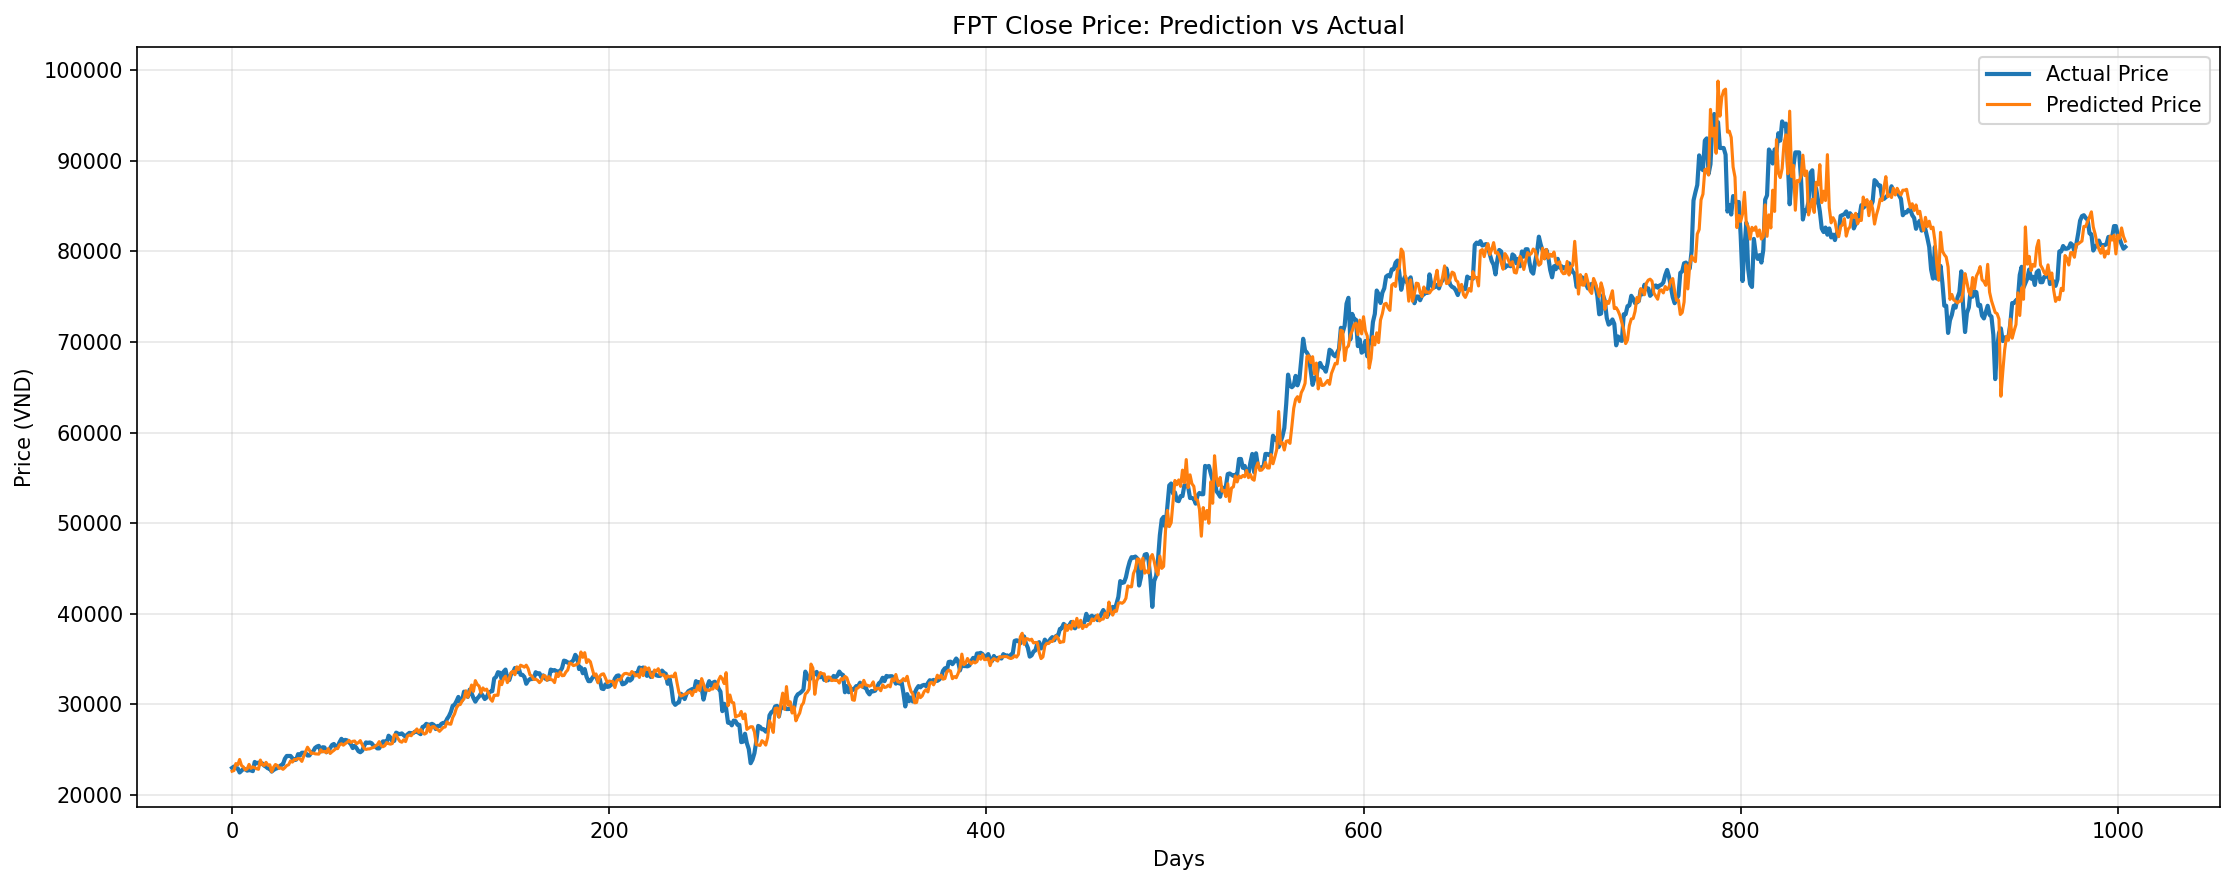

In [ ]:
# STEP 5C. VISUALIZATION

plt.figure(figsize=(15, 6), dpi=150)

# Plot actual Close prices
plt.plot(
    y_test_denorm.flatten(),
    label="Actual Price",
    linewidth=2
)

# Plot predicted Close prices
plt.plot(
    y_pred_denorm.flatten(),
    label="Predicted Price",
    linewidth=1.5
)

# Formatting
plt.title(f"{TEST_TICKER} Close Price: Prediction vs Actual")
plt.xlabel("Days")
plt.ylabel("Price (VND)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

It is expected that the further the predicted horizon is, the less accurate the prediction gives.

## Task 2.3 - Vietnam k days forecast


In [ ]:
# STEP 3A. CREATE WINDOWED SAMPLES AND NORMALIZATION

# Input:
#    - X window: past `window_size` days
#    - y label: prices at [t+1, t+2, ..., t+k] (vector of length k)

import numpy as np

def create_windowed_samples_with_target_norm_k_days(
    df,
    window_size,
    k,
    feature_indices,
    target_index,
    target_feature_idx
):

    # Extract raw feature matrix and target vector
    features = df.iloc[:, feature_indices].values.astype(float)
    targets  = df.iloc[:, target_index].values.astype(float)

    # Normalization
    X_windows_norm = []
    y_windows_norm = []

    # Store scaling info for de-normalization later
    target_mins  = []
    target_diffs = []

    # Iterate over valid window end positions
    # Last usable index is len(df) - k
    for i in range(window_size, len(df) - k):
        # Slice input window: [t - window_size, ..., t - 1]
        window = features[i - window_size:i]

        # Compute per-feature min and max inside this window
        feature_mins  = window.min(axis=0)
        feature_maxes = window.max(axis=0)

        # Compute feature-wise ranges
        diffs = feature_maxes - feature_mins
        diffs[diffs == 0] = 1e-8  # avoid division by zero

        # Normalize input window (per feature)
        window_norm = (window - feature_mins) / diffs

        # Normalize k future targets using the SAME window scale
        # y = [price_{t+1}, price_{t+2}, ..., price_{t+k}]
        y_future = targets[i : i + k]
        y_norm = (y_future - feature_mins[target_feature_idx]) / diffs[target_feature_idx]

        # Store normalized data
        X_windows_norm.append(window_norm)
        y_windows_norm.append(y_norm)

        # Store scaling info for later de-normalization
        target_mins.append(feature_mins[target_feature_idx])
        target_diffs.append(diffs[target_feature_idx])

    # Convert to numpy arrays
    X_windows_norm = np.array(X_windows_norm)
    y_windows_norm = np.array(y_windows_norm)  # shape: (N, k)

    target_mins  = np.array(target_mins).reshape(-1, 1)
    target_diffs = np.array(target_diffs).reshape(-1, 1)

    return X_windows_norm, y_windows_norm, target_mins, target_diffs

In [ ]:
# STEP 3B. APPLY TO EACH CV FOLD AND EACH STOCK

# Forecast horizon (consecutive)
K = 7

# Container to store windowed and normalized data per fold
# Structure:
#   fold_idx: {
#       "X_train": np.array,   # shape: (N_train, WINDOW_SIZE, num_features)
#       "y_train": np.array,   # shape: (N_train, K)
#       "X_val":   np.array,   # shape: (N_val, WINDOW_SIZE, num_features)
#       "y_val":   np.array    # shape: (N_val, K)
#   }
cv_windowed_data = {}

for fold_idx, fold_data in cv_raw_splits.items():
    # Lists to collect samples from all stocks
    X_train_all, y_train_all = [], []
    X_val_all,   y_val_all   = [], []

    for ticker in TICKERS:
        # Retrieve raw train and validation dataframes
        train_df = fold_data[ticker]["train_df"]
        val_df   = fold_data[ticker]["val_df"]

        # Create normalized training windows for this stock (k-day ahead)
        X_train_stock, y_train_stock, _, _ = (
            create_windowed_samples_with_target_norm_k_days(
                train_df,
                WINDOW_SIZE,
                K,
                FEATURE_INDICES,
                TARGET_INDEX,
                target_feature_idx=FEATURE_INDICES.index(TARGET_INDEX)
            )
        )

        # Create normalized validation windows for this stock (k-day ahead)
        X_val_stock, y_val_stock, _, _ = (
            create_windowed_samples_with_target_norm_k_days(
                val_df,
                WINDOW_SIZE,
                K,
                FEATURE_INDICES,
                TARGET_INDEX,
                target_feature_idx=FEATURE_INDICES.index(TARGET_INDEX)
            )
        )

        # Accumulate samples across stocks
        X_train_all.append(X_train_stock)
        y_train_all.append(y_train_stock)
        X_val_all.append(X_val_stock)
        y_val_all.append(y_val_stock)

    # Concatenate samples from all stocks along the sample axis
    cv_windowed_data[fold_idx] = {
        "X_train": np.concatenate(X_train_all, axis=0),
        "y_train": np.concatenate(y_train_all, axis=0),
        "X_val":   np.concatenate(X_val_all, axis=0),
        "y_val":   np.concatenate(y_val_all, axis=0),
    }

In [ ]:
# STEP 4A: BUILD THE DEEP LEARNING MODEL

import tensorflow as tf
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten,
    Dense, Dropout, Input, BatchNormalization
)
from tensorflow.keras.regularizers import l2

def build_model(window_size, num_features):
    model = tf.keras.Sequential()

    # Define input shape
    model.add(Input(shape=(window_size, num_features)))

    # Convolutional block 1
    model.add(Conv1D(32, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    # Convolutional block 2
    model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    # Convolutional block 3
    model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    # Flatten temporal features
    model.add(Flatten())

    # Fully connected layers
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.3))

    # Output layer for k-day ahead forecasr
    model.add(Dense(7))

    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [ ]:
# STEP 4B. TRAIN MODEL FOR EACH CV FOLD

# Store training histories and validation metrics
cv_results = {}

for fold_idx, data in cv_windowed_data.items():
    # Extract training and validation data for this fold
    X_train = data["X_train"]
    y_train = data["y_train"]
    X_val   = data["X_val"]
    y_val   = data["y_val"]

    # Build a fresh model for this CV fold
    model = build_model(
        window_size=WINDOW_SIZE,
        num_features=len(FEATURE_INDICES)
    )

    # Early stopping to prevent overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    # Train the model on the current fold
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        callbacks=[early_stop],
        verbose=1
    )

    # Evaluate model performance on validation data
    val_loss, val_mae = model.evaluate(X_val, y_val, verbose=0)

    # Store results for this fold
    cv_results[fold_idx] = {
        "history": history.history,
        "val_loss": val_loss,
        "val_mae": val_mae
    }

# Save the final trained model from the last fold for later use (e.g., Task 4.1)
if 'model' in locals():
    model.save("task2_3_vietnam_model.keras")
    print(f"Task 2.3 model saved to: task2_3_vietnam_model.keras")


Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - loss: 0.6414 - mae: 0.5384 - val_loss: 0.7486 - val_mae: 0.6899
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2800 - mae: 0.3467 - val_loss: 1.1801 - val_mae: 0.9080
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2352 - mae: 0.3085 - val_loss: 1.3435 - val_mae: 0.9328
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2130 - mae: 0.2889 - val_loss: 1.0721 - val_mae: 0.7950
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2016 - mae: 0.2740 - val_loss: 0.5614 - val_mae: 0.5561
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1999 - mae: 0.2735 - val_loss: 0.3099 - val_mae: 0.3868
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1886 - mae: 0.2633 - val_loss: 0.2387 - val_mae: 0.3252
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1802 - mae: 0.2593 - val_loss: 0.2220 - val_mae: 0.3143
Epoch 9/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1825 - mae

In [ ]:
# STEP 5A. CREATE NORMALIZED WINDOWS FOR FPT

TEST_TICKER = "FPT"

# Retrieve raw data for the selected stock
df = raw_stock_data[TEST_TICKER]

# Select final test period
test_df = df[df["TradingDate"] >= FINAL_TEST_DATE].reset_index(drop=True)

# Create normalized test windows + target scaling info
# y_test_norm has shape: (N_test, K)
X_test_norm, y_test_norm, test_target_mins, test_target_diffs = (
    create_windowed_samples_with_target_norm_k_days(
        test_df,
        WINDOW_SIZE,
        K,
        FEATURE_INDICES,
        TARGET_INDEX,
        target_feature_idx=FEATURE_INDICES.index(TARGET_INDEX)
    )
)

In [ ]:
# STEP 5B. INFERENCE AND DE-NORMALIZATION

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predict normalized targets on the final test set
y_pred_norm = model.predict(X_test_norm)

# De-normalize predictions back to real price scale
# Uses per-window scaling information stored during Step 3A
y_pred_denorm = y_pred_norm * test_target_diffs + test_target_mins

# De-normalize actual test set
y_test_denorm = y_test_norm * test_target_diffs + test_target_mins

# Compute evaluation metrics in real price space
mse_final = mean_squared_error(y_test_denorm, y_pred_denorm)
mae_final = mean_absolute_error(y_test_denorm, y_pred_denorm)

print(f"--- Final Test Results ({TEST_TICKER}) ---")
print(f"MSE: {mse_final:.4f}")
print(f"MAE: {mae_final:.2f} VND per share")

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
--- Final Test Results (FPT) ---
MSE: 5818981.2806
MAE: 1611.48 VND per share


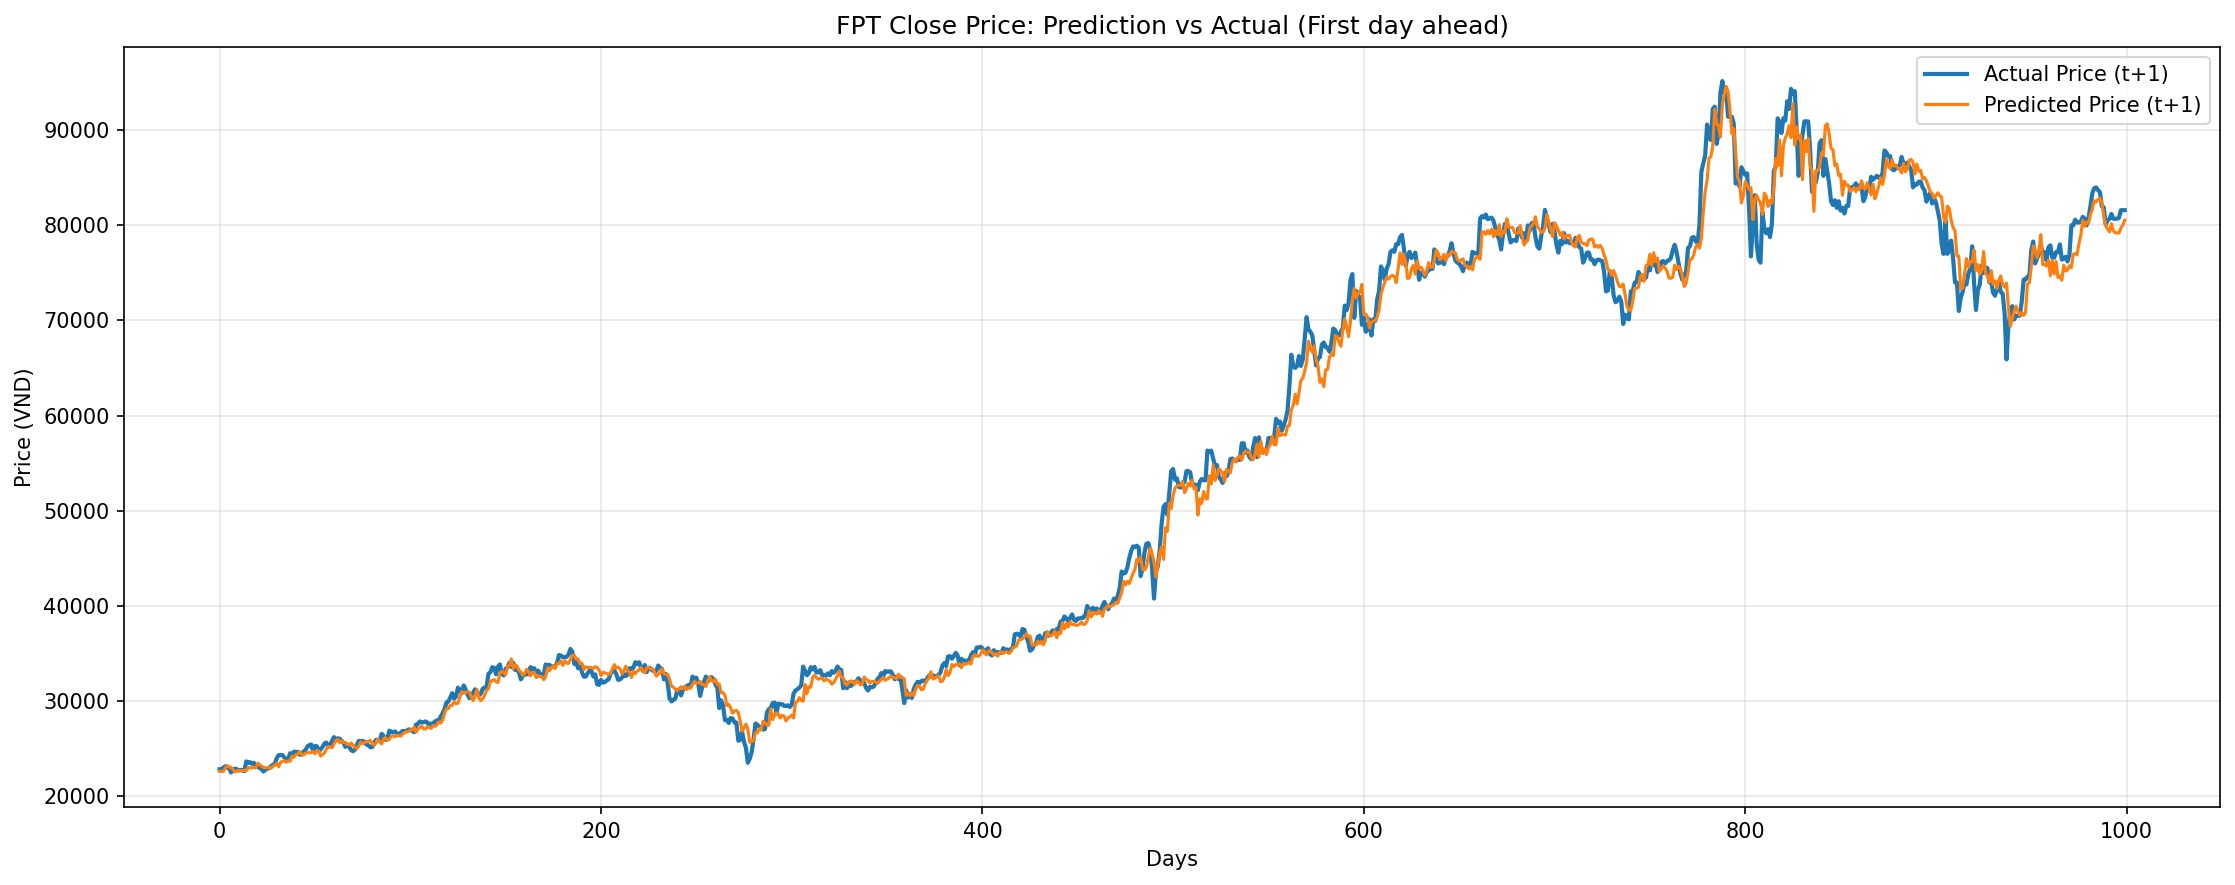

In [ ]:
# STEP 5C. VISUALIZATION

# Visualize the first day
plt.figure(figsize=(15, 6), dpi=150)

# Actual Close price
plt.plot(
    y_test_denorm[:, 0],
    label="Actual Price (t+1)",
    linewidth=2
)

# Plot predicted Close prices
plt.plot(
    y_pred_denorm[:, 0],
    label="Predicted Price (t+1)",
    linewidth=1.5
)

# Formatting
plt.title(f"{TEST_TICKER} Close Price: Prediction vs Actual (First day ahead)")
plt.xlabel("Days")
plt.ylabel("Price (VND)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

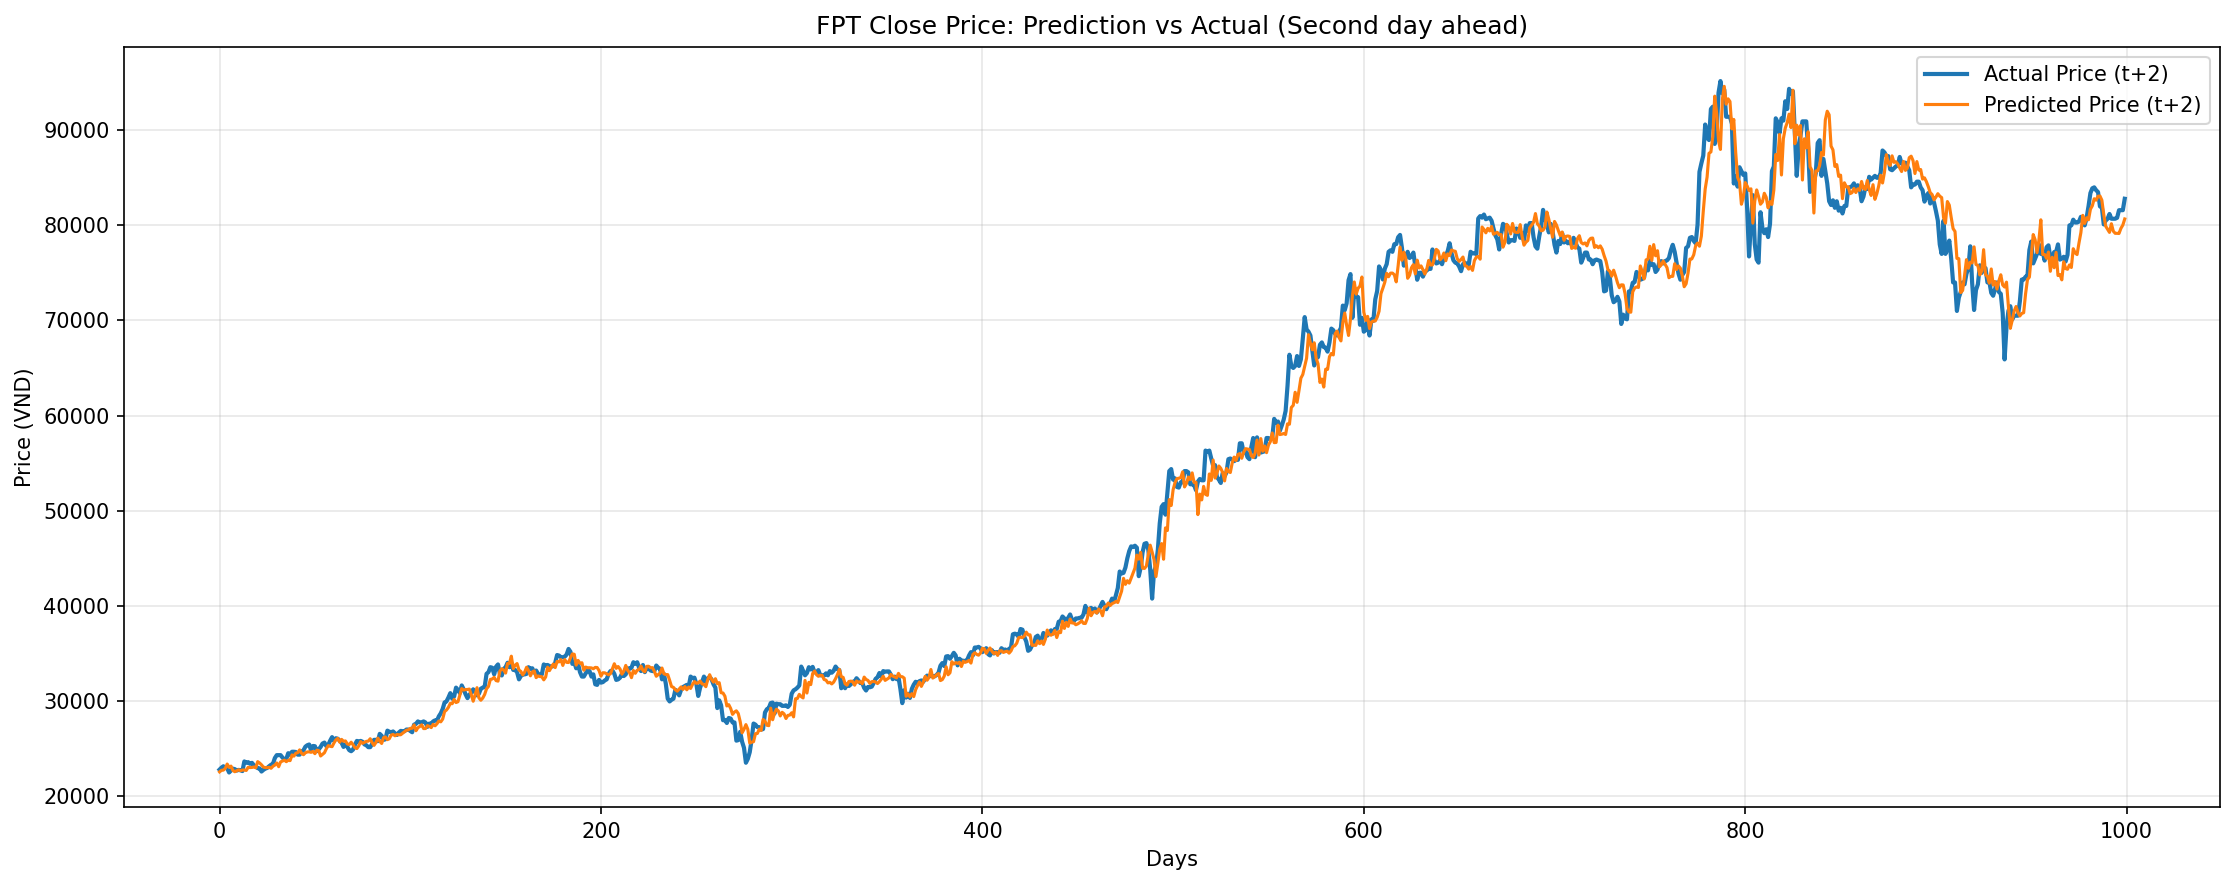

In [ ]:
# STEP 5C. VISUALIZATION

# Visualize the second day
plt.figure(figsize=(15, 6), dpi=150)

# Actual Close price
plt.plot(
    y_test_denorm[:, 1],
    label="Actual Price (t+2)",
    linewidth=2
)

# Plot predicted Close prices
plt.plot(
    y_pred_denorm[:, 1],
    label="Predicted Price (t+2)",
    linewidth=1.5
)

# Formatting
plt.title(f"{TEST_TICKER} Close Price: Prediction vs Actual (Second day ahead)")
plt.xlabel("Days")
plt.ylabel("Price (VND)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

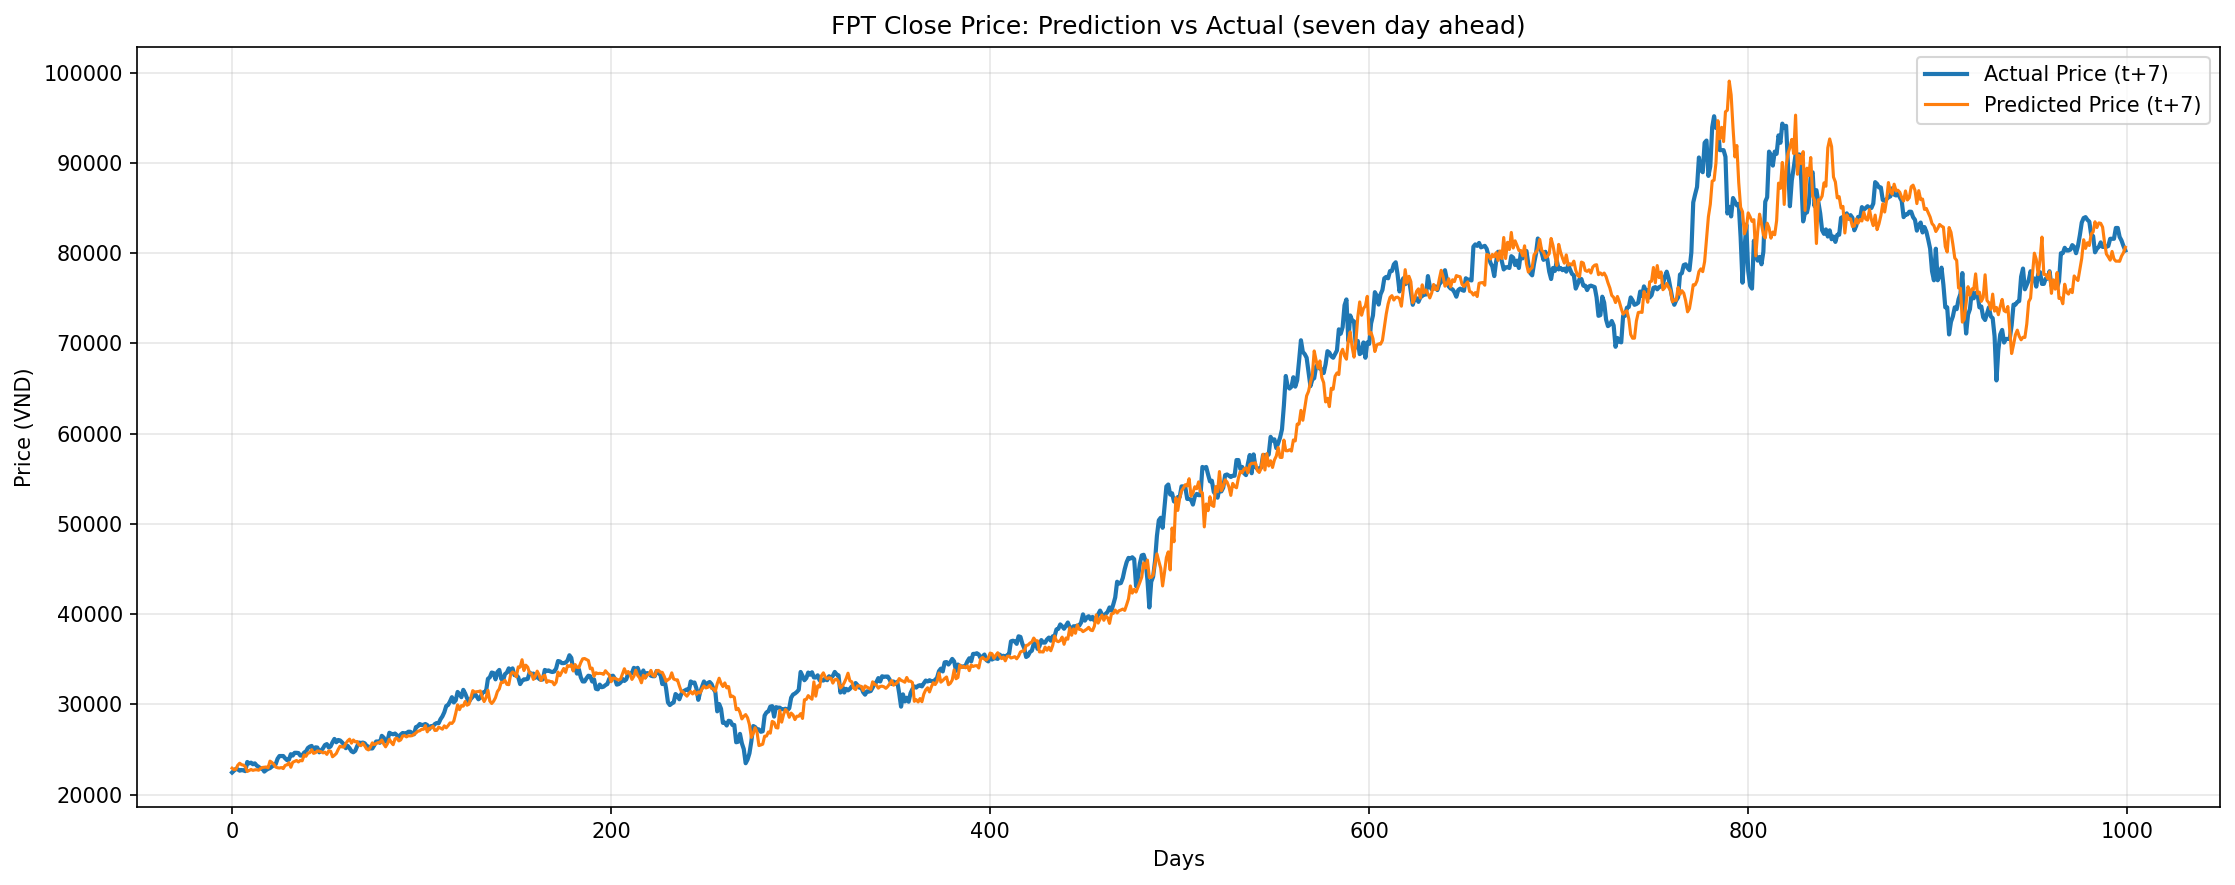

In [ ]:
# STEP 5C. VISUALIZATION

# Visualize the seventh day
plt.figure(figsize=(15, 6), dpi=150)

# Actual Close price
plt.plot(
    y_test_denorm[:, 6],
    label="Actual Price (t+7)",
    linewidth=2
)

# Plot predicted Close prices
plt.plot(
    y_pred_denorm[:, 2],
    label="Predicted Price (t+7)",
    linewidth=1.5
)

# Formatting
plt.title(f"{TEST_TICKER} Close Price: Prediction vs Actual (seven day ahead)")
plt.xlabel("Days")
plt.ylabel("Price (VND)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

This shows the popular behavior observed in stock price prediction mode. Perhaps seven day ahead is too far in the future to predict. Therefore the model gives less accurate prediction.

# Task 3 (20%) Trading signal identification for Vietnam market

## Task 3.1 - Buying signal identification


Define the Buy signal: 1 when the current Close is in the bottom `threshold`
fraction of the window's price range, and 0 otherwise.

Threshold can be customized based on investors' preference. One may choose higher threshold to buy more to not miss any chance, while other may choose lower threshold to buy less but in certainty.

In [ ]:
# Configuration
TEST_TICKER      = "HPG"
DATE_COL         = "TradingDate"
NUM_BUY_FEATURES = 5 + 3        # OHLCV (5) + indicators (3)
SAVE_DIR         = "task3_1_buy_model"
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
# STEP 3A: BUY SIGNAL LABELING RULE
# BUY = 1 when the current Close is in the bottom `threshold`
# fraction of the window's price range.

def label_buy_signal(close_window, threshold=0.1): # only the bottom 5%
    current_price = close_window[-1]
    min_price     = close_window.min()
    max_price     = close_window.max()

    relative_pos  = (current_price - min_price) / (max_price - min_price + 1e-8)
    return int(relative_pos <= threshold)

Besides available features in the dataset, we inteprete some other meaningful features which are broadly used in stock prediction.

In [ ]:
# STEP 3B: FEATURE ENGINEERING
# Three more technical indicators are computed inside each window
#   log_return : momentum direction
#   SMA-5      : short-term trend baseline
#   RSI-14     : overbought / oversold condition

def compute_log_return(prices):
    # difference of the natural logarithm of prices
    log_ret = np.diff(np.log(prices + 1e-8))
    # Pad the beginning of the array to match original price array length.
    return np.pad(log_ret, (len(prices) - len(log_ret), 0), mode="edge")

def compute_sma(prices, window=5):
    # If there are fewer prices than the window size, return the mean of available prices
    if len(prices) < window:
        return np.full(len(prices), prices.mean())
    # Compute the simple moving average using convolution.
    sma = np.convolve(prices, np.ones(window) / window, mode="valid")
    # Pad the beginning of the array to match original price array length
    return np.pad(sma, (len(prices) - len(sma), 0), mode="edge")

def compute_rsi(prices, window=14):
    # Calculate price changes
    deltas = np.diff(prices)
    # Separate gains and losses
    gains  = np.maximum(deltas, 0)
    losses = np.abs(np.minimum(deltas, 0))

    # If there are fewer deltas than the window size, return a neutral RSI of 50
    if len(deltas) < window:
        return np.full(len(prices), 50.0)

    # Compute average gains and losses over the window
    avg_gain = np.convolve(gains,  np.ones(window) / window, mode="valid")
    avg_loss = np.convolve(losses, np.ones(window) / window, mode="valid")
    # Calculate Relative Strength RI
    rs       = avg_gain / (avg_loss + 1e-8)
    # Calculate Relative Strength Index (RSI)
    rsi      = 100 - (100 / (1 + rs))
    # Pad the beginning of the array to match original price array length
    return np.pad(rsi, (len(prices) - len(rsi), 0), mode="edge")

These data preprocessing steps are similar to those in task 1 and 2.

In [ ]:
# STEP 3C: PER WINDOW DATASET SETUP

def create_buy_signal_dataset(df, window_size,
                               feature_indices, target_index,
                               buy_threshold=0.1):

    features     = df.iloc[:, feature_indices].values.astype(float)
    close_prices = df.iloc[:, target_index].values.astype(float)

    X, y_buy = [], []

    for i in range(window_size, len(df)):
        price_window = features[i - window_size:i]
        close_window = close_prices[i - window_size:i]

        # Per-window min-max normaliZation
        f_min  = price_window.min(axis=0)
        f_max  = price_window.max(axis=0)
        f_diff = np.where(f_max - f_min == 0, 1e-8, f_max - f_min)
        price_window_norm = (price_window - f_min) / f_diff

        # Additional indicators
        log_ret    = compute_log_return(close_window)
        sma5       = compute_sma(close_window, window=5)
        rsi14      = compute_rsi(close_window, window=14)
        engineered = np.stack([log_ret, sma5, rsi14], axis=1)

        combined  = np.concatenate([price_window_norm, engineered], axis=1)
        buy_label = label_buy_signal(close_window, threshold=buy_threshold)

        X.append(combined)
        y_buy.append(buy_label)

    return np.array(X), np.array(y_buy).reshape(-1, 1)

In [ ]:
# STEP 3D: BUILD DATASETS FOR ALL CV FOLDS & ALL STOCKS

cv_buy_datasets = {}

for fold_idx, fold_data in cv_raw_splits.items():
    X_train_all, y_train_all = [], []
    X_val_all,   y_val_all   = [], []

    for ticker in TICKERS:
        train_df = fold_data[ticker]["train_df"]
        val_df   = fold_data[ticker]["val_df"]

        X_tr, y_tr = create_buy_signal_dataset(
            train_df, WINDOW_SIZE, FEATURE_INDICES, TARGET_INDEX
        )
        X_vl, y_vl = create_buy_signal_dataset(
            val_df, WINDOW_SIZE, FEATURE_INDICES, TARGET_INDEX
        )

        X_train_all.append(X_tr);  y_train_all.append(y_tr)
        X_val_all.append(X_vl);    y_val_all.append(y_vl)

    cv_buy_datasets[fold_idx] = {
        "X_train": np.concatenate(X_train_all, axis=0),
        "y_train": np.concatenate(y_train_all, axis=0),
        "X_val":   np.concatenate(X_val_all,   axis=0),
        "y_val":   np.concatenate(y_val_all,   axis=0),
    }

# label distribution
print("=== Buy label distribution per fold ===")
for fold_idx, data in cv_buy_datasets.items():
    ratio = data["y_train"].mean()
    n_buy = int(data["y_train"].sum())
    total = len(data["y_train"])
    print(f"  Fold {fold_idx} | Total: {total:,} | BUY: {n_buy:,} ({ratio:.1%})")

=== Buy label distribution per fold ===
  Fold 0 | Total: 2,616 | BUY: 409 (15.6%)
  Fold 1 | Total: 5,628 | BUY: 878 (15.6%)


In [ ]:
# BUILD MODEL ARCHITECTURE

from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten,
    Dense, Dropout, Input, BatchNormalization
)
from tensorflow.keras.metrics import AUC, Precision, Recall

def build_buy_signal_model(window_size, num_features):

    model = tf.keras.Sequential([
        Input(shape=(window_size, num_features)),

        # Conv Block 1
        Conv1D(32, kernel_size=3, activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # Conv Block 2
        Conv1D(64, kernel_size=3, activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # Conv Block 3
        Conv1D(128, kernel_size=3, activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Flatten(),
        Dense(32, activation="relu"),
        Dropout(0.3),

        # Sigmoid output
        Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            AUC(name="auc"),
            Precision(name="precision"),
            Recall(name="recall"),
        ]
    )
    return model

We consider to balance precision (correct buy opportunities) and recall (coverage of buy opportunities) so we implement a method to find optimal threshold while training the model.

In [ ]:
# STEP 4B: TRAIN THE MODEL AND FIND OPTIMAL THRESHOLD ON VALIDATION SET

# The decision threshold is selected on each validation fold

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score,
    recall_score, precision_recall_curve
)

buy_cv_results  = {}
best_thresholds = []   # one per fold, averaged for deployment

for fold_idx, data in cv_buy_datasets.items():
    X_train = data["X_train"]
    y_train = data["y_train"]
    X_val   = data["X_val"]
    y_val   = data["y_val"]

    # Class weights
    y_flat = y_train.flatten()
    cw     = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1]),
        y=y_flat
    )
    class_weight_dict = {0: cw[0], 1: cw[1]}
    print(f"\nFold {fold_idx} | class weights → "
          f"NO-BUY: {cw[0]:.2f}  BUY: {cw[1]:.2f}")

    # Build and train
    model = build_buy_signal_model(WINDOW_SIZE, NUM_BUY_FEATURES)

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=5,
        restore_best_weights=True,
        mode="max"                  # maximize AUC
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        class_weight=class_weight_dict,
        callbacks=[early_stop],
        verbose=1
    )

    # Optimal threshold on val set
    # Maximize F1 on val data
    val_probs                      = model.predict(X_val).flatten()
    prec_v, rec_v, thresh_v        = precision_recall_curve(
        y_val.flatten(), val_probs
    )
    f1_v        = (2 * prec_v * rec_v) / (prec_v + rec_v + 1e-8)
    best_idx_v  = np.argmax(f1_v[:-1])          # drop last point (recall=0)
    fold_thresh = float(thresh_v[best_idx_v])
    best_thresholds.append(fold_thresh)

    # Evaluate at fold threshold
    val_preds    = (val_probs >= fold_thresh).astype(int)
    results      = model.evaluate(X_val, y_val, verbose=0)
    metric_names = ["loss", "accuracy", "auc", "precision", "recall"]
    fold_metrics = dict(zip(metric_names, results))
    fold_metrics["f1"] = f1_score(y_val.flatten(), val_preds, zero_division=0)

    buy_cv_results[fold_idx] = {
        "history":   history.history,
        "threshold": fold_thresh,
        **fold_metrics
    }

    print(f"  Fold {fold_idx} Val → "
          f"Threshold: {fold_thresh:.4f} | "
          f"AUC: {fold_metrics['auc']:.4f} | "
          f"Precision: {fold_metrics['precision']:.4f} | "
          f"Recall: {fold_metrics['recall']:.4f} | "
          f"F1: {fold_metrics['f1']:.4f}")

# Deployment threshold = mean across folds
DEPLOY_THRESHOLD = float(np.mean(best_thresholds))
DEPLOY_THRESHOLD = max(DEPLOY_THRESHOLD, 0.80)
print(f"\n=== Per-fold thresholds : {[f'{t:.4f}' for t in best_thresholds]}")
print(f"=== Deployment threshold (mean) : {DEPLOY_THRESHOLD:.4f}")

# CV summary table
print("\n=== Cross-Validation Summary (BUY Signal) ===")
for metric in ["auc", "precision", "recall", "f1"]:
    scores = [buy_cv_results[f][metric] for f in buy_cv_results]
    print(f"  {metric.upper():10s}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")


Fold 0 | class weights → NO-BUY: 0.59  BUY: 3.20
Epoch 1/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step - accuracy: 0.5573 - auc: 0.5377 - loss: 0.7835 - precision: 0.1763 - recall: 0.4988 - val_accuracy: 0.6614 - val_auc: 0.5121 - val_loss: 0.6664 - val_precision: 0.1126 - val_recall: 0.2161
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6151 - auc: 0.6352 - loss: 0.6867 - precision: 0.2185 - recall: 0.5672 - val_accuracy: 0.6527 - val_auc: 0.6326 - val_loss: 0.6174 - val_precision: 0.2046 - val_recall: 0.5374
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6143 - auc: 0.6822 - loss: 0.6403 - precision: 0.2368 - recall: 0.6601 - val_accuracy: 0.8382 - val_auc: 0.6908 - val_loss: 0.5036 - val_precision: 0.2424 - val_recall: 0.0886
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6843 - auc: 0.7625 - loss: 0.5770 - precision: 0.2929 - recall: 0.7213 - val_accuracy: 0.6716 - val_auc: 0.7551 - val_loss: 0.5891 - val_precision: 0.2603 - val_rec

In [ ]:
# STEP 5A: INFERENCE ON TEST SET

df      = raw_stock_data[TEST_TICKER]
test_df = df[
    df[DATE_COL] >= pd.to_datetime(FINAL_TEST_DATE, utc=True)
].reset_index(drop=True)

X_test_buy, y_test_buy = create_buy_signal_dataset(
    test_df, WINDOW_SIZE, FEATURE_INDICES, TARGET_INDEX
)

buy_prob   = model.predict(X_test_buy).flatten()
buy_signal = (buy_prob >= DEPLOY_THRESHOLD).astype(int)

# Align prices and dates
close_prices = test_df.iloc[WINDOW_SIZE:, TARGET_INDEX].values
dates        = test_df.iloc[WINDOW_SIZE:][DATE_COL].values
y_true       = y_test_buy.flatten()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [ ]:
# STEP 5B: TEST-SET EVALUATION

auc_score = roc_auc_score(y_true, buy_prob)
f1        = f1_score(y_true, buy_signal, zero_division=0)
prec      = precision_score(y_true, buy_signal, zero_division=0)
rec       = recall_score(y_true, buy_signal, zero_division=0)
cm        = confusion_matrix(y_true, buy_signal)

print(f"\n=== Test Set Evaluation — {TEST_TICKER} "
      f"(threshold = {DEPLOY_THRESHOLD:.4f}) ===")
print(classification_report(
    y_true, buy_signal,
    target_names=["NO BUY", "BUY"],
    digits=4
))
print(f"  ROC-AUC  : {auc_score:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall   : {rec:.4f}")


=== Test Set Evaluation — HPG (threshold = 0.8000) ===
              precision    recall  f1-score   support

      NO BUY     0.9329    0.9618    0.9471       838
         BUY     0.7762    0.6568    0.7115       169

    accuracy                         0.9106      1007
   macro avg     0.8545    0.8093    0.8293      1007
weighted avg     0.9066    0.9106    0.9076      1007

  ROC-AUC  : 0.9666
  F1 Score : 0.7115
  Precision: 0.7762
  Recall   : 0.6568


The precision, recall and F1 score shows that our model predict well on the test set. Precision now is higher than recall, implying that our model is prioritizing correct buy opportunities over coverage of opportunities.

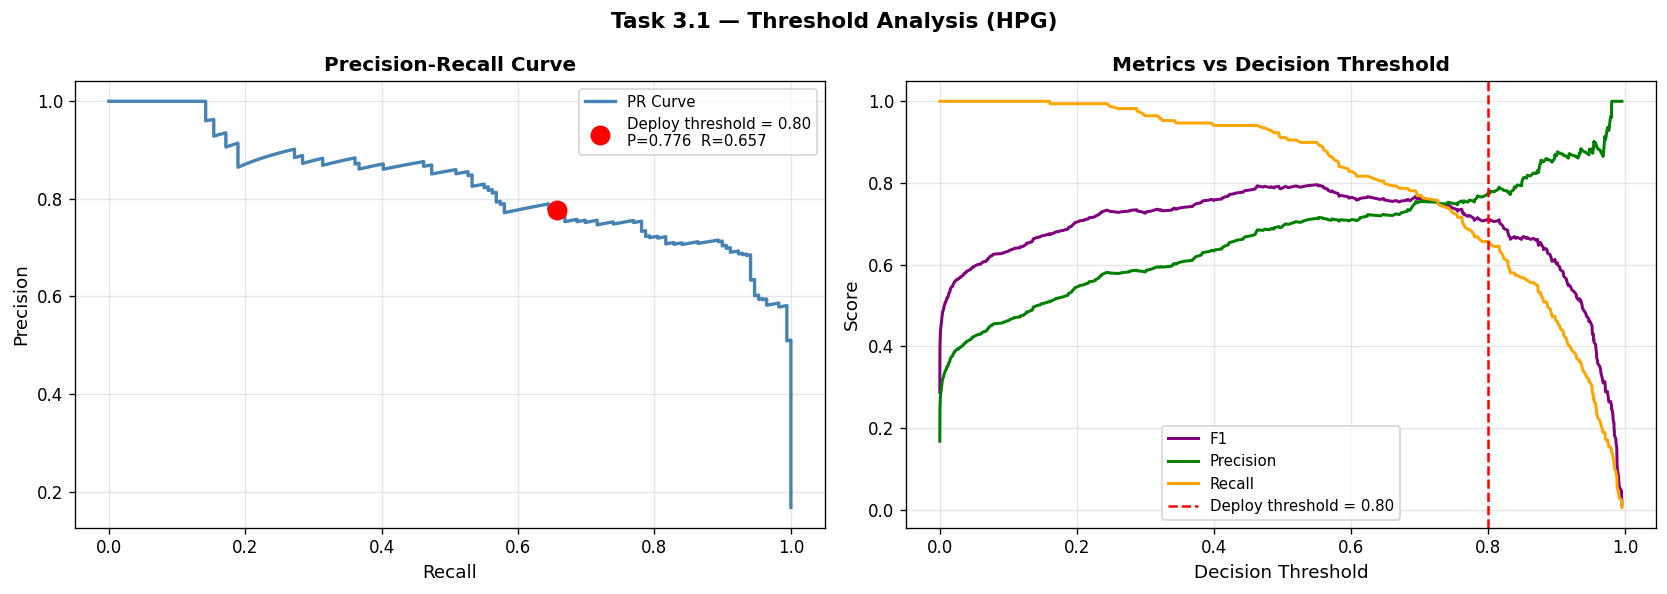

Saved → task3_1_threshold_analysis.png


In [ ]:
# STEP 5C: THRESHOLD ANALYSIS PLOT

prec_t, rec_t, thresh_t = precision_recall_curve(y_true, buy_prob)
f1_t = (2 * prec_t * rec_t) / (prec_t + rec_t + 1e-8)

# Locate deploy threshold on the test PR curve
deploy_idx = min(np.searchsorted(thresh_t, DEPLOY_THRESHOLD), len(prec_t) - 2)

fig_thresh, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# Left: Precision-Recall Curve
axes[0].plot(rec_t, prec_t, color="steelblue", linewidth=2, label="PR Curve")
axes[0].scatter(
    rec_t[deploy_idx], prec_t[deploy_idx],
    color="red", s=120, zorder=5,
    label=(f"Deploy threshold = {DEPLOY_THRESHOLD:.2f}\n"
           f"P={prec_t[deploy_idx]:.3f}  R={rec_t[deploy_idx]:.3f}")
)
axes[0].set_xlabel("Recall", fontsize=11)
axes[0].set_ylabel("Precision", fontsize=11)
axes[0].set_title("Precision-Recall Curve", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Right: Metrics vs Threshold
axes[1].plot(thresh_t, f1_t[:-1],   label="F1",        color="purple",  linewidth=1.8)
axes[1].plot(thresh_t, prec_t[:-1], label="Precision",  color="green",   linewidth=1.8)
axes[1].plot(thresh_t, rec_t[:-1],  label="Recall",     color="orange",  linewidth=1.8)
axes[1].axvline(DEPLOY_THRESHOLD, color="red", linestyle="--", linewidth=1.5,
                label=f"Deploy threshold = {DEPLOY_THRESHOLD:.2f}")
axes[1].set_xlabel("Decision Threshold", fontsize=11)
axes[1].set_ylabel("Score", fontsize=11)
axes[1].set_title("Metrics vs Decision Threshold", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle(f"Task 3.1 — Threshold Analysis ({TEST_TICKER})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "task3_1_threshold_analysis.png"),
            bbox_inches="tight")
plt.show()
print("Saved → task3_1_threshold_analysis.png")

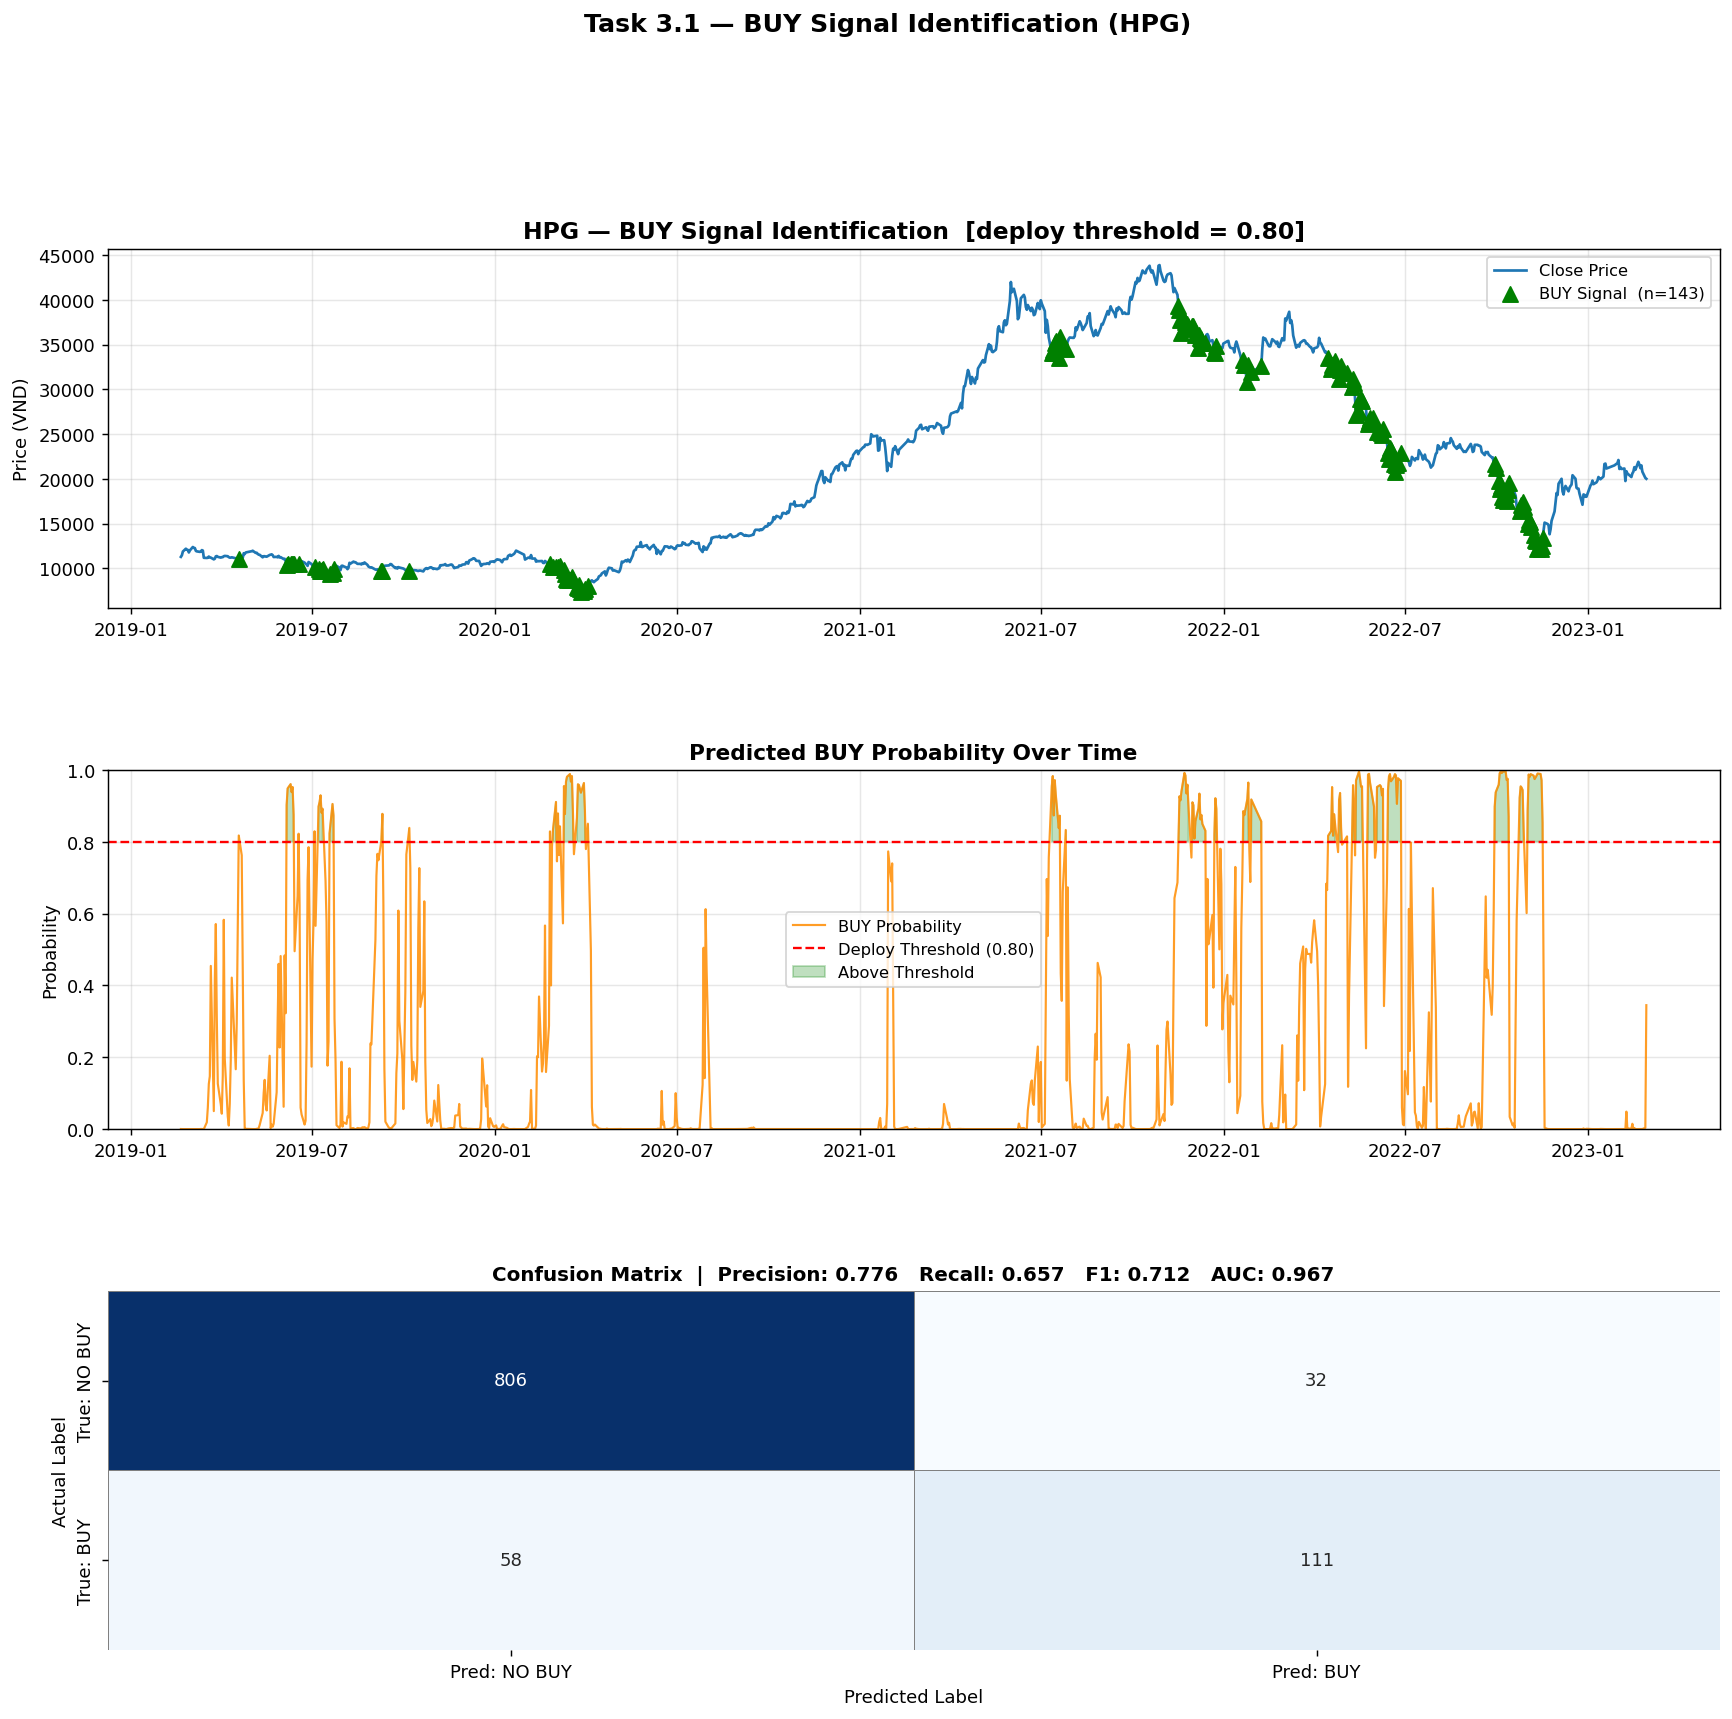

Saved → task3_1_buy_signal.png


In [ ]:
# STEP 5D: MAIN VISUALISATION

buy_idx = np.where(buy_signal == 1)[0]

fig = plt.figure(figsize=(16, 14), dpi=130)
gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45)

# Panel 1: Price + BUY signals
ax1 = fig.add_subplot(gs[0])
ax1.plot(dates, close_prices, color="#1f77b4", linewidth=1.5,
         label="Close Price", zorder=2)
ax1.scatter(dates[buy_idx], close_prices[buy_idx],
            color="green", marker="^", s=70, zorder=3,
            label=f"BUY Signal  (n={len(buy_idx)})")
ax1.set_title(
    f"{TEST_TICKER} — BUY Signal Identification  "
    f"[deploy threshold = {DEPLOY_THRESHOLD:.2f}]",
    fontsize=13, fontweight="bold"
)
ax1.set_ylabel("Price (VND)")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Panel 2: BUY probability timeline
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.plot(dates, buy_prob, color="darkorange", linewidth=1.2,
         label="BUY Probability", alpha=0.85)
ax2.axhline(DEPLOY_THRESHOLD, color="red", linestyle="--", linewidth=1.3,
            label=f"Deploy Threshold ({DEPLOY_THRESHOLD:.2f})")
ax2.fill_between(
    dates, buy_prob, DEPLOY_THRESHOLD,
    where=(buy_prob >= DEPLOY_THRESHOLD),
    alpha=0.25, color="green", label="Above Threshold"
)
ax2.set_ylabel("Probability")
ax2.set_ylim(0, 1)
ax2.set_title("Predicted BUY Probability Over Time",
              fontsize=12, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# Panel 3: Confusion matrix
ax3 = fig.add_subplot(gs[2])
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred: NO BUY", "Pred: BUY"],
    yticklabels=["True: NO BUY", "True: BUY"],
    ax=ax3, cbar=False, linewidths=0.5, linecolor="gray"
)
ax3.set_title(
    f"Confusion Matrix  |  "
    f"Precision: {prec:.3f}   Recall: {rec:.3f}   "
    f"F1: {f1:.3f}   AUC: {auc_score:.3f}",
    fontsize=11, fontweight="bold"
)
ax3.set_ylabel("Actual Label")
ax3.set_xlabel("Predicted Label")

plt.suptitle(f"Task 3.1 — BUY Signal Identification ({TEST_TICKER})",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(os.path.join(SAVE_DIR, "task3_1_buy_signal.png"),
            bbox_inches="tight")
plt.show()
print("Saved → task3_1_buy_signal.png")


## Task 3.2 - Selling signal identification


This task has similar approach to task 3.1. We can consider it to be a mirror of task 3.1.

In [ ]:
# Configuration

TEST_TICKER       = "HPG"
DATE_COL          = "TradingDate"
NUM_SELL_FEATURES = 5 + 3        # OHLCV (5) + indicators (3)
SAVE_DIR          = "task3_2_sell_model"
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
# STEP 3A: SELL SIGNAL LABELING RULE

# SELL = 1 when the current Close sits in the top `threshold`
# fraction of the window's price range.

def label_sell_signal(close_window, threshold=0.1):

    current_price = close_window[-1]
    min_price     = close_window.min()
    max_price     = close_window.max()
    relative_pos  = (current_price - min_price) / (max_price - min_price + 1e-8)
    return int(relative_pos >= 1.0 - threshold)

In [ ]:
# STEP 3C: WINDOWED DATASET BUILDER FOR SELL SIGNAL

def create_sell_signal_dataset(df, window_size,
                                feature_indices, target_index,
                                sell_threshold=0.1):
    """
    Parameters
    ----------
    df               : pd.DataFrame
    window_size      : int
    feature_indices  : list[int]  — OHLCV column positions
    target_index     : int        — Close column position
    sell_threshold   : float      — top-fraction cutoff for SELL label

    Returns
    -------
    X      : np.array (n_samples, window_size, 8)
    y_sell : np.array (n_samples, 1)
    """
    features     = df.iloc[:, feature_indices].values.astype(float)
    close_prices = df.iloc[:, target_index].values.astype(float)

    X, y_sell = [], []

    for i in range(window_size, len(df)):
        price_window = features[i - window_size:i]
        close_window = close_prices[i - window_size:i]

        # Per-window min-max normalisation (consistent with Tasks 1 & 3.1)
        f_min  = price_window.min(axis=0)
        f_max  = price_window.max(axis=0)
        f_diff = np.where(f_max - f_min == 0, 1e-8, f_max - f_min)
        price_window_norm = (price_window - f_min) / f_diff

        # Technical indicators — same three as Task 3.1
        log_ret    = compute_log_return(close_window)
        sma5       = compute_sma(close_window, window=5)
        rsi14      = compute_rsi(close_window, window=14)
        engineered = np.stack([log_ret, sma5, rsi14], axis=1)

        combined   = np.concatenate([price_window_norm, engineered], axis=1)

        # SELL label: top of the window (opposite of BUY)
        sell_label = label_sell_signal(close_window, threshold=sell_threshold)

        X.append(combined)
        y_sell.append(sell_label)

    return np.array(X), np.array(y_sell).reshape(-1, 1)

In [ ]:
# STEP 3D: BUILD DATASETS FOR ALL CV FOLDS & ALL STOCKS

cv_sell_datasets = {}

for fold_idx, fold_data in cv_raw_splits.items():
    X_train_all, y_train_all = [], []
    X_val_all,   y_val_all   = [], []

    for ticker in TICKERS:
        train_df = fold_data[ticker]["train_df"]
        val_df   = fold_data[ticker]["val_df"]

        X_tr, y_tr = create_sell_signal_dataset(
            train_df, WINDOW_SIZE, FEATURE_INDICES, TARGET_INDEX
        )
        X_vl, y_vl = create_sell_signal_dataset(
            val_df, WINDOW_SIZE, FEATURE_INDICES, TARGET_INDEX
        )

        X_train_all.append(X_tr);  y_train_all.append(y_tr)
        X_val_all.append(X_vl);    y_val_all.append(y_vl)

    cv_sell_datasets[fold_idx] = {
        "X_train": np.concatenate(X_train_all, axis=0),
        "y_train": np.concatenate(y_train_all, axis=0),
        "X_val":   np.concatenate(X_val_all,   axis=0),
        "y_val":   np.concatenate(y_val_all,   axis=0),
    }

# Label distribution
print("=== Sell Label Distribution per Fold ===")
for fold_idx, data in cv_sell_datasets.items():
    ratio  = data["y_train"].mean()
    n_sell = int(data["y_train"].sum())
    total  = len(data["y_train"])
    print(f"  Fold {fold_idx} | Total: {total:,} | SELL: {n_sell:,} ({ratio:.1%})")

=== Sell Label Distribution per Fold ===
  Fold 0 | Total: 2,616 | SELL: 447 (17.1%)
  Fold 1 | Total: 5,628 | SELL: 1,086 (19.3%)


In [ ]:
# STEP 4A: MODEL ARCHITECTURE (SAME AS 3.1)

def build_sell_signal_model(window_size, num_features):
    """
    Input  : (window_size, num_features)
    Output : scalar SELL probability in [0, 1]
    """
    model = tf.keras.Sequential([
        Input(shape=(window_size, num_features)),

        # Block 1
        Conv1D(32, kernel_size=3, activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # Block 2
        Conv1D(64, kernel_size=3, activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # Block 3
        Conv1D(128, kernel_size=3, activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Flatten(),
        Dense(32, activation="relu"),
        Dropout(0.3),

        # Sigmoid output — SELL probability
        Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            AUC(name="auc"),
            Precision(name="precision"),
            Recall(name="recall"),
        ]
    )
    return model

In [ ]:
# STEP 4B: TRAIN AND FIND OPTIMAL THRESHOLD
# Same approach as 3.1

sell_cv_results  = {}
best_thresholds  = []   # one per fold; averaged for deployment

for fold_idx, data in cv_sell_datasets.items():
    X_train = data["X_train"]
    y_train = data["y_train"]
    X_val   = data["X_val"]
    y_val   = data["y_val"]

    # Class weights
    y_flat = y_train.flatten()
    cw     = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1]),
        y=y_flat
    )
    class_weight_dict = {0: cw[0], 1: cw[1]}
    print(f"\nFold {fold_idx} | class weights → "
          f"NO-SELL: {cw[0]:.2f}  SELL: {cw[1]:.2f}")

    # Build and train
    model = build_sell_signal_model(WINDOW_SIZE, NUM_SELL_FEATURES)

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=5,
        restore_best_weights=True,
        mode="max"
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        class_weight=class_weight_dict,
        callbacks=[early_stop],
        verbose=1
    )

    # Optimal threshold on VALIDATION set
    val_probs              = model.predict(X_val).flatten()
    prec_v, rec_v, thresh_v = precision_recall_curve(
        y_val.flatten(), val_probs
    )
    f1_v        = (2 * prec_v * rec_v) / (prec_v + rec_v + 1e-8)
    best_idx_v  = np.argmax(f1_v[:-1])          # drop last point (recall=0)
    fold_thresh = float(thresh_v[best_idx_v])
    best_thresholds.append(fold_thresh)

    # Evaluate at fold threshold
    val_preds    = (val_probs >= fold_thresh).astype(int)
    results      = model.evaluate(X_val, y_val, verbose=0)
    metric_names = ["loss", "accuracy", "auc", "precision", "recall"]
    fold_metrics = dict(zip(metric_names, results))
    fold_metrics["f1"] = f1_score(y_val.flatten(), val_preds, zero_division=0)

    sell_cv_results[fold_idx] = {
        "history":   history.history,
        "threshold": fold_thresh,
        **fold_metrics
    }

    print(f"  Fold {fold_idx} Val → "
          f"Threshold: {fold_thresh:.4f} | "
          f"AUC: {fold_metrics['auc']:.4f} | "
          f"Precision: {fold_metrics['precision']:.4f} | "
          f"Recall: {fold_metrics['recall']:.4f} | "
          f"F1: {fold_metrics['f1']:.4f}")

# Deployment threshold = mean across folds
DEPLOY_THRESHOLD = float(np.mean(best_thresholds))
print(f"\n=== Per-fold thresholds : {[f'{t:.4f}' for t in best_thresholds]}")
print(f"=== Deployment threshold (mean) : {DEPLOY_THRESHOLD:.4f}")

# CV summary table
print("\n=== Cross-Validation Summary for Sell Signal ===")
for metric in ["auc", "precision", "recall", "f1"]:
    scores = [sell_cv_results[f][metric] for f in sell_cv_results]
    print(f"  {metric.upper():10s}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")


Fold 0 | class weights → NO-SELL: 0.60  SELL: 2.93
Epoch 1/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - accuracy: 0.5826 - auc: 0.5884 - loss: 0.7359 - precision: 0.2198 - recall: 0.5660 - val_accuracy: 0.4382 - val_auc: 0.6229 - val_loss: 0.7292 - val_precision: 0.2575 - val_recall: 0.7811
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6296 - auc: 0.6780 - loss: 0.6430 - precision: 0.2592 - recall: 0.6286 - val_accuracy: 0.7609 - val_auc: 0.7128 - val_loss: 0.6433 - val_precision: 0.4722 - val_recall: 0.4362
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7122 - auc: 0.7651 - loss: 0.5910 - precision: 0.3376 - recall: 0.7114 - val_accuracy: 0.3793 - val_auc: 0.5528 - val_loss: 0.7690 - val_precision: 0.2195 - val_recall: 0.6766
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7680 - auc: 0.8498 - loss: 0.4855 - precision: 0.4057 - recall: 0.7696 - val_accuracy: 0.3914 - val_auc: 0.6382 - val_loss: 0.9060 - val_precision: 0.2396 - val_r

In [ ]:
# STEP 5A: INFERENCE ON TEST SET (same as  3.1)

df      = raw_stock_data[TEST_TICKER]
test_df = df[
    df[DATE_COL] >= pd.to_datetime(FINAL_TEST_DATE, utc=True)
].reset_index(drop=True)

X_test_sell, y_test_sell = create_sell_signal_dataset(
    test_df, WINDOW_SIZE, FEATURE_INDICES, TARGET_INDEX
)

sell_prob   = model.predict(X_test_sell).flatten()
sell_signal = (sell_prob >= DEPLOY_THRESHOLD).astype(int)

# Align prices and dates
close_prices = test_df.iloc[WINDOW_SIZE:, TARGET_INDEX].values
dates        = test_df.iloc[WINDOW_SIZE:][DATE_COL].values
y_true       = y_test_sell.flatten()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [ ]:
# STEP 5B: TEST SET EVALUATION

auc_score = roc_auc_score(y_true, sell_prob)
f1        = f1_score(y_true, sell_signal, zero_division=0)
prec      = precision_score(y_true, sell_signal, zero_division=0)
rec       = recall_score(y_true, sell_signal, zero_division=0)
cm        = confusion_matrix(y_true, sell_signal)

print(f"\n=== Test Set Evaluation — {TEST_TICKER} "
      f"(threshold = {DEPLOY_THRESHOLD:.4f}) ===")
print(classification_report(
    y_true, sell_signal,
    target_names=["NO SELL", "SELL"],
    digits=4
))
print(f"  ROC-AUC  : {auc_score:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall   : {rec:.4f}")


=== Test Set Evaluation — HPG (threshold = 0.5680) ===
              precision    recall  f1-score   support

     NO SELL     0.9772    0.8735    0.9224       735
        SELL     0.7343    0.9449    0.8264       272

    accuracy                         0.8928      1007
   macro avg     0.8557    0.9092    0.8744      1007
weighted avg     0.9116    0.8928    0.8965      1007

  ROC-AUC  : 0.9609
  F1 Score : 0.8264
  Precision: 0.7343
  Recall   : 0.9449


The precision, recall and F1 score shows that our model predict well on the test set. Recall now is higher than precision, implying that our model is prioritizing coverage of buy opportunities over correct buy opportunities.

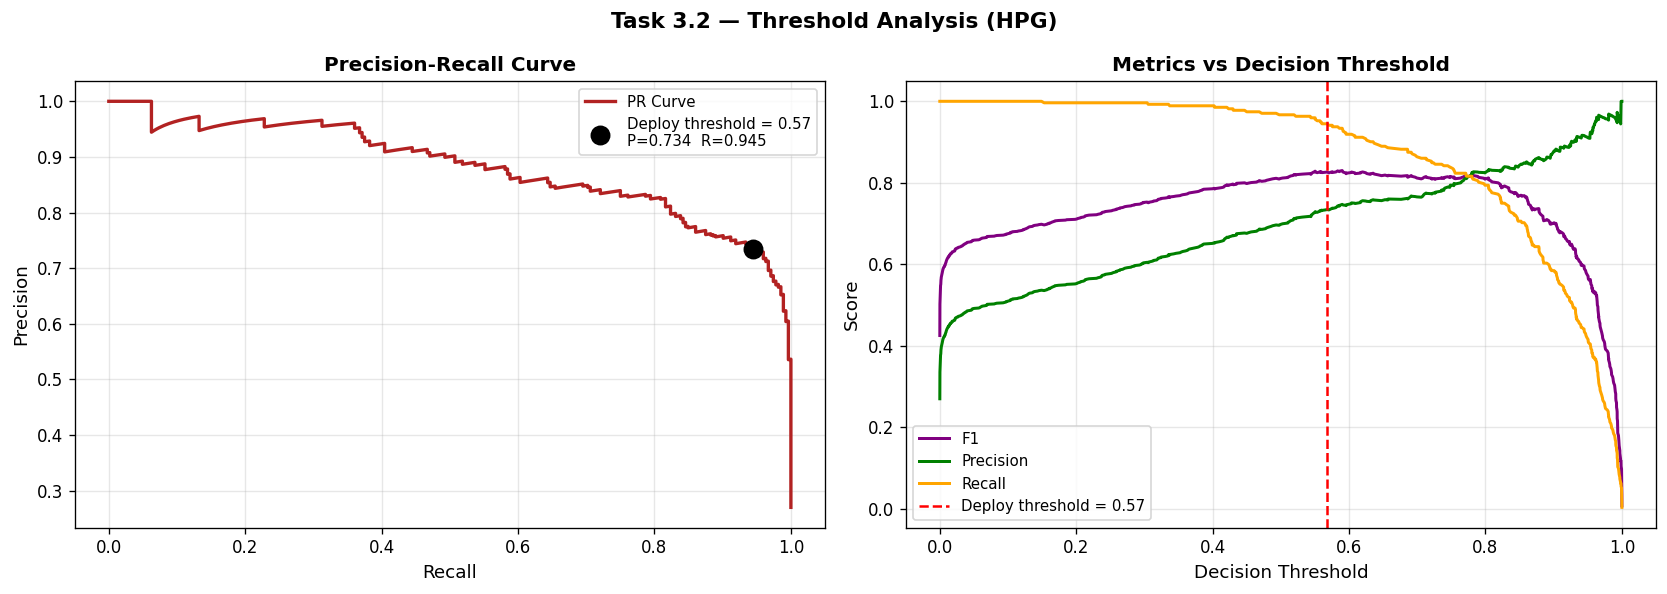

Saved → task3_2_threshold_analysis.png


In [ ]:
# STEP 5C: THRESHOLD ANALYSIS PLOT (same as 3.1)

prec_t, rec_t, thresh_t = precision_recall_curve(y_true, sell_prob)
f1_t = (2 * prec_t * rec_t) / (prec_t + rec_t + 1e-8)

deploy_idx = min(np.searchsorted(thresh_t, DEPLOY_THRESHOLD), len(prec_t) - 2)

fig_thresh, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# Left: Precision-Recall Curve
axes[0].plot(rec_t, prec_t, color="firebrick", linewidth=2, label="PR Curve")
axes[0].scatter(
    rec_t[deploy_idx], prec_t[deploy_idx],
    color="black", s=120, zorder=5,
    label=(f"Deploy threshold = {DEPLOY_THRESHOLD:.2f}\n"
           f"P={prec_t[deploy_idx]:.3f}  R={rec_t[deploy_idx]:.3f}")
)
axes[0].set_xlabel("Recall", fontsize=11)
axes[0].set_ylabel("Precision", fontsize=11)
axes[0].set_title("Precision-Recall Curve", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Right: Metrics vs Threshold
axes[1].plot(thresh_t, f1_t[:-1],   label="F1",        color="purple",  linewidth=1.8)
axes[1].plot(thresh_t, prec_t[:-1], label="Precision",  color="green",   linewidth=1.8)
axes[1].plot(thresh_t, rec_t[:-1],  label="Recall",     color="orange",  linewidth=1.8)
axes[1].axvline(DEPLOY_THRESHOLD, color="red", linestyle="--", linewidth=1.5,
                label=f"Deploy threshold = {DEPLOY_THRESHOLD:.2f}")
axes[1].set_xlabel("Decision Threshold", fontsize=11)
axes[1].set_ylabel("Score", fontsize=11)
axes[1].set_title("Metrics vs Decision Threshold", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle(f"Task 3.2 — Threshold Analysis ({TEST_TICKER})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "task3_2_threshold_analysis.png"),
            bbox_inches="tight")
plt.show()
print("Saved → task3_2_threshold_analysis.png")

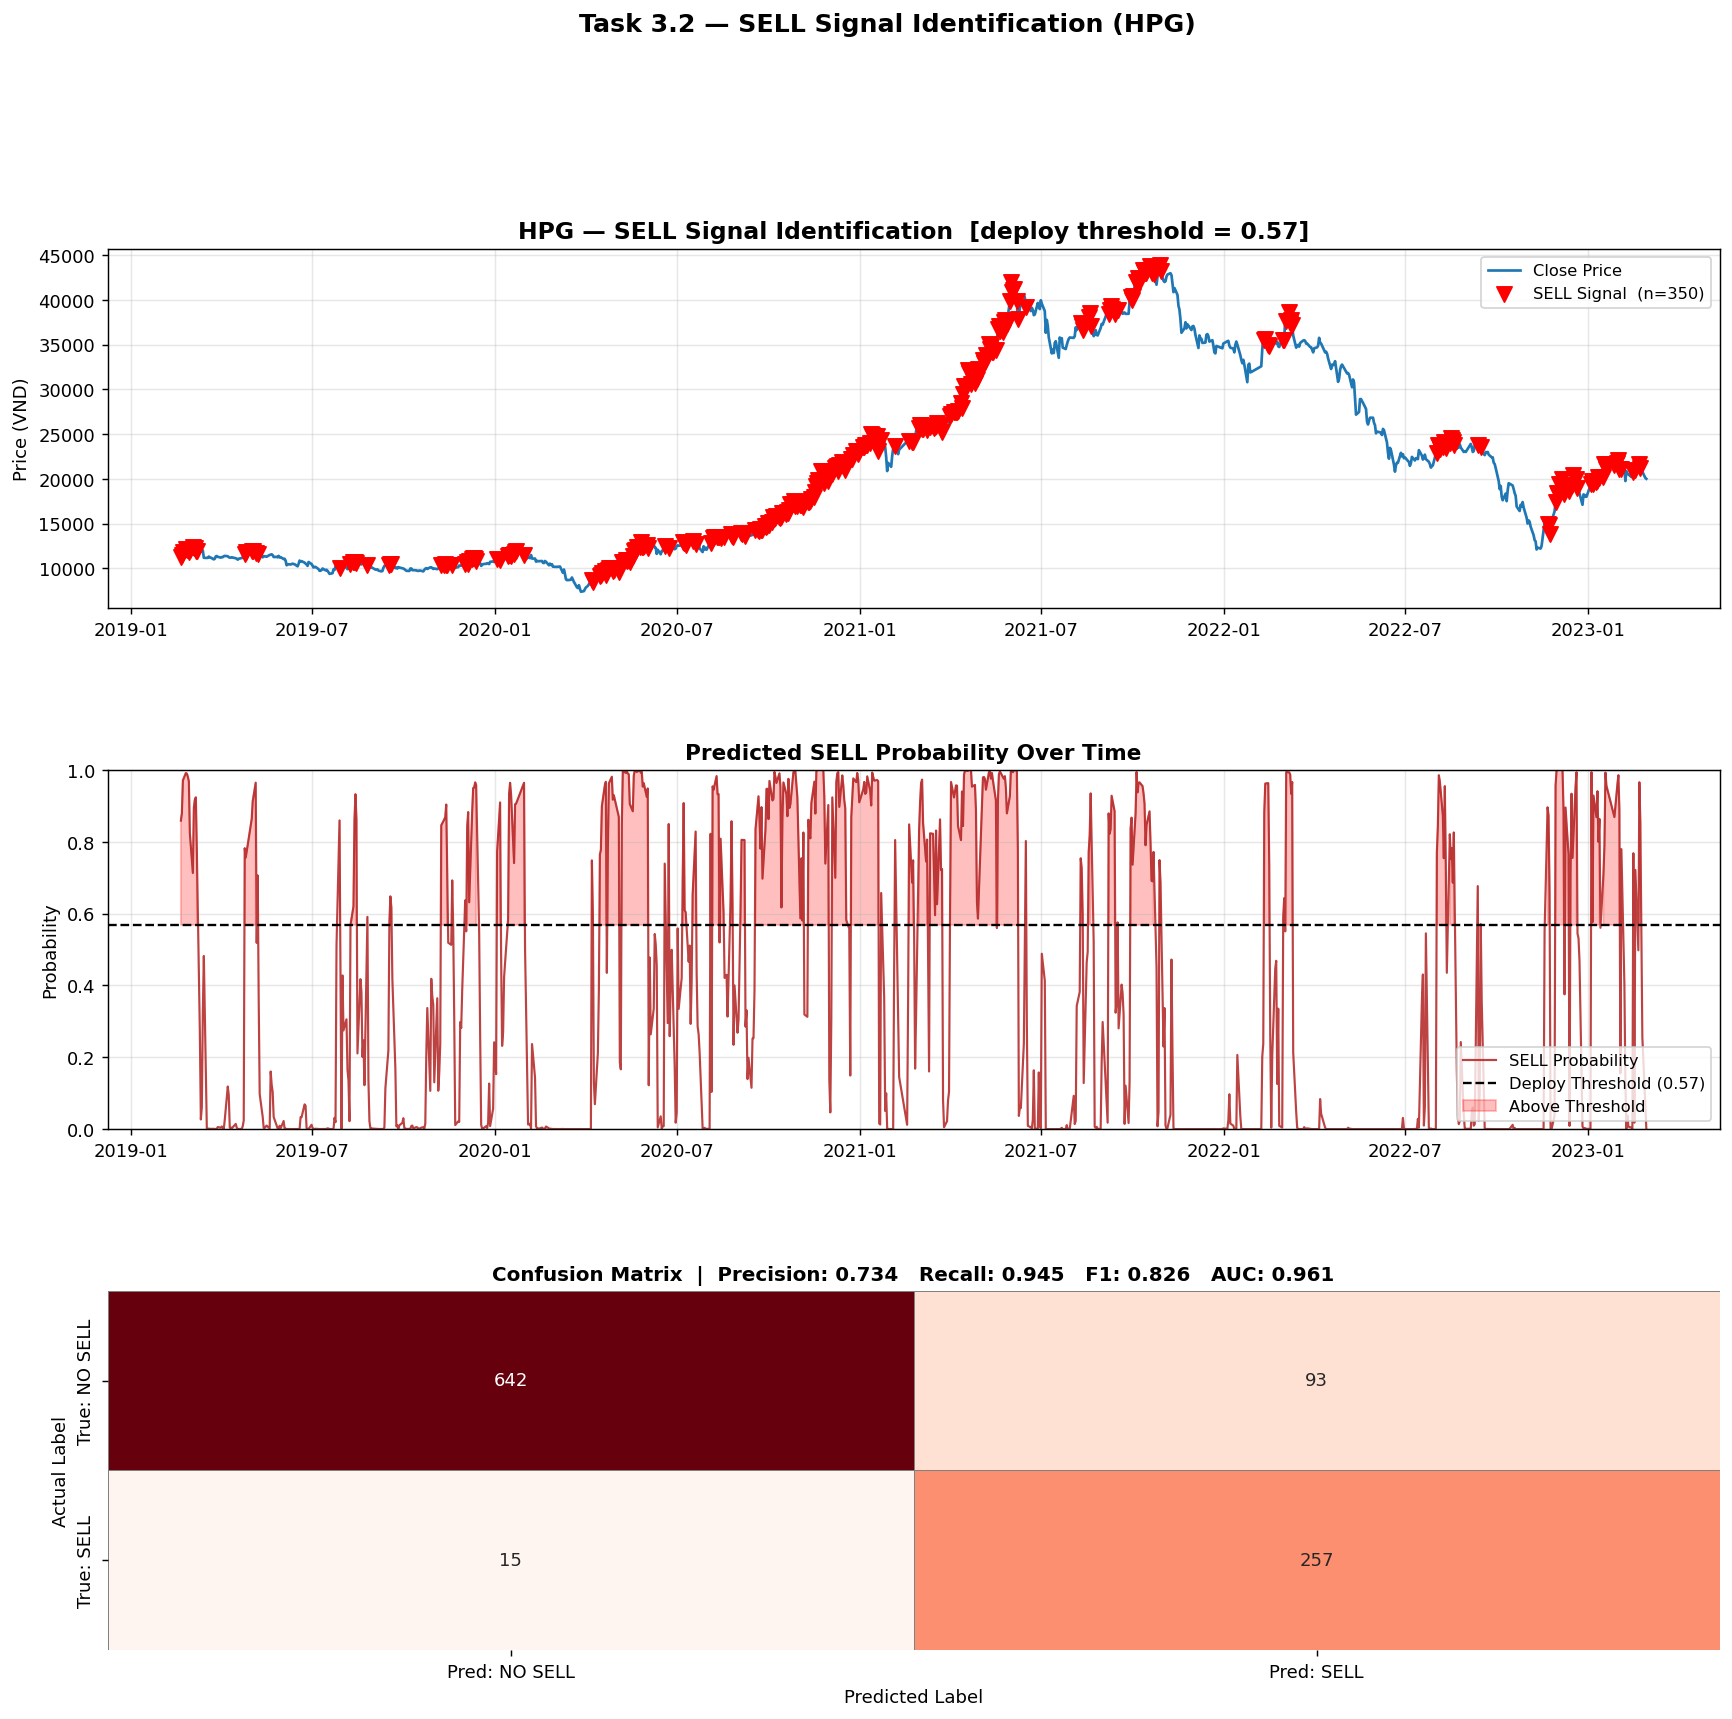

Saved → task3_2_sell_signal.png


In [ ]:
# STEP 5D: VISUALIZATION

sell_idx = np.where(sell_signal == 1)[0]

fig = plt.figure(figsize=(16, 14), dpi=130)
gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45)

# Panel 1: Price + Sell signals
ax1 = fig.add_subplot(gs[0])
ax1.plot(dates, close_prices, color="#1f77b4", linewidth=1.5,
         label="Close Price", zorder=2)
ax1.scatter(dates[sell_idx], close_prices[sell_idx],
            color="red", marker="v", s=70, zorder=3,
            label=f"SELL Signal  (n={len(sell_idx)})")
ax1.set_title(
    f"{TEST_TICKER} — SELL Signal Identification  "
    f"[deploy threshold = {DEPLOY_THRESHOLD:.2f}]",
    fontsize=13, fontweight="bold"
)
ax1.set_ylabel("Price (VND)")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Panel 2: SELL probability timeline
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.plot(dates, sell_prob, color="firebrick", linewidth=1.2,
         label="SELL Probability", alpha=0.85)
ax2.axhline(DEPLOY_THRESHOLD, color="black", linestyle="--", linewidth=1.3,
            label=f"Deploy Threshold ({DEPLOY_THRESHOLD:.2f})")
ax2.fill_between(
    dates, sell_prob, DEPLOY_THRESHOLD,
    where=(sell_prob >= DEPLOY_THRESHOLD),
    alpha=0.25, color="red", label="Above Threshold"
)
ax2.set_ylabel("Probability")
ax2.set_ylim(0, 1)
ax2.set_title("Predicted SELL Probability Over Time",
              fontsize=12, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# Panel 3: Confusion matrix
ax3 = fig.add_subplot(gs[2])
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Reds",   # red palette for SELL
    xticklabels=["Pred: NO SELL", "Pred: SELL"],
    yticklabels=["True: NO SELL", "True: SELL"],
    ax=ax3, cbar=False, linewidths=0.5, linecolor="gray"
)
ax3.set_title(
    f"Confusion Matrix  |  "
    f"Precision: {prec:.3f}   Recall: {rec:.3f}   "
    f"F1: {f1:.3f}   AUC: {auc_score:.3f}",
    fontsize=11, fontweight="bold"
)
ax3.set_ylabel("Actual Label")
ax3.set_xlabel("Predicted Label")

plt.suptitle(f"Task 3.2 — SELL Signal Identification ({TEST_TICKER})",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(os.path.join(SAVE_DIR, "task3_2_sell_signal.png"),
            bbox_inches="tight")
plt.show()
print("Saved → task3_2_sell_signal.png")

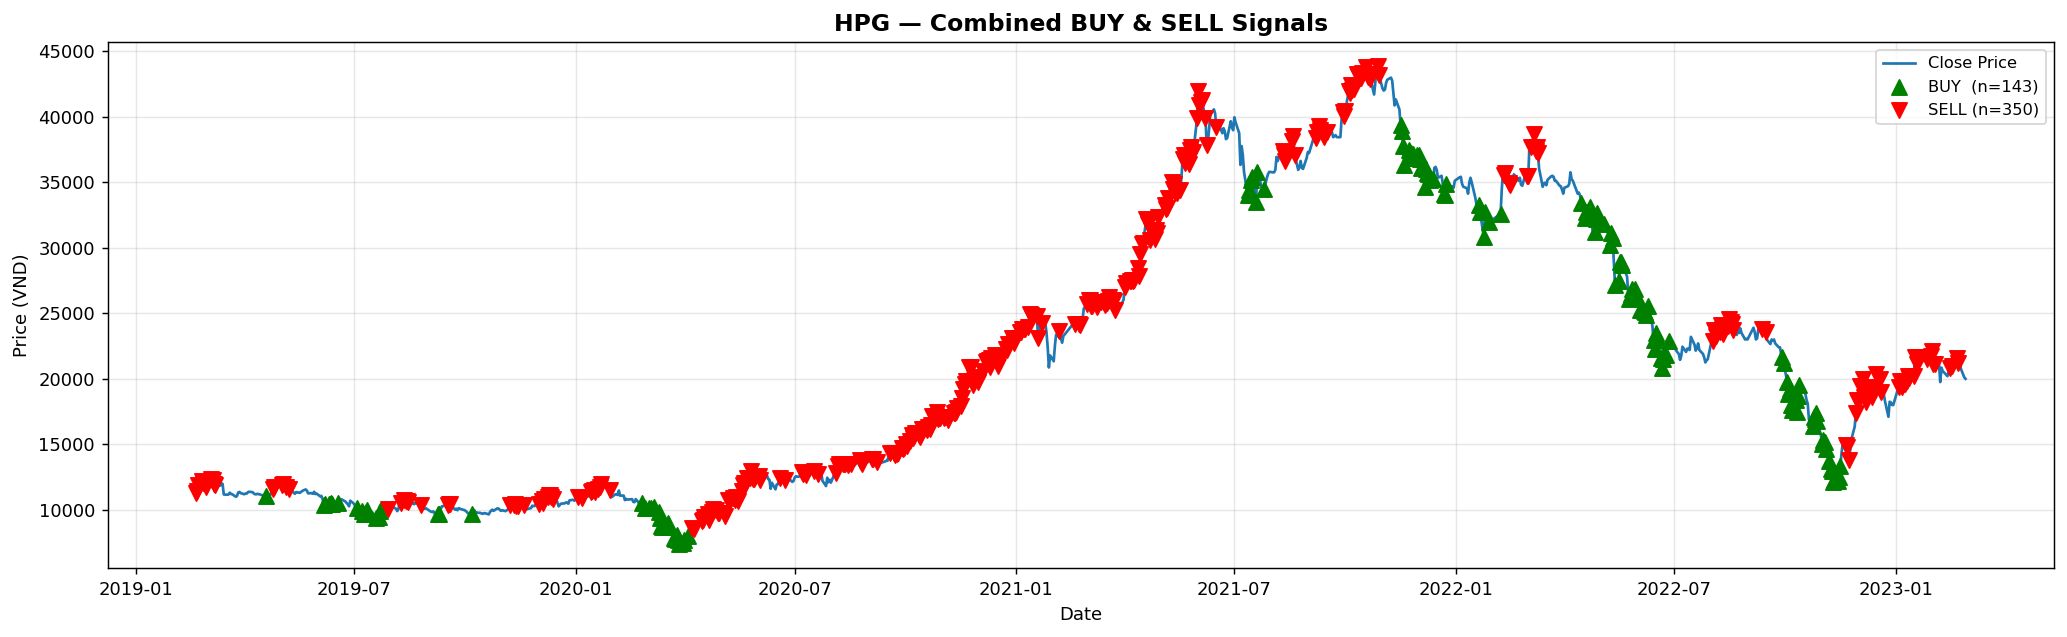

Saved → task3_2_sell_model/task3_combined_signals.png


In [ ]:
# STEP 5E: COMBINED BUY + SELL VISUALIZATION

try:
    # Attempt to use BUY signals from Task 3.1 (same test period)
    fig_combined, ax = plt.subplots(figsize=(16, 5), dpi=130)

    ax.plot(dates, close_prices, color="#1f77b4", linewidth=1.5,
            label="Close Price", zorder=2)

    # BUY markers (green upward triangles)
    buy_idx_combined = np.where(buy_signal == 1)[0]
    ax.scatter(dates[buy_idx_combined], close_prices[buy_idx_combined],
               color="green", marker="^", s=70, zorder=4,
               label=f"BUY  (n={len(buy_idx_combined)})")

    # SELL markers (red downward triangles)
    ax.scatter(dates[sell_idx], close_prices[sell_idx],
               color="red", marker="v", s=70, zorder=4,
               label=f"SELL (n={len(sell_idx)})")

    ax.set_title(
        f"{TEST_TICKER} — Combined BUY & SELL Signals",
        fontsize=13, fontweight="bold"
    )
    ax.set_ylabel("Price (VND)")
    ax.set_xlabel("Date")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    combined_path = os.path.join(SAVE_DIR, "task3_combined_signals.png")
    plt.savefig(combined_path, bbox_inches="tight")
    plt.show()
    print(f"Saved → {combined_path}")

except NameError:
    print("Combined plot skipped: run Task 3.1 first to have buy_signal available.")

# Task 4 (30%) Profitable stock selection, risk management and portfolio composition for Vietnam market

## Task 4.1 - Profitable stock selection


Briefly on methodology: Profitable stock is identified by expected return, and expected return is calculated based on the difference between predicted price from the mmodel and actual price from the dataset (plus the dividend yield).

In [ ]:
#  CONFIGURATION

DIVIDEND_SUBDIR = HOSE_DATA_DIR
SAVE_DIR        = "task4_portfolio"
os.makedirs(SAVE_DIR, exist_ok=True)

DATE_COL         = "TradingDate"
K                = 7                        # forecast horizon (days)
TOP_N            = 8                        # number of stocks to select
RISK_FREE_RATE   = 0.04                     # Vietnam 1-yr bond ~4%

In [ ]:
# STEP 1: LOAD THE TASK 2.3 MODEL

MODEL_PATH = "task2_3_vietnam_model.keras"

if os.path.exists(MODEL_PATH):
    forecast_model = tf.keras.models.load_model(MODEL_PATH)
    print(f"Loaded Task 2.3 model from {MODEL_PATH}")
else:
    # Fall back to the model already in memory from Task 2.3
    forecast_model = model
    print("Using Task 2.3 model already in memory.")

Loaded Task 2.3 model from task2_3_vietnam_model.keras


In [ ]:
# GENERATE K-DAY PRICE FORECAST FOR ONE STOCK

def forecast_next_k_days(df, model, window_size, k,
                          feature_indices, target_index):

    features     = df.iloc[:, feature_indices].values.astype(float)
    close_prices = df.iloc[:, target_index].values.astype(float)

    # Use the very last window available in the data
    window       = features[-window_size:]
    close_window = close_prices[-window_size:]

    # Per-window min-max normalization (same as training)
    f_min  = window.min(axis=0)
    f_max  = window.max(axis=0)
    f_diff = np.where(f_max - f_min == 0, 1e-8, f_max - f_min)
    window_norm = (window - f_min) / f_diff

    # Add batch dimension: (1, window_size, num_features)
    X_input = window_norm[np.newaxis, :, :]

    # Predict normalized K-day prices
    y_pred_norm = model.predict(X_input, verbose=0)   # shape: (1, k)

    # Determine target feature position within feature_indices
    target_feat_idx = feature_indices.index(target_index)

    # Denormalize using the same window statistics
    target_min  = f_min[target_feat_idx]
    target_diff = f_diff[target_feat_idx]
    forecast_prices = y_pred_norm[0] * target_diff + target_min

    # Most recent actual Close price (the "present" price)
    last_close = close_prices[-1]

    return forecast_prices, last_close

In [ ]:
# STEP 3: GENERATE FORECASTS FOR ALL TICKERS

# For each stock we record:
#   last_close      : price at t=0 (last trading day)
#   forecast_prices : array of K predicted prices [t+1 … t+K]
#   predicted_return: (price[t+K] - price[t]) / price[t]

print("=== Generating K-day Price Forecasts ===")
forecast_records = {}

for ticker in TICKERS:
    df = raw_stock_data[ticker]

    # Use only the test-period data (post FINAL_TEST_DATE)
    test_df = df[
        df[DATE_COL] >= pd.to_datetime(FINAL_TEST_DATE, utc=True)
    ].reset_index(drop=True)

    # Need at least WINDOW_SIZE rows to make a forecast
    if len(test_df) < WINDOW_SIZE:
        print(f"  {ticker}: insufficient test data, skipping.")
        continue

    # Generate K-day forecast
    forecast_prices, last_close = forecast_next_k_days(
        test_df, forecast_model,
        WINDOW_SIZE, K,
        FEATURE_INDICES, TARGET_INDEX
    )

    # Predicted return over the K-day horizon
    predicted_return = (forecast_prices[-1] - last_close) / (last_close + 1e-8)

    forecast_records[ticker] = {
        "last_close":       last_close,
        "forecast_prices":  forecast_prices,
        "predicted_return": predicted_return,
    }

    print(f"  {ticker} | Last Close: {last_close:,.0f} VND | "
          f"Forecast[t+{K}]: {forecast_prices[-1]:,.0f} VND | "
          f"Predicted Return: {predicted_return:+.2%}")

=== Generating K-day Price Forecasts ===
  BID | Last Close: 44,100 VND | Forecast[t+7]: 45,464 VND | Predicted Return: +3.09%
  FPT | Last Close: 80,500 VND | Forecast[t+7]: 80,970 VND | Predicted Return: +0.58%
  GAS | Last Close: 103,500 VND | Forecast[t+7]: 105,502 VND | Predicted Return: +1.93%
  HPG | Last Close: 20,000 VND | Forecast[t+7]: 21,316 VND | Predicted Return: +6.58%
  HSG | Last Close: 14,550 VND | Forecast[t+7]: 15,323 VND | Predicted Return: +5.32%
  MBB | Last Close: 17,250 VND | Forecast[t+7]: 17,486 VND | Predicted Return: +1.37%
  MWG | Last Close: 40,000 VND | Forecast[t+7]: 42,715 VND | Predicted Return: +6.79%
  CTG | Last Close: 27,400 VND | Forecast[t+7]: 27,146 VND | Predicted Return: -0.93%
  SSI | Last Close: 18,250 VND | Forecast[t+7]: 19,456 VND | Predicted Return: +6.61%
  VCB | Last Close: 93,500 VND | Forecast[t+7]: 92,759 VND | Predicted Return: -0.79%
  VIC | Last Close: 52,600 VND | Forecast[t+7]: 54,267 VND | Predicted Return: +3.17%
  VNM | Las

In [ ]:
# STEP 4: LOAD DIVIDEND HISTORY & COMPUTE DIVIDEND YIELD

# Dividend yield = total cash dividends paid in the past year divided by the current stock price.

# We sum all CASH dividends from the past 12 months and divide
# by the par value (10,000 VND standard in Vietnam) to get
# the absolute dividend amount, then divide by last_close for yield.
#
# If no dividend file exists for a ticker we assume yield = 0.

VIETNAM_PAR_VALUE = 10_000   # standard par value on HOSE

def load_dividend_yield(ticker, data_dir, last_close,
                        par_value=VIETNAM_PAR_VALUE,
                        lookback_years=2): # lookback_years: 2

    # Try standard HOSE dividend file name
    file_path = os.path.join(
        data_dir, f"{ticker}-VNINDEX-Dividend.csv"
    )

    if not os.path.exists(file_path):
        return 0.0, None

    try:
        div_df = pd.read_csv(file_path)

        # Parse exercise date
        div_df["exerciseDate"] = pd.to_datetime(
            div_df["exerciseDate"], dayfirst=True,
            format="mixed", utc=True
        )

        # Filter to cash dividends only (exclude stock dividends)
        div_df = div_df[div_df["issueMethod"].str.lower() == "cash"].copy()

        # Use the dataset's latest date as a fixed reference point for dividend calculation
        current_reference_date = test_df[DATE_COL].iloc[-1]
        cutoff = current_reference_date - pd.DateOffset(years=lookback_years)

        # Filter to lookback window
        div_df = div_df[div_df["exerciseDate"] >= cutoff]

        if div_df.empty:
            return 0.0, div_df

        # cashDividendPercentage is relative to par value (0.05 means 5% × 10,000 = 500 VND per share)
        total_cash_div = div_df["cashDividendPercentage"].sum() * par_value

        # Yield = total cash dividend / current market price
        div_yield = total_cash_div / (last_close + 1e-8)

        return div_yield, div_df

    except Exception as e:
        print(f"  Warning: could not load dividend data for {ticker}: {e}")
        return 0.0, None

# Load dividend yields for all tickers
print("\n=== Loading Dividend Yields ===")
dividend_records = {}

for ticker in forecast_records:
    last_close = forecast_records[ticker]["last_close"]
    div_yield, div_df = load_dividend_yield(
        ticker, DIVIDEND_SUBDIR, last_close
    )
    dividend_records[ticker] = {
        "div_yield": div_yield,
        "div_df":    div_df
    }
    print(f"  {ticker} | Dividend Yield: {div_yield:.2%}")


=== Loading Dividend Yields ===
  BID | Dividend Yield: 0.45%
  FPT | Dividend Yield: 4.97%
  GAS | Dividend Yield: 5.80%
  HPG | Dividend Yield: 5.00%
  HSG | Dividend Yield: 0.00%
  MBB | Dividend Yield: 0.00%
  MWG | Dividend Yield: 3.75%
  CTG | Dividend Yield: 2.92%
  SSI | Dividend Yield: 10.96%
  VCB | Dividend Yield: 1.28%
  VIC | Dividend Yield: 0.00%
  VNM | Dividend Yield: 10.40%


In [ ]:
# CHECK THE CORRECTNESS OF STEP 4 CODE
print("\n=== Dividend History Overview per Ticker ===")

dividend_history_info = []

for ticker in TICKERS:
    # need a dummy 'last_close' price to call load_dividend_yield for its df
    last_close_dummy = 1.0

    # Calling load_dividend_yield, but modified to always return div_df if it exists
    # (even if yield is 0 due to no recent dividends)
    div_yield, div_df = load_dividend_yield(ticker, DIVIDEND_SUBDIR, last_close_dummy)

    if div_df is not None and not div_df.empty:
        start_date = div_df['exerciseDate'].min().strftime('%Y-%m-%d')
        end_date = div_df['exerciseDate'].max().strftime('%Y-%m-%d')
        total_records = len(div_df)
        dividend_history_info.append({
            'Ticker': ticker,
            'Dividend Start Date': start_date,
            'Dividend End Date': end_date,
            'Total Dividend Records': total_records
        })
    else:
        dividend_history_info.append({
            'Ticker': ticker,
            'Dividend Start Date': 'N/A',
            'Dividend End Date': 'N/A',
            'Total Dividend Records': 0
        })

dividend_overview_df = pd.DataFrame(dividend_history_info)
print(dividend_overview_df.to_markdown(index=False))


=== Dividend History Overview per Ticker ===
| Ticker   | Dividend Start Date   | Dividend End Date   |   Total Dividend Records |
|:---------|:----------------------|:--------------------|-------------------------:|
| BID      | 2021-12-23            | 2021-12-23          |                        1 |
| FPT      | 2021-06-01            | 2022-08-24          |                        4 |
| GAS      | 2021-06-28            | 2022-07-04          |                        2 |
| HPG      | 2021-05-31            | 2022-06-17          |                        2 |
| HSG      | N/A                   | N/A                 |                        0 |
| MBB      | N/A                   | N/A                 |                        0 |
| MWG      | 2021-08-30            | 2022-06-07          |                        2 |
| CTG      | 2021-12-14            | 2021-12-14          |                        1 |
| SSI      | 2021-06-15            | 2022-06-22          |                        2 |
| VCB   

In [ ]:
# STEP 5: COMPUTE TOTAL EXPECTED RETURN & RANK STOCKS
# Total Expected Return = Predicted Price Return + Dividend Yield

# Annualized price return = predicted_return × (252 / K)
# where 252 is the approximate number of trading days per year.

TRADING_DAYS_PER_YEAR = 252

print("\n=== Computing Total Expected Return ===")
results = []

for ticker in forecast_records:
    pred_return = forecast_records[ticker]["predicted_return"]
    div_yield   = dividend_records[ticker]["div_yield"]

    # Annualize the K-day predicted price return
    annualized_price_return = pred_return * (TRADING_DAYS_PER_YEAR / K)

    # Total expected return
    total_return = annualized_price_return + div_yield

    results.append({
        "Ticker":                   ticker,
        "Last Close (VND)":         forecast_records[ticker]["last_close"],
        f"Forecast t+{K} (VND)":    forecast_records[ticker]["forecast_prices"][-1],
        "Predicted Return (K-day)": pred_return,
        "Annualized Price Return":  annualized_price_return,
        "Dividend Yield":           div_yield,
        "Total Expected Return":    total_return,
    })

# Build results DataFrame and rank by total return
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    "Total Expected Return", ascending=False
).reset_index(drop=True)

results_df["Rank"] = results_df.index + 1

print("\n=== Stock Ranking by Total Expected Return ===")
print(results_df[[
    "Rank", "Ticker",
    "Last Close (VND)", f"Forecast t+{K} (VND)",
    "Predicted Return (K-day)", "Dividend Yield",
    "Total Expected Return"
]].to_markdown(index=False, floatfmt=".4f"))


=== Computing Total Expected Return ===

=== Stock Ranking by Total Expected Return ===
|   Rank | Ticker   |   Last Close (VND) |   Forecast t+7 (VND) |   Predicted Return (K-day) |   Dividend Yield |   Total Expected Return |
|-------:|:---------|-------------------:|---------------------:|---------------------------:|-----------------:|------------------------:|
|      1 | SSI      |         18250.0000 |           19456.2742 |                     0.0661 |           0.1096 |                  2.4891 |
|      2 | MWG      |         40000.0000 |           42715.1848 |                     0.0679 |           0.0375 |                  2.4812 |
|      3 | HPG      |         20000.0000 |           21315.6429 |                     0.0658 |           0.0500 |                  2.4182 |
|      4 | HSG      |         14550.0000 |           15323.4269 |                     0.0532 |           0.0000 |                  1.9136 |
|      5 | VNM      |         75500.0000 |           78953.4310 |      

In [ ]:
# STEP 6: SELECT TOP-N STOCKS FOR THE PORTFOLIO

# Filter: only positive total expected return
positive_df = results_df[results_df["Total Expected Return"] > 0]

# Select top N
selected_df = positive_df.head(TOP_N).copy()

print(f"\n=== Selected Portfolio Stocks (Top {TOP_N}) ===")
print(selected_df[[
    "Rank", "Ticker",
    "Predicted Return (K-day)",
    "Dividend Yield",
    "Total Expected Return"
]].to_markdown(index=False, floatfmt=".4f"))

# Store selected tickers for use in Task 4.2 and 4.3
SELECTED_TICKERS = selected_df["Ticker"].tolist()
print(f"\nSelected tickers: {SELECTED_TICKERS}")


=== Selected Portfolio Stocks (Top 8) ===
|   Rank | Ticker   |   Predicted Return (K-day) |   Dividend Yield |   Total Expected Return |
|-------:|:---------|---------------------------:|-----------------:|------------------------:|
|      1 | SSI      |                     0.0661 |           0.1096 |                  2.4891 |
|      2 | MWG      |                     0.0679 |           0.0375 |                  2.4812 |
|      3 | HPG      |                     0.0658 |           0.0500 |                  2.4182 |
|      4 | HSG      |                     0.0532 |           0.0000 |                  1.9136 |
|      5 | VNM      |                     0.0457 |           0.1040 |                  1.7506 |
|      6 | VIC      |                     0.0317 |           0.0000 |                  1.1409 |
|      7 | BID      |                     0.0309 |           0.0045 |                  1.1178 |
|      8 | GAS      |                     0.0193 |           0.0580 |                  0.7544

In [ ]:
# STEP 7: SAVE RESULTS FOR TASK 4.2 / 4.3
# Persist forecast and return data so downstream tasks can load without re-running the model.

# Save full ranking table
ranking_path = os.path.join(SAVE_DIR, "task4_1_stock_ranking.csv")
results_df.to_csv(ranking_path, index=False)
print(f"\nRanking saved → {ranking_path}")

# Save portfolio config (selected tickers + their expected returns)
portfolio_config = {
    "selected_tickers":  SELECTED_TICKERS,
    "top_n":             TOP_N,
    "forecast_horizon":  K,
    "risk_free_rate":    RISK_FREE_RATE,
    "final_test_date":   FINAL_TEST_DATE,
    "returns": {
        row["Ticker"]: {
            "predicted_return":      row["Predicted Return (K-day)"],
            "annualised_price_return": row["Annualized Price Return"],
            "div_yield":             row["Dividend Yield"],
            "total_return":          row["Total Expected Return"],
            "last_close":            row["Last Close (VND)"],
        }
        for _, row in selected_df.iterrows()
    }
}

config_path = os.path.join(SAVE_DIR, "task4_1_portfolio_config.json")
with open(config_path, "w") as f:
    json.dump(portfolio_config, f, indent=2)
print(f"Portfolio config saved → {config_path}")


Ranking saved → task4_portfolio/task4_1_stock_ranking.csv
Portfolio config saved → task4_portfolio/task4_1_portfolio_config.json


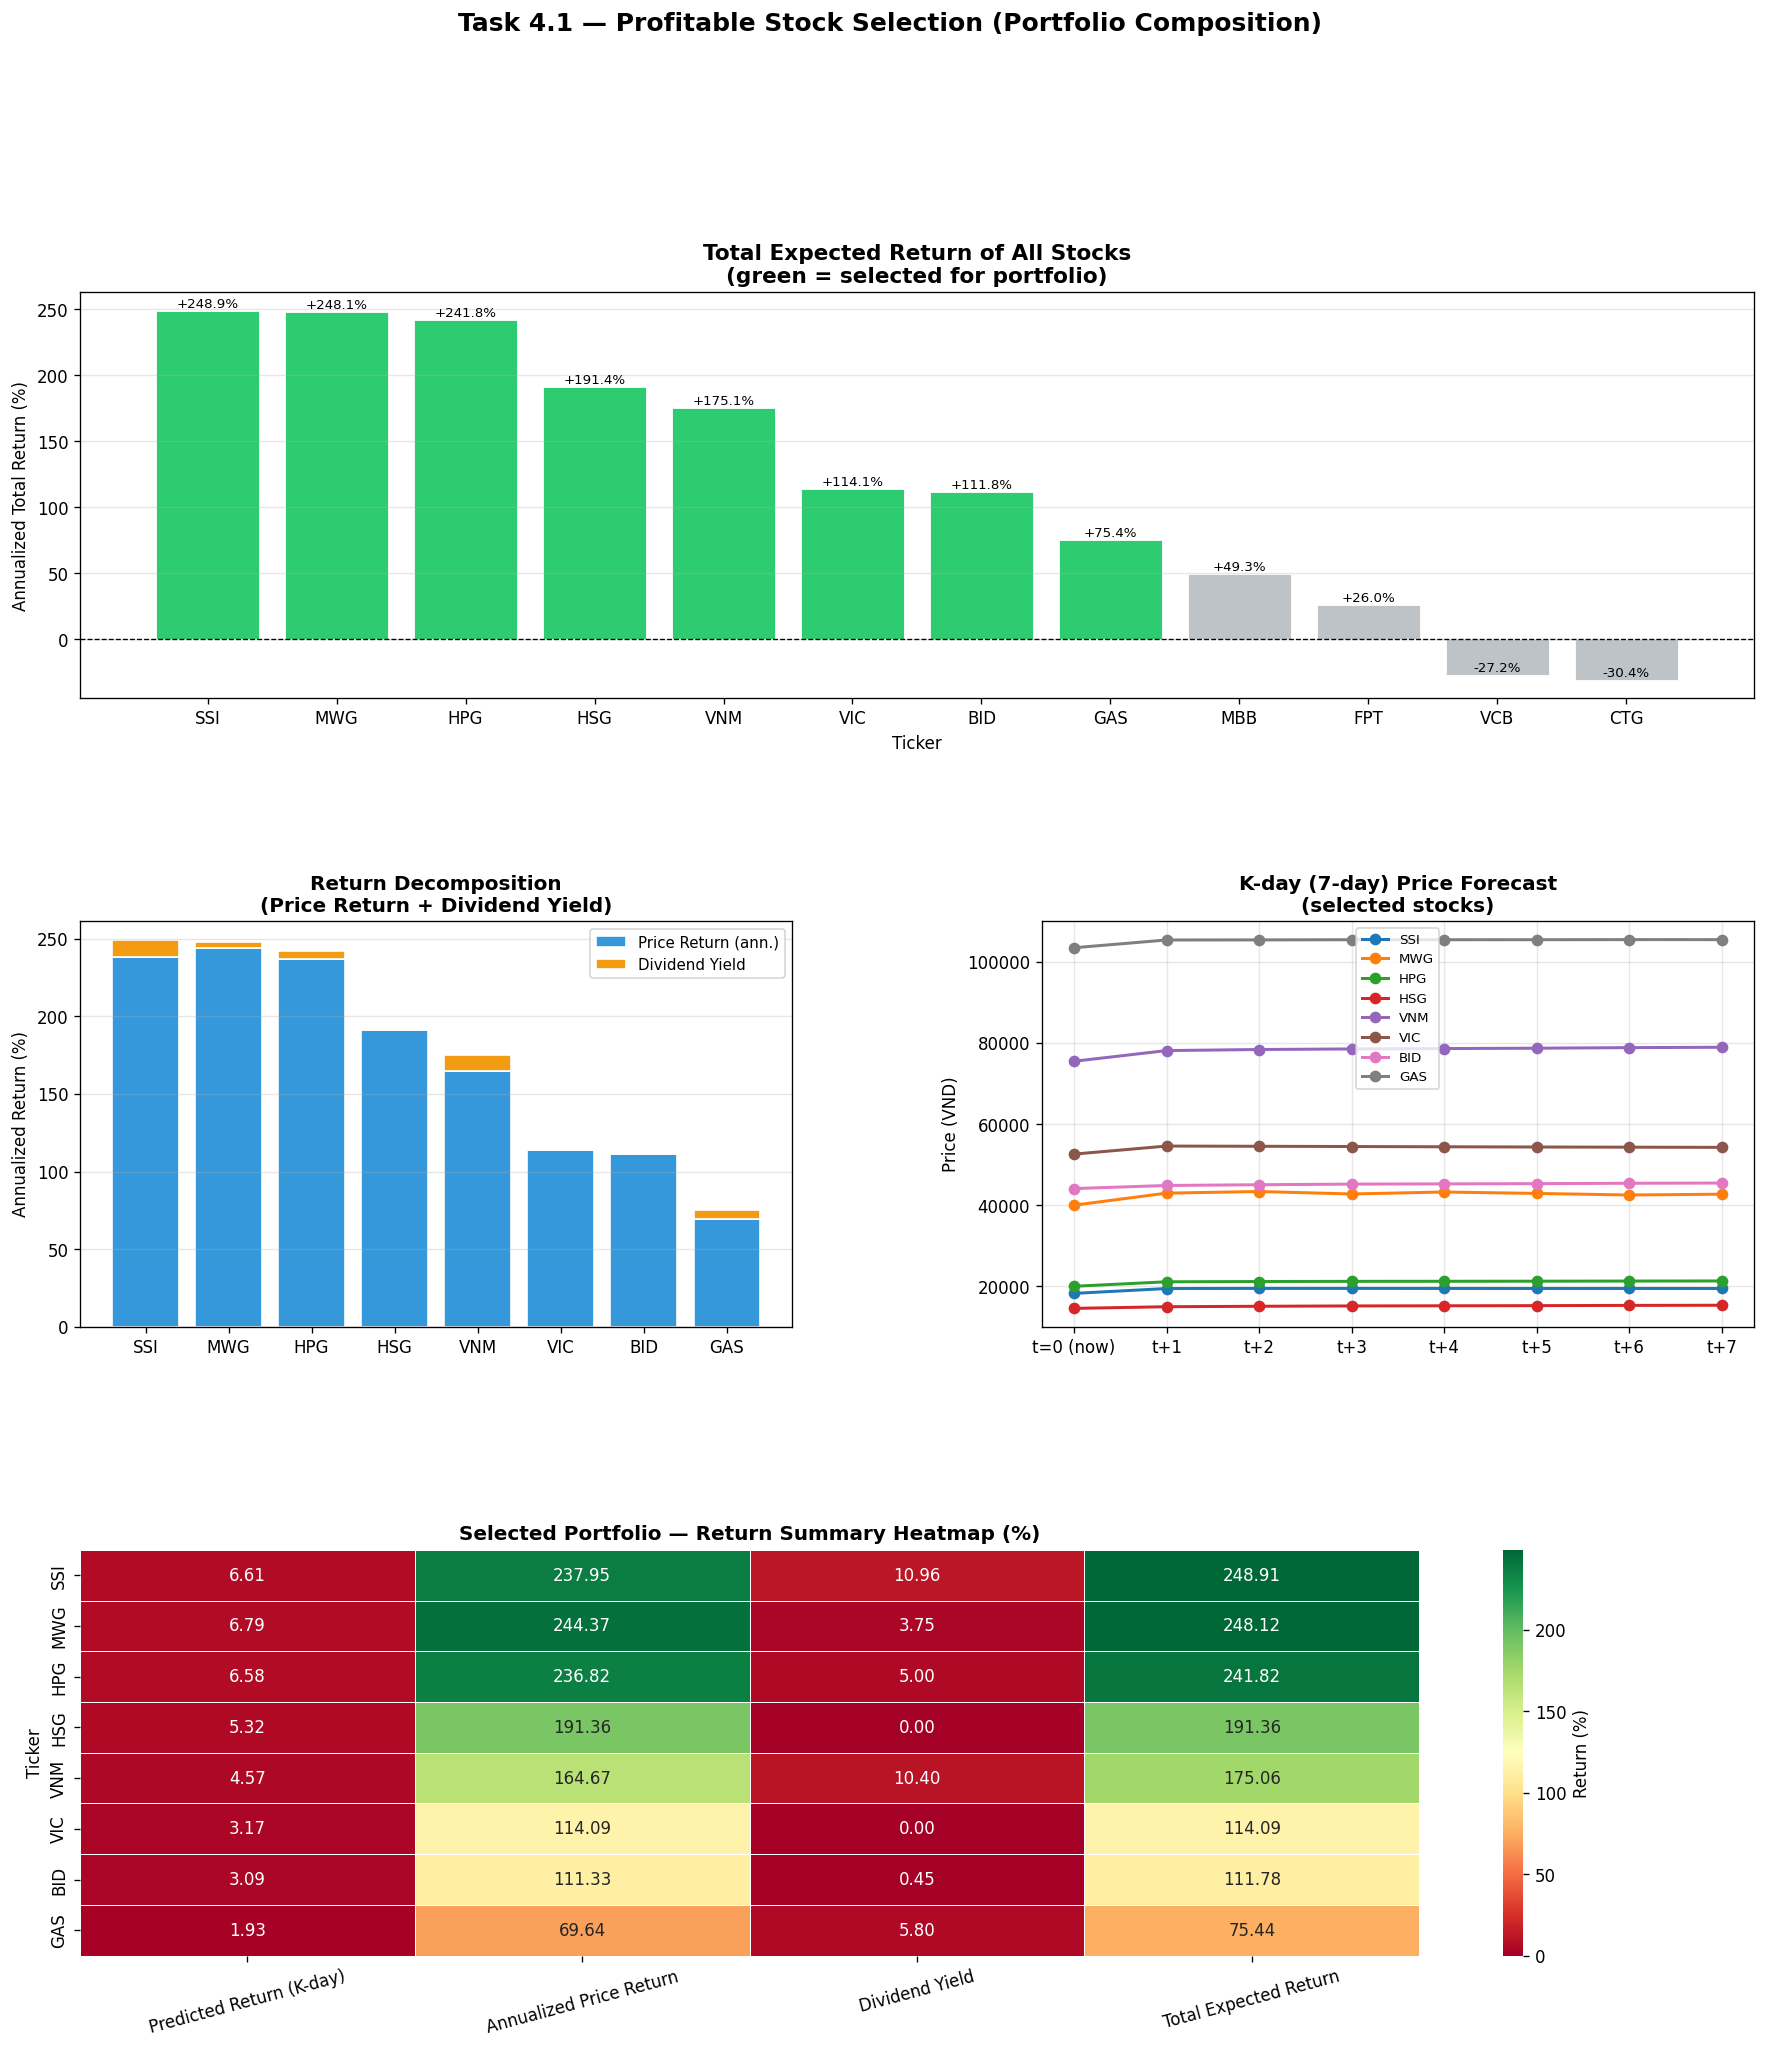

Figure saved → task4_portfolio/task4_1_stock_selection.png

TASK 4.1 SUMMARY
  Total          : 12 stocks
  Forecast horizon  : 7 trading days
  Stocks selected   : 8 (positive return, top 8)
  Selected          : ['SSI', 'MWG', 'HPG', 'HSG', 'VNM', 'VIC', 'BID', 'GAS']
  Best return       : SSI (+248.91% ann.)
  Outputs saved to  : task4_portfolio/


In [ ]:
# STEP 8: VISUALIZATIONS

fig = plt.figure(figsize=(18, 18), dpi=120)
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)

colors_all      = [
    "#2ecc71" if t in SELECTED_TICKERS else "#bdc3c7"
    for t in results_df["Ticker"]
]
colors_selected = ["#2ecc71"] * len(selected_df)

# Panel 1: Total expected return of all stocks
ax1 = fig.add_subplot(gs[0, :])   # full width
bars = ax1.bar(
    results_df["Ticker"],
    results_df["Total Expected Return"] * 100,
    color=colors_all, edgecolor="white", linewidth=0.5
)
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_title("Total Expected Return of All Stocks\n"
              "(green = selected for portfolio)",
              fontsize=13, fontweight="bold")
ax1.set_ylabel("Annualized Total Return (%)")
ax1.set_xlabel("Ticker")
ax1.grid(axis="y", alpha=0.3)

# Annotate bars
for bar, val in zip(bars, results_df["Total Expected Return"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{val*100:+.1f}%",
        ha="center", va="bottom", fontsize=8
    )

# Panel 2: Stacked return decomposition of selected stocks
ax2 = fig.add_subplot(gs[1, 0])
price_rets = selected_df["Annualized Price Return"] * 100
div_yields = selected_df["Dividend Yield"] * 100

x = np.arange(len(selected_df))
ax2.bar(x, price_rets, label="Price Return (ann.)",
        color="#3498db", edgecolor="white")
ax2.bar(x, div_yields, bottom=price_rets,
        label="Dividend Yield", color="#f39c12", edgecolor="white")
ax2.set_xticks(x)
ax2.set_xticklabels(selected_df["Ticker"])
ax2.set_title("Return Decomposition\n(Price Return + Dividend Yield)",
              fontsize=12, fontweight="bold")
ax2.set_ylabel("Annualized Return (%)")
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)

# Panel 3: K-day forecast price paths of selected stocks
ax3 = fig.add_subplot(gs[1, 1])
days = np.arange(0, K + 1)   # day 0 = last_close, days 1..K = forecast

for ticker in SELECTED_TICKERS:
    last_close     = forecast_records[ticker]["last_close"]
    forecast_prices = forecast_records[ticker]["forecast_prices"]
    path = np.concatenate([[last_close], forecast_prices])
    ax3.plot(days, path, marker="o", linewidth=1.8, label=ticker)

ax3.set_xticks(days)
ax3.set_xticklabels(
    ["t=0 (now)"] + [f"t+{d}" for d in range(1, K + 1)]
)
ax3.set_title(f"K-day ({K}-day) Price Forecast\n(selected stocks)",
              fontsize=12, fontweight="bold")
ax3.set_ylabel("Price (VND)")
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

# Panel 4: Summary heatmap table
ax4 = fig.add_subplot(gs[2, :])   # full width

heatmap_data = selected_df.set_index("Ticker")[[
    "Predicted Return (K-day)",
    "Annualized Price Return",
    "Dividend Yield",
    "Total Expected Return"
]] * 100   # convert to percent

sns.heatmap(
    heatmap_data,
    annot=True, fmt=".2f", cmap="RdYlGn",
    linewidths=0.5, linecolor="white",
    ax=ax4, cbar_kws={"label": "Return (%)"}
)
ax4.set_title("Selected Portfolio — Return Summary Heatmap (%)",
              fontsize=12, fontweight="bold")
ax4.set_xlabel("")
ax4.tick_params(axis="x", rotation=15)

plt.suptitle("Task 4.1 — Profitable Stock Selection (Portfolio Composition)",
             fontsize=15, fontweight="bold", y=1.01)

fig_path = os.path.join(SAVE_DIR, "task4_1_stock_selection.png")
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Figure saved → {fig_path}")

# Task summary
print("\n" + "="*60)
print("TASK 4.1 SUMMARY")
print(f"  Total          : {len(TICKERS)} stocks")
print(f"  Forecast horizon  : {K} trading days")
print(f"  Stocks selected   : {len(SELECTED_TICKERS)} "
      f"(positive return, top {TOP_N})")
print(f"  Selected          : {SELECTED_TICKERS}")
print(f"  Best return       : "
      f"{results_df.iloc[0]['Ticker']} "
      f"({results_df.iloc[0]['Total Expected Return']:+.2%} ann.)")
print(f"  Outputs saved to  : {SAVE_DIR}/")

## Task 4.2 - Risk management


Briefly on methodology: risk is determined mostly based on the actual fluctuation of stock price within a specific time frame. We inteprete features such as volatility, drawdown and sector concentration risk, which are popular indicators in finances. We also include prediction uncertainty risk, which is the risk from the model prediction itself. Then these features are composed into weights to return risk score.

The risk score of all tickers are sorted, and top n risky stocks are excluded.

In [ ]:
# Directory and config
TICKER_OVERVIEW_PATH = HOSE_DATA_DIR + "ticker-overview.csv"
SAVE_DIR         = "task4_portfolio"     # same as Task 4.1
os.makedirs(SAVE_DIR, exist_ok=True)

DATE_COL         = "TradingDate"
K                = 7                     # forecast horizon


current_reference_date = max(
    raw_stock_data[t][DATE_COL].max()
    for t in TICKERS
)

RISK_LOOKBACK_MONTHS = 12   # or 6 for more short-term portfolios
risk_start_date = current_reference_date - pd.DateOffset(months=RISK_LOOKBACK_MONTHS)

print(f"Risk window: {risk_start_date.date()} → "
      f"{current_reference_date.date()} "
      f"({RISK_LOOKBACK_MONTHS} months)")
# Risk score weights
# Weights reflect relative importance of each risk dimension.
# Volatility and prediction uncertainty are weighted equally
# as the two most direct measures of investability risk.
# Drawdown captures tail risk. Industry concentration is a
# softer, portfolio-level penalty hence the lowest weight.
WEIGHT_VOLATILITY    = 0.30
WEIGHT_PRED_ERROR    = 0.30
WEIGHT_DRAWDOWN      = 0.25
WEIGHT_CONCENTRATION = 0.15

assert abs(WEIGHT_VOLATILITY + WEIGHT_PRED_ERROR +
           WEIGHT_DRAWDOWN  + WEIGHT_CONCENTRATION - 1.0) < 1e-6, \
    "Risk weights must sum to 1.0"

# Risk exclusion threshold
# Stocks with composite risk score above this percentile
# (relative to the full universe) are flagged as too risky.
RISK_THRESHOLD_PERCENTILE = 80   # top 20% riskiest are excluded

Risk window: 2022-02-28 → 2023-02-28 (12 months)


In [ ]:
# STEP 1: LOAD TASK 4.1 OUTPUTS
# Load the portfolio config and ranking from Task 4.1
config_path = os.path.join(SAVE_DIR, "task4_1_portfolio_config.json")
with open(config_path) as f:
    portfolio_config = json.load(f)

# Candidate tickers from Task 4.1 (positive return stocks)
CANDIDATE_TICKERS = list(portfolio_config["returns"].keys())

print(f"Task 4.1 candidates : {CANDIDATE_TICKERS}")
print(f"Full universe       : {TICKERS}")
print(f"\nRisk will be evaluated on full universe ({len(TICKERS)} stocks).")
print(f"Exclusions will be applied to candidates ({len(CANDIDATE_TICKERS)} stocks).")

Task 4.1 candidates : ['SSI', 'MWG', 'HPG', 'HSG', 'VNM', 'VIC', 'BID', 'GAS']
Full universe       : ['BID', 'FPT', 'GAS', 'HPG', 'HSG', 'MBB', 'MWG', 'CTG', 'SSI', 'VCB', 'VIC', 'VNM']

Risk will be evaluated on full universe (12 stocks).
Exclusions will be applied to candidates (8 stocks).


In [ ]:
# STEP 2: COMPONENT 1 — VOLATILITY RISK
# Volatility = annualized standard deviation of daily log returns
# computed over the test period (post FINAL_TEST_DATE).
#
# Log returns are used instead of simple returns because they are
# additive over time and better-behaved statistically.
#
# Annualized volatility = daily_std × sqrt(252)
# where 252 is the approximate number of trading days per year.

TRADING_DAYS_PER_YEAR = 252

def compute_volatility(df, date_col, target_index,
                        start_date, trading_days=252):

    test_df      = df[df[date_col] >= pd.to_datetime(start_date, utc=True)]
    close_prices = test_df.iloc[:, target_index].values.astype(float)

    if len(close_prices) < 2:
        return 0.0

    # Daily log returns
    log_returns = np.diff(np.log(close_prices + 1e-8))

    # Annualized volatility
    return float(np.std(log_returns) * np.sqrt(trading_days))


print("\n=== Component 1: Volatility Risk ===")
volatility_scores = {}

for ticker in TICKERS:
    df  = raw_stock_data[ticker]
    vol = compute_volatility(
        df, DATE_COL, TARGET_INDEX, risk_start_date
    )
    volatility_scores[ticker] = vol
    print(f"  {ticker:6s} | Annualized Volatility: {vol:.4f} ({vol*100:.2f}%)")


=== Component 1: Volatility Risk ===
  BID    | Annualized Volatility: 0.4355 (43.55%)
  FPT    | Annualized Volatility: 0.3285 (32.85%)
  GAS    | Annualized Volatility: 0.4038 (40.38%)
  HPG    | Annualized Volatility: 0.4805 (48.05%)
  HSG    | Annualized Volatility: 0.6611 (66.11%)
  MBB    | Annualized Volatility: 0.4137 (41.37%)
  MWG    | Annualized Volatility: 0.4593 (45.93%)
  CTG    | Annualized Volatility: 0.4337 (43.37%)
  SSI    | Annualized Volatility: 0.5576 (55.76%)
  VCB    | Annualized Volatility: 0.2924 (29.24%)
  VIC    | Annualized Volatility: 0.3134 (31.34%)
  VNM    | Annualized Volatility: 0.2767 (27.67%)


In [ ]:
# STEP 3: COMPONENT 2 — PREDICTION UNCERTAINTY RISK
# Per-stock MAE of the Task 2.3 model on the test period.
#
# Methodology:
#   1. For each stock, generate windowed test samples
#   2. Run the Task 2.3 model to get K-day predictions
#   3. Denormalize both predictions and targets
#   4. Compute MAE in real VND space
#   5. Normalize MAE by the stock's mean price so that VND
#      differences are comparable across stocks with different
#      price levels (e.g. VCB at 90,000 vs HSG at 15,000)
#
# A high normalised MAE means the model is unreliable for that
# stock → higher risk in using its forecasts for trading.

def compute_prediction_error(df, model, window_size, k,
                              feature_indices, target_index,
                              date_col, start_date):

    # Select test period
    test_df = df[
        df[date_col] >= pd.to_datetime(start_date, utc=True)
    ].reset_index(drop=True)

    if len(test_df) < window_size + k:
        return 0.0

    # Create windowed test samples (reuse Task 2.3 function)
    X_test, y_test_norm, t_mins, t_diffs = (
        create_windowed_samples_with_target_norm_k_days(
            test_df,
            window_size, k,
            feature_indices, target_index,
            target_feature_idx=feature_indices.index(target_index)
        )
    )

    if len(X_test) == 0:
        return 0.0

    # Predict and denormalise
    y_pred_norm  = model.predict(X_test, verbose=0)
    y_pred_denorm = y_pred_norm  * t_diffs + t_mins
    y_test_denorm = y_test_norm  * t_diffs + t_mins

    # MAE in real VND
    mae = mean_absolute_error(y_test_denorm, y_pred_denorm)

    # Normalise by mean Close price for cross-stock comparability
    mean_price      = test_df.iloc[:, target_index].mean()
    normalised_mae  = mae / (mean_price + 1e-8)

    return float(normalised_mae)


print("\n=== Component 2: Prediction Uncertainty Risk ===")
pred_error_scores = {}

for ticker in TICKERS:
    df  = raw_stock_data[ticker]
    mae = compute_prediction_error(
        df, forecast_model,
        WINDOW_SIZE, K,
        FEATURE_INDICES, TARGET_INDEX,
        DATE_COL, risk_start_date
    )
    pred_error_scores[ticker] = mae
    print(f"  {ticker:6s} | Normalized MAE: {mae:.6f} ({mae*100:.4f}%)")


=== Component 2: Prediction Uncertainty Risk ===
  BID    | Normalized MAE: 0.044578 (4.4578%)
  FPT    | Normalized MAE: 0.033405 (3.3405%)
  GAS    | Normalized MAE: 0.035216 (3.5216%)
  HPG    | Normalized MAE: 0.063228 (6.3228%)
  HSG    | Normalized MAE: 0.089978 (8.9978%)
  MBB    | Normalized MAE: 0.046190 (4.6190%)
  MWG    | Normalized MAE: 0.058874 (5.8874%)
  CTG    | Normalized MAE: 0.048354 (4.8354%)
  SSI    | Normalized MAE: 0.081800 (8.1800%)
  VCB    | Normalized MAE: 0.035319 (3.5319%)
  VIC    | Normalized MAE: 0.037967 (3.7967%)
  VNM    | Normalized MAE: 0.028476 (2.8476%)


In [ ]:
# STEP 4: COMPONENT 3 — MAXIMUM DRAWDOWN RISK
# Maximum Drawdown (MDD) = largest peak-to-trough percentage
# decline in the Close price over the test period.
#
# Formula:
#   MDD = max over all t of [ (peak_before_t - price_t) / peak_before_t ]
#
# Why MDD complements volatility:
#   Volatility treats upward and downward moves equally.
#   MDD focuses only on losses, capturing crash/tail risk.
#   A stock can have moderate volatility but a devastating
#   drawdown — MDD catches this; volatility alone does not.

def compute_max_drawdown(df, date_col, target_index, start_date):

    test_df      = df[df[date_col] >= pd.to_datetime(start_date, utc=True)]
    close_prices = test_df.iloc[:, target_index].values.astype(float)

    if len(close_prices) < 2:
        return 0.0

    # Running maximum (peak) up to each point
    running_max = np.maximum.accumulate(close_prices)

    # Drawdown at each point = (peak - current) / peak
    drawdowns = (running_max - close_prices) / (running_max + 1e-8)

    return float(np.max(drawdowns))


print("\n=== Component 3: Maximum Drawdown Risk ===")
drawdown_scores = {}

for ticker in TICKERS:
    df  = raw_stock_data[ticker]
    mdd = compute_max_drawdown(df, DATE_COL, TARGET_INDEX, risk_start_date)
    drawdown_scores[ticker] = mdd
    print(f"  {ticker:6s} | Max Drawdown: {mdd:.4f} ({mdd*100:.2f}%)")


=== Component 3: Maximum Drawdown Risk ===
  BID    | Max Drawdown: 0.3574 (35.74%)
  FPT    | Max Drawdown: 0.3076 (30.76%)
  GAS    | Max Drawdown: 0.2786 (27.86%)
  HPG    | Max Drawdown: 0.6871 (68.71%)
  HSG    | Max Drawdown: 0.7922 (79.22%)
  MBB    | Max Drawdown: 0.5064 (50.64%)
  MWG    | Max Drawdown: 0.5263 (52.63%)
  CTG    | Max Drawdown: 0.4054 (40.54%)
  SSI    | Max Drawdown: 0.6726 (67.26%)
  VCB    | Max Drawdown: 0.2791 (27.91%)
  VIC    | Max Drawdown: 0.3652 (36.52%)
  VNM    | Max Drawdown: 0.2153 (21.53%)


In [ ]:
# STEP 5: COMPONENT 4 — INDUSTRY CONCENTRATION RISK
# A portfolio concentrated in one sector is exposed to
# sector-wide shocks (e.g. all banks falling together).
# From the data we already know there are 4 bank stocks in our
# 12-ticker universe (BID, CTG, MBB, VCB) — a clear example
# of concentration risk that this component will penalise.
#
# Methodology:
#   1. Load ticker-overview.csv which contains an `industryEn`
#      column giving the English sector name for every ticker
#      on HOSE — this is the authoritative single source of
#      sector labels for the project dataset.
#   2. Among the Task 4.1 candidate stocks, count how many
#      stocks belong to each sector.
#   3. Assign a concentration penalty to each stock proportional
#      to how over-represented its sector is among candidates.
#
# Concentration penalty for stock i:
#   penalty_i = (# candidates in same sector) / total candidates
#
# Example from our universe:
#   Banks has 4 stocks -> penalty = 4/12 = 0.33 (highest)
#   Technology has 1   -> penalty = 1/12 = 0.08 (lowest)

def load_industry_data(ticker_overview_path, tickers):
    sector_map = {}

    try:
        overview_df = pd.read_csv(ticker_overview_path)

        # Verify required columns exist
        required = {"ticker", "industryEn"}
        missing  = required - set(overview_df.columns)
        if missing:
            raise ValueError(f"ticker-overview.csv missing columns: {missing}")

        # Build lookup: ticker → industryEn
        for _, row in overview_df.iterrows():
            t = str(row["ticker"]).strip().upper()
            if t in tickers:
                sector = str(row["industryEn"]).strip()
                # Treat NaN / empty as Unknown
                sector_map[t] = sector if sector not in ("nan", "", "None") \
                                else "Unknown"

    except FileNotFoundError:
        print(f"  Warning: ticker-overview.csv not found at "
              f"{ticker_overview_path}. All sectors set to 'Unknown'.")

    except Exception as e:
        print(f"  Warning: could not load ticker-overview.csv: {e}")

    # Fallback for any ticker not found in the file
    for ticker in tickers:
        if ticker not in sector_map:
            sector_map[ticker] = "Unknown"
            print(f"  Warning: no sector found for {ticker}, "
                  f"assigned 'Unknown'")

    return sector_map

def compute_concentration_penalty(sector_map, candidate_tickers):
    # Count sector frequency among candidates
    sector_counts    = {}
    for ticker in candidate_tickers:
        sector = sector_map.get(ticker, "Unknown")
        sector_counts[sector] = sector_counts.get(sector, 0) + 1

    total_candidates = len(candidate_tickers)
    concentration    = {}

    for ticker in sector_map:
        sector = sector_map.get(ticker, "Unknown")
        count  = sector_counts.get(sector, 0)
        # Penalty = fraction of candidate portfolio in same sector
        concentration[ticker] = count / (total_candidates + 1e-8)

    return concentration

print("\n=== Component 4: Industry Concentration Risk ===")

# Load sector labels from ticker-overview.csv
sector_map = load_industry_data(TICKER_OVERVIEW_PATH, TICKERS)

print("Sector assignments:")
for ticker, sector in sector_map.items():
    print(f"    {ticker:6s} → {sector}")

# Compute concentration penalties based on candidate portfolio
concentration_scores = compute_concentration_penalty(
    sector_map, CANDIDATE_TICKERS
)

print("\n  Concentration penalties (based on candidate portfolio):")
for ticker, penalty in concentration_scores.items():
    print(f"    {ticker:6s} | Penalty: {penalty:.4f} ({penalty*100:.1f}%)")

# Print sector summary so concentration is immediately visible
print("\n  Sector counts in candidate portfolio:")
cand_sectors = pd.Series(
    [sector_map.get(t, "Unknown") for t in CANDIDATE_TICKERS]
).value_counts()
for sector, count in cand_sectors.items():
    print(f"    {sector:25s} : {count} stock(s)")


=== Component 4: Industry Concentration Risk ===
Sector assignments:
    BID    → Banks
    CTG    → Banks
    FPT    → Technology
    GAS    → Utilities
    HPG    → Basic Resources
    HSG    → Basic Resources
    MBB    → Banks
    MWG    → Retail
    SSI    → Financial Services
    VCB    → Banks
    VIC    → Real Estate
    VNM    → Food & Beverage

  Concentration penalties (based on candidate portfolio):
    BID    | Penalty: 0.1250 (12.5%)
    CTG    | Penalty: 0.1250 (12.5%)
    FPT    | Penalty: 0.0000 (0.0%)
    GAS    | Penalty: 0.1250 (12.5%)
    HPG    | Penalty: 0.2500 (25.0%)
    HSG    | Penalty: 0.2500 (25.0%)
    MBB    | Penalty: 0.1250 (12.5%)
    MWG    | Penalty: 0.1250 (12.5%)
    SSI    | Penalty: 0.1250 (12.5%)
    VCB    | Penalty: 0.1250 (12.5%)
    VIC    | Penalty: 0.1250 (12.5%)
    VNM    | Penalty: 0.1250 (12.5%)

  Sector counts in candidate portfolio:
    Basic Resources           : 2 stock(s)
    Financial Services        : 1 stock(s)
    Retail    

In [ ]:
# STEP 6: COMBINE INTO COMPOSITE RISK SCORE
# Each component is independently min-max normalized to [0, 1]
# so that differences in scale (e.g. VND MAE vs fraction MDD)
# do not bias the composite score.
#
# Composite Risk Score =
#   w_vol  × norm(volatility)
# + w_pred × norm(pred_error)
# + w_mdd  × norm(drawdown)
# + w_conc × norm(concentration)
#
# A score of 0 = least risky, 1 = most risky.

def minmax_normalize(score_dict):
    values = np.array(list(score_dict.values()), dtype=float)
    v_min  = values.min()
    v_max  = values.max()
    v_range = v_max - v_min

    if v_range < 1e-8:
        # All values identical — assign 0 risk to everyone
        return {k: 0.0 for k in score_dict}

    return {
        k: float((v - v_min) / v_range)
        for k, v in score_dict.items()
    }


# Normalize each component independently
vol_norm   = minmax_normalize(volatility_scores)
pred_norm  = minmax_normalize(pred_error_scores)
mdd_norm   = minmax_normalize(drawdown_scores)
conc_norm  = minmax_normalize(concentration_scores)

# Compute weighted composite risk score for all tickers
print("\n=== Composite Risk Scores ===")
risk_records = []

for ticker in TICKERS:
    composite = (
        WEIGHT_VOLATILITY    * vol_norm.get(ticker, 0)  +
        WEIGHT_PRED_ERROR    * pred_norm.get(ticker, 0) +
        WEIGHT_DRAWDOWN      * mdd_norm.get(ticker, 0)  +
        WEIGHT_CONCENTRATION * conc_norm.get(ticker, 0)
    )

    risk_records.append({
        "Ticker":                ticker,
        "Sector":                sector_map.get(ticker, "Unknown"),
        "Volatility (raw)":      volatility_scores.get(ticker, 0),
        "Pred Error (raw)":      pred_error_scores.get(ticker, 0),
        "Max Drawdown (raw)":    drawdown_scores.get(ticker, 0),
        "Concentration (raw)":   concentration_scores.get(ticker, 0),
        "Volatility (norm)":     vol_norm.get(ticker, 0),
        "Pred Error (norm)":     pred_norm.get(ticker, 0),
        "Max Drawdown (norm)":   mdd_norm.get(ticker, 0),
        "Concentration (norm)":  conc_norm.get(ticker, 0),
        "Composite Risk Score":  composite,
    })

risk_df = pd.DataFrame(risk_records).sort_values(
    "Composite Risk Score", ascending=False
).reset_index(drop=True)
risk_df["Risk Rank"] = risk_df.index + 1

print(risk_df[[
    "Risk Rank", "Ticker", "Sector",
    "Volatility (norm)", "Pred Error (norm)",
    "Max Drawdown (norm)", "Concentration (norm)",
    "Composite Risk Score"
]].to_markdown(index=False, floatfmt=".4f"))


=== Composite Risk Scores ===
|   Risk Rank | Ticker   | Sector             |   Volatility (norm) |   Pred Error (norm) |   Max Drawdown (norm) |   Concentration (norm) |   Composite Risk Score |
|------------:|:---------|:-------------------|--------------------:|--------------------:|----------------------:|-----------------------:|-----------------------:|
|           1 | HSG      | Basic Resources    |              1.0000 |              1.0000 |                1.0000 |                 1.0000 |                 1.0000 |
|           2 | SSI      | Financial Services |              0.7309 |              0.8670 |                0.7927 |                 0.5000 |                 0.7526 |
|           3 | HPG      | Basic Resources    |              0.5302 |              0.5651 |                0.8178 |                 1.0000 |                 0.6830 |
|           4 | MWG      | Retail             |              0.4750 |              0.4943 |                0.5390 |                 0.5000 

In [ ]:
# STEP 7: APPLY RISK THRESHOLD & IDENTIFY EXCLUSIONS
# Stocks whose composite risk score exceeds the threshold
# percentile (computed over the FULL universe) are flagged
# as too risky and excluded from the portfolio.
#
# We apply the threshold to the full universe so that the
# percentile boundary is meaningful — not just relative to
# the small candidate pool from Task 4.1.

# Compute risk threshold from full universe scores
all_scores      = risk_df["Composite Risk Score"].values
risk_threshold  = np.percentile(all_scores, RISK_THRESHOLD_PERCENTILE)

print(f"\nRisk threshold ({RISK_THRESHOLD_PERCENTILE}th percentile): "
      f"{risk_threshold:.4f}")

# Flag each ticker
risk_df["Too Risky"] = risk_df["Composite Risk Score"] > risk_threshold

# Separate risky and safe stocks
risky_tickers = risk_df[risk_df["Too Risky"]]["Ticker"].tolist()
safe_tickers  = risk_df[~risk_df["Too Risky"]]["Ticker"].tolist()

print(f"\nRisky stocks (excluded) : {risky_tickers}")
print(f"Safe stocks             : {safe_tickers}")

# Apply exclusion: keep only candidates that pass the risk filter
FINAL_TICKERS = [t for t in CANDIDATE_TICKERS if t not in risky_tickers]

print(f"\nTask 4.1 candidates     : {CANDIDATE_TICKERS}")
print(f"After risk exclusion    : {FINAL_TICKERS}")


Risk threshold (80th percentile): 0.6465

Risky stocks (excluded) : ['HSG', 'SSI', 'HPG']
Safe stocks             : ['MWG', 'MBB', 'CTG', 'BID', 'GAS', 'VIC', 'VCB', 'FPT', 'VNM']

Task 4.1 candidates     : ['SSI', 'MWG', 'HPG', 'HSG', 'VNM', 'VIC', 'BID', 'GAS']
After risk exclusion    : ['MWG', 'VNM', 'VIC', 'BID', 'GAS']


In [ ]:
# STEP 8: SAVE RESULTS FOR TASK 4.3

# Save full risk table
risk_path = os.path.join(SAVE_DIR, "task4_2_risk_scores.csv")
risk_df.to_csv(risk_path, index=False)
print(f"\nRisk scores saved → {risk_path}")

# Save risk config for Task 4.3
risk_config = {
    "final_tickers":    FINAL_TICKERS,
    "risky_tickers":    risky_tickers,
    "risk_threshold":   float(risk_threshold),
    "threshold_pct":    RISK_THRESHOLD_PERCENTILE,
    "weights": {
        "volatility":    WEIGHT_VOLATILITY,
        "pred_error":    WEIGHT_PRED_ERROR,
        "drawdown":      WEIGHT_DRAWDOWN,
        "concentration": WEIGHT_CONCENTRATION,
    },
    "sector_map":       sector_map,
    "risk_scores": {
        row["Ticker"]: {
            "composite":    row["Composite Risk Score"],
            "volatility":   row["Volatility (raw)"],
            "pred_error":   row["Pred Error (raw)"],
            "drawdown":     row["Max Drawdown (raw)"],
            "concentration":row["Concentration (raw)"],
            "sector":       row["Sector"],
            "too_risky":    bool(row["Too Risky"]),
        }
        for _, row in risk_df.iterrows()
    }
}

risk_config_path = os.path.join(SAVE_DIR, "task4_2_risk_config.json")
with open(risk_config_path, "w") as f:
    json.dump(risk_config, f, indent=2)
print(f"Risk config saved → {risk_config_path}")


Risk scores saved → task4_portfolio/task4_2_risk_scores.csv
Risk config saved → task4_portfolio/task4_2_risk_config.json


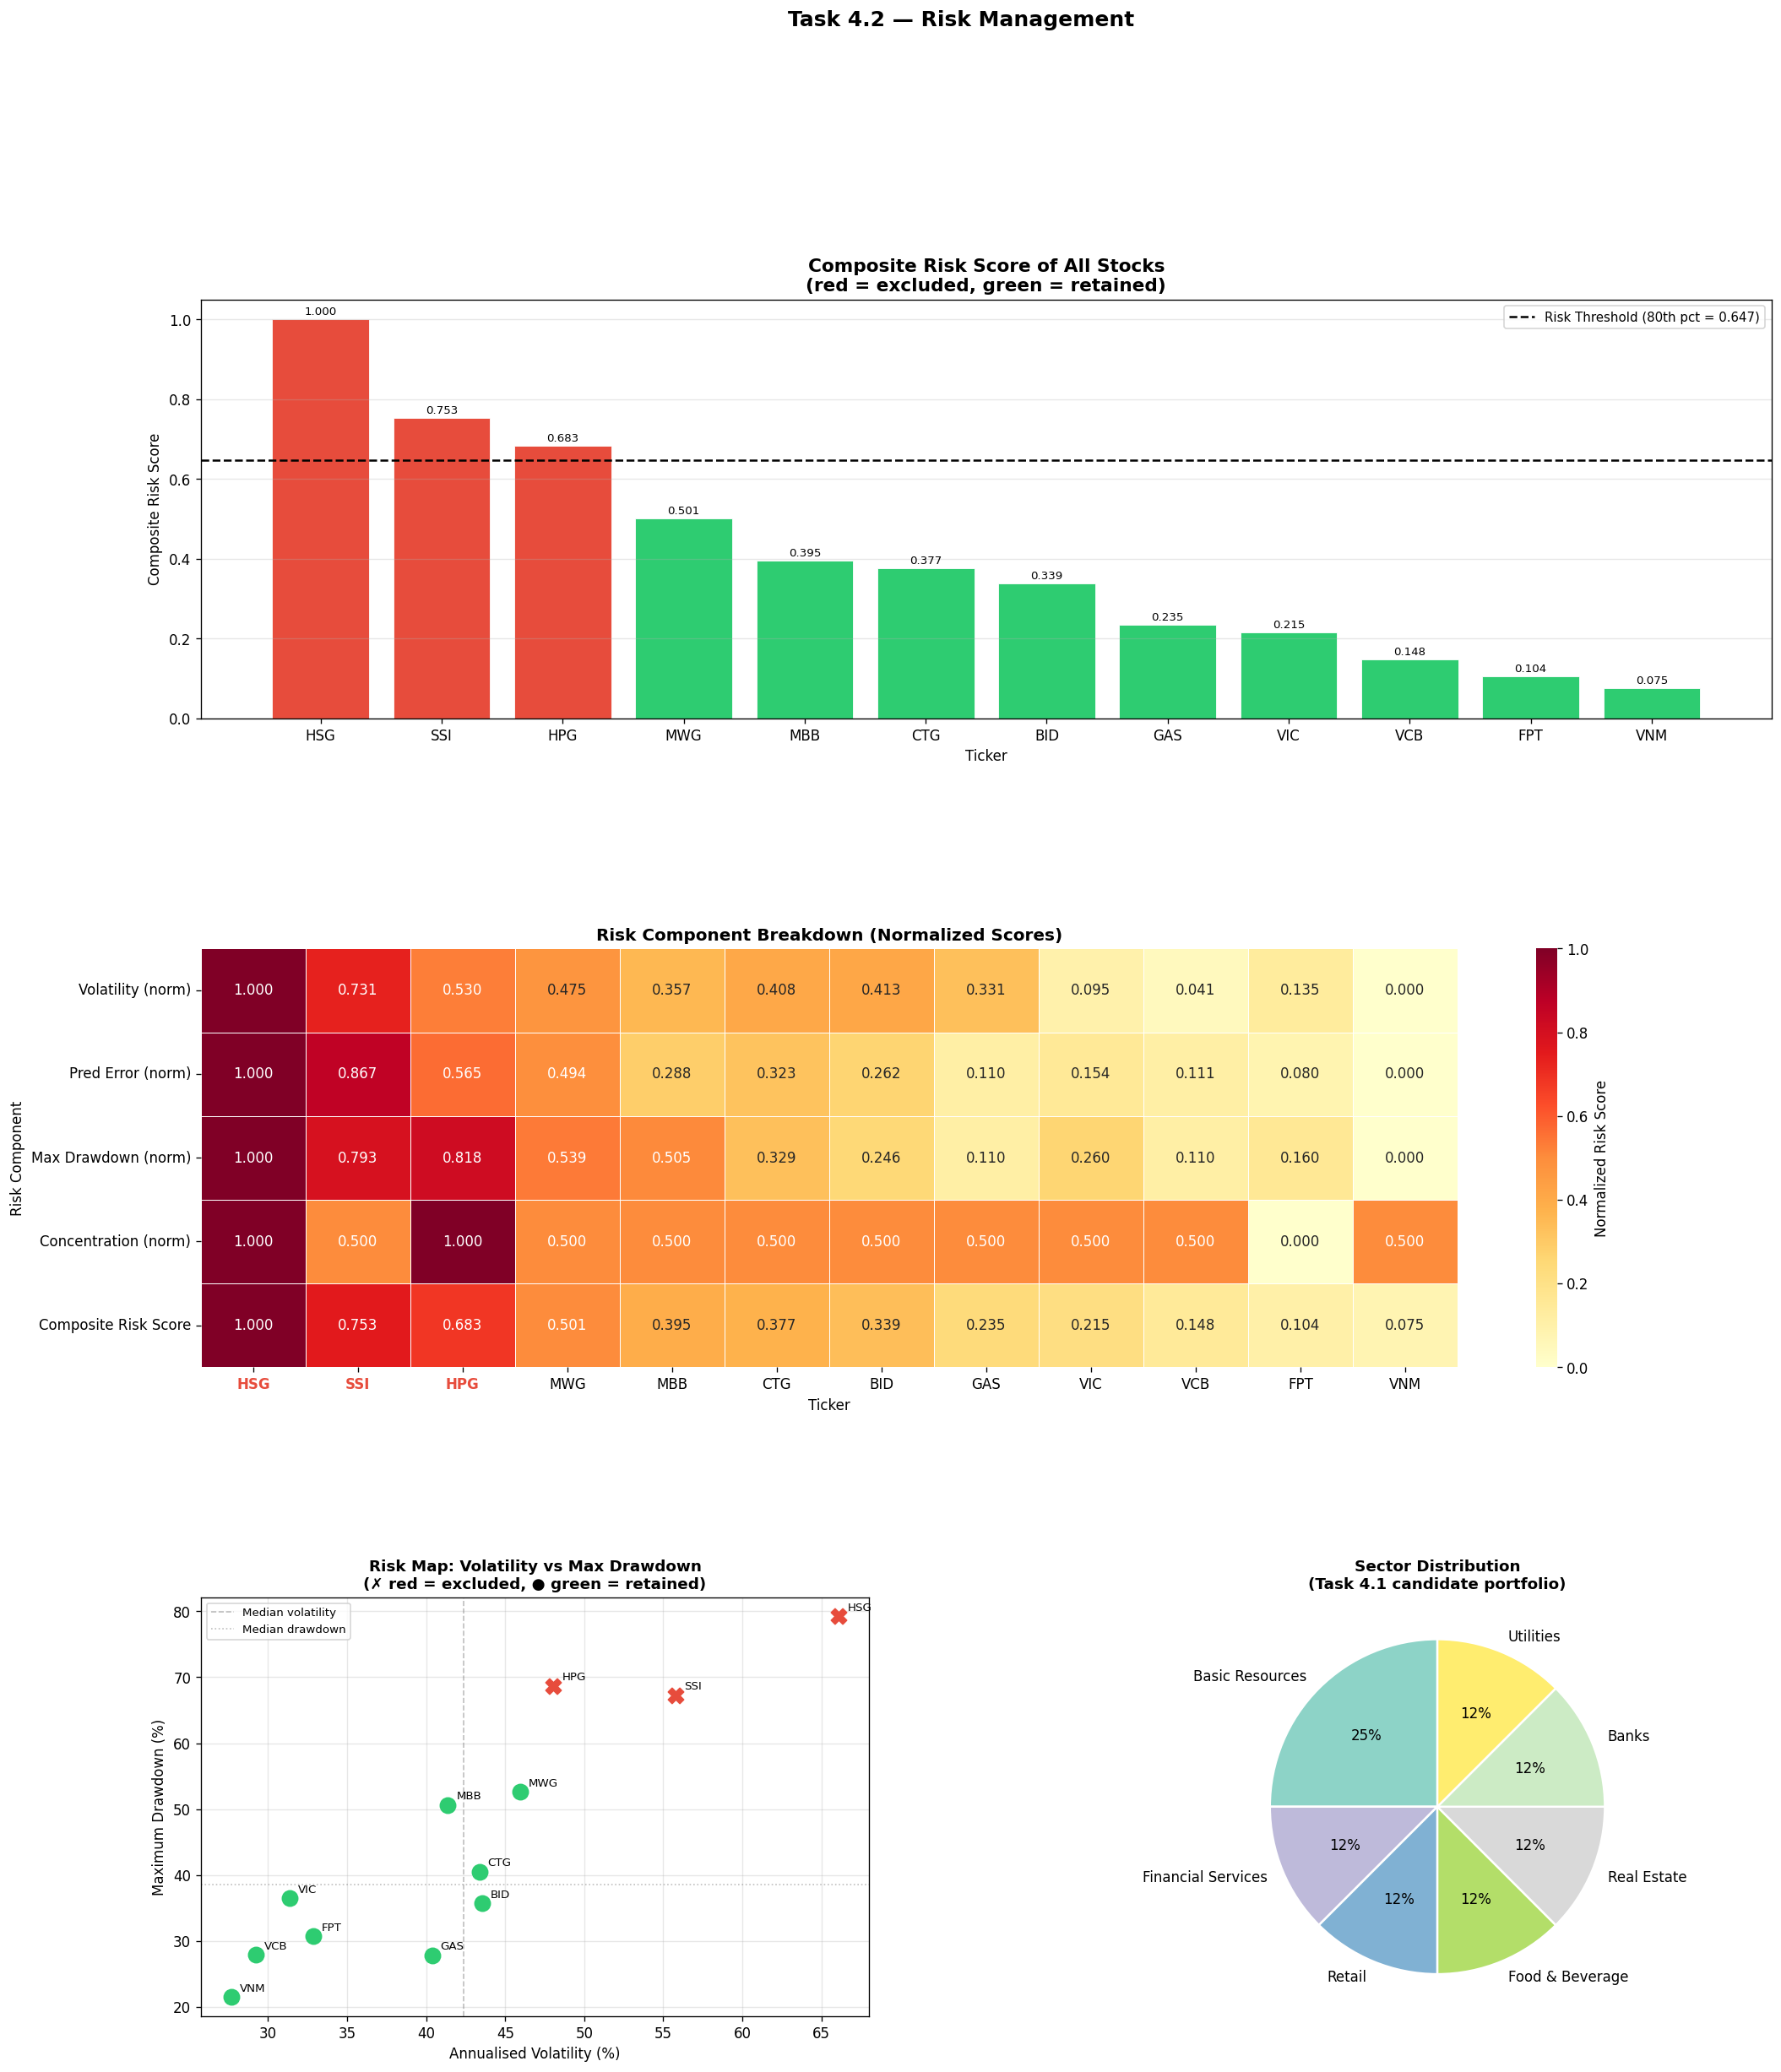

Figure saved → task4_portfolio/task4_2_risk_management.png
TASK 4.2 SUMMARY
  Total evaluated  : 12 stocks
  Risk components     : volatility (0.3), pred error (0.3), drawdown (0.25), concentration (0.15)
  Risk threshold      : 0.6465 (80th percentile)
  Excluded (too risky): ['HSG', 'SSI', 'HPG']
  Retained (safe)     : ['MWG', 'VNM', 'VIC', 'BID', 'GAS']
  Outputs saved to    : task4_portfolio/


In [ ]:
# STEP 9: VISUALIZATIONS

fig = plt.figure(figsize=(20, 22), dpi=120)
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)

# Colour coding: red = too risky, green = safe
bar_colors = [
    "#e74c3c" if row["Too Risky"] else "#2ecc71"
    for _, row in risk_df.iterrows()
]

# Panel 1: Composite risk scores of all stocks
ax1 = fig.add_subplot(gs[0, :])   # full width
bars = ax1.bar(
    risk_df["Ticker"],
    risk_df["Composite Risk Score"],
    color=bar_colors, edgecolor="white", linewidth=0.5
)
ax1.axhline(risk_threshold, color="black", linewidth=1.5,
            linestyle="--",
            label=f"Risk Threshold ({RISK_THRESHOLD_PERCENTILE}th pct = {risk_threshold:.3f})")
ax1.set_title("Composite Risk Score of All Stocks\n"
              "(red = excluded, green = retained)",
              fontsize=13, fontweight="bold")
ax1.set_ylabel("Composite Risk Score")
ax1.set_xlabel("Ticker")
ax1.legend(fontsize=9)
ax1.grid(axis="y", alpha=0.3)

# Annotate bars with score values
for bar, val in zip(bars, risk_df["Composite Risk Score"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{val:.3f}",
        ha="center", va="bottom", fontsize=8
    )

# Panel 2: Risk component heatmap
ax2 = fig.add_subplot(gs[1, :])   # full width
heatmap_cols = [
    "Volatility (norm)", "Pred Error (norm)",
    "Max Drawdown (norm)", "Concentration (norm)",
    "Composite Risk Score"
]
heatmap_data = risk_df.set_index("Ticker")[heatmap_cols]

sns.heatmap(
    heatmap_data.T,
    annot=True, fmt=".3f", cmap="YlOrRd",
    linewidths=0.5, linecolor="white",
    ax=ax2, cbar_kws={"label": "Normalized Risk Score"}
)
ax2.set_title("Risk Component Breakdown (Normalized Scores)",
              fontsize=12, fontweight="bold")
ax2.set_xlabel("Ticker")
ax2.set_ylabel("Risk Component")
ax2.tick_params(axis="x", rotation=0)
ax2.tick_params(axis="y", rotation=0)

# Mark excluded tickers on x-axis
for label in ax2.get_xticklabels():
    if label.get_text() in risky_tickers:
        label.set_color("#e74c3c")
        label.set_fontweight("bold")

# Panel 3: Volatility vs Max Drawdown scatter
ax3 = fig.add_subplot(gs[2, 0])
for _, row in risk_df.iterrows():
    color  = "#e74c3c" if row["Too Risky"] else "#2ecc71"
    marker = "X" if row["Too Risky"] else "o"
    ax3.scatter(
        row["Volatility (raw)"] * 100,
        row["Max Drawdown (raw)"] * 100,
        color=color, marker=marker, s=120, zorder=3
    )
    ax3.annotate(
        row["Ticker"],
        (row["Volatility (raw)"] * 100,
         row["Max Drawdown (raw)"] * 100),
        textcoords="offset points",
        xytext=(6, 4), fontsize=8
    )

ax3.set_xlabel("Annualised Volatility (%)")
ax3.set_ylabel("Maximum Drawdown (%)")
ax3.set_title("Risk Map: Volatility vs Max Drawdown\n"
              "(✗ red = excluded, ● green = retained)",
              fontsize=11, fontweight="bold")
ax3.grid(alpha=0.3)

# Add quadrant lines at median values
med_vol = np.median([v * 100 for v in volatility_scores.values()])
med_mdd = np.median([v * 100 for v in drawdown_scores.values()])
ax3.axvline(med_vol, color="gray", linestyle="--",
            alpha=0.5, linewidth=1, label="Median volatility")
ax3.axhline(med_mdd, color="gray", linestyle=":",
            alpha=0.5, linewidth=1, label="Median drawdown")
ax3.legend(fontsize=8)

# ── Panel 4: Sector distribution of candidate portfolio ───────
ax4 = fig.add_subplot(gs[2, 1])
candidate_sectors = [
    sector_map.get(t, "Unknown") for t in CANDIDATE_TICKERS
]
sector_counts = pd.Series(candidate_sectors).value_counts()

wedge_colors = plt.cm.Set3(np.linspace(0, 1, len(sector_counts)))
ax4.pie(
    sector_counts.values,
    labels=sector_counts.index,
    autopct="%1.0f%%",
    colors=wedge_colors,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
ax4.set_title("Sector Distribution\n(Task 4.1 candidate portfolio)",
              fontsize=11, fontweight="bold")

plt.suptitle("Task 4.2 — Risk Management",
             fontsize=15, fontweight="bold", y=1.01)

fig_path = os.path.join(SAVE_DIR, "task4_2_risk_management.png")
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Figure saved → {fig_path}")


# Task 4.2 summary
print("TASK 4.2 SUMMARY")
print("=" * 60)
print(f"  Total evaluated  : {len(TICKERS)} stocks")
print(f"  Risk components     : volatility ({WEIGHT_VOLATILITY}), "
      f"pred error ({WEIGHT_PRED_ERROR}), "
      f"drawdown ({WEIGHT_DRAWDOWN}), "
      f"concentration ({WEIGHT_CONCENTRATION})")
print(f"  Risk threshold      : {risk_threshold:.4f} "
      f"({RISK_THRESHOLD_PERCENTILE}th percentile)")
print(f"  Excluded (too risky): {risky_tickers}")
print(f"  Retained (safe)     : {FINAL_TICKERS}")
print(f"  Outputs saved to    : {SAVE_DIR}/")

## Task 4.3 - Portfolio composition


Portfolio is used in finances to diversify the stock. Diversification theoretically lowers the risk.

Portfolio composition is subjective to investors' preference (risk loving or risk averse or risk neutral).

We explore two ways to build portfolio: (1) all equal weight, and (2) risk-adjusted weight. The second approach is expected to have a higher return.

In [ ]:
# STEP 1: LOAD INPUTS FROM TASK 4.1 & 4.2

SAVE_DIR = "task4_portfolio"

# Load expected returns from Task 4.1
with open(os.path.join(SAVE_DIR, "task4_1_portfolio_config.json")) as f:
    portfolio_config = json.load(f)

# Load risk scores from Task 4.2
with open(os.path.join(SAVE_DIR, "task4_2_risk_config.json")) as f:
    risk_config = json.load(f)

FINAL_TICKERS = risk_config["final_tickers"]

print(f"Final tickers for portfolio construction: {FINAL_TICKERS}")


Final tickers for portfolio construction: ['MWG', 'VNM', 'VIC', 'BID', 'GAS']


In [ ]:
# STEP 2. PREPARE RETURN & RISK VECTORS

# For each final ticker, extract:
# - Expected return (from Task 4.1)
# - Composite risk score (from Task 4.2)

portfolio_inputs = []

for ticker in FINAL_TICKERS:
    ret_info  = portfolio_config["returns"][ticker]
    risk_info = risk_config["risk_scores"][ticker]

    portfolio_inputs.append({
        "Ticker": ticker,
        "Expected Return": ret_info["total_return"],
        "Risk Score": risk_info["composite"],
        "Sector": risk_info["sector"],
    })

portfolio_inputs_df = pd.DataFrame(portfolio_inputs)
print("\nPortfolio inputs:")
print(portfolio_inputs_df.to_markdown(index=False, floatfmt=".4f"))



Portfolio inputs:
| Ticker   |   Expected Return |   Risk Score | Sector          |
|:---------|------------------:|-------------:|:----------------|
| MWG      |            2.4812 |       0.5005 | Retail          |
| VNM      |            1.7506 |       0.0750 | Food & Beverage |
| VIC      |            1.1409 |       0.2149 | Real Estate     |
| BID      |            1.1178 |       0.3391 | Banks           |
| GAS      |            0.7544 |       0.2345 | Utilities       |


In [ ]:
# STEP 3: EQUAL WEIGHT PORTFOLIO

n_stocks = len(portfolio_inputs_df)

portfolio_inputs_df["Equal Weight"] = 1.0 / n_stocks

print("\nEqual-weight portfolio:")
print(
    portfolio_inputs_df[["Ticker", "Equal Weight"]]
    .to_markdown(index=False, floatfmt=".4f")
)



Equal-weight portfolio:
| Ticker   |   Equal Weight |
|:---------|---------------:|
| MWG      |         0.2000 |
| VNM      |         0.2000 |
| VIC      |         0.2000 |
| BID      |         0.2000 |
| GAS      |         0.2000 |


In [ ]:
# STEP 4: RISK-ADJUSTED SCORE COMPUTATION

# score_i = expected_return_i / (risk_i + epsilon)
# Higher return and lower risk lead to higher allocation.

EPSILON = 1e-6

portfolio_inputs_df["Risk-Adjusted Score"] = (
    portfolio_inputs_df["Expected Return"] /
    (portfolio_inputs_df["Risk Score"] + EPSILON)
)

print("\nRisk-adjusted scores:")
print(
    portfolio_inputs_df[["Ticker", "Risk-Adjusted Score"]]
    .to_markdown(index=False, floatfmt=".4f")
)


Risk-adjusted scores:
| Ticker   |   Risk-Adjusted Score |
|:---------|----------------------:|
| MWG      |                4.9570 |
| VNM      |               23.3416 |
| VIC      |                5.3097 |
| BID      |                3.2968 |
| GAS      |                3.2168 |


In [ ]:
# STEP 5: CONVERT SCORES TO PORTFOLIO WEIGHTS
# Normalize scores so that sum = 1

total_score = portfolio_inputs_df["Risk-Adjusted Score"].sum()

portfolio_inputs_df["Risk-Adjusted Weight"] = (
    portfolio_inputs_df["Risk-Adjusted Score"] / total_score
)

print("\nRisk-adjusted portfolio weights:")
print(
    portfolio_inputs_df[["Ticker", "Risk-Adjusted Weight"]]
    .to_markdown(index=False, floatfmt=".4f")
)


Risk-adjusted portfolio weights:
| Ticker   |   Risk-Adjusted Weight |
|:---------|-----------------------:|
| MWG      |                 0.1235 |
| VNM      |                 0.5818 |
| VIC      |                 0.1323 |
| BID      |                 0.0822 |
| GAS      |                 0.0802 |


Intuition: The pupose of portfolio is to diversify the invested stocks, thereby reducing the risk. One stock with much higher weight may weaken the diversification effect.

In [ ]:
# STEP 6. ADDITIONAL MAX WEIGHT CONSTRAINT
# To avoid excessive concentration in one stock, we cap individual weights and renormalize.

MAX_WEIGHT = 0.40 # no ticker can exceed this weight

weights = portfolio_inputs_df["Risk-Adjusted Weight"].values
weights = np.minimum(weights, MAX_WEIGHT)
weights = weights / weights.sum()

portfolio_inputs_df["Capped Weight"] = weights

print("\nRisk-adjusted portfolio with max-weight constraint:")
print(
    portfolio_inputs_df[["Ticker", "Capped Weight"]]
    .to_markdown(index=False, floatfmt=".4f")
)


Risk-adjusted portfolio with max-weight constraint:
| Ticker   |   Capped Weight |
|:---------|----------------:|
| MWG      |          0.1510 |
| VNM      |          0.4889 |
| VIC      |          0.1617 |
| BID      |          0.1004 |
| GAS      |          0.0980 |


VNM's weight is greater than 40%, so we cap and renormalize weight to reduce VNM's weight (there is no guarantee that after normalizing every weight does not exceed 0.4). If we really want to compress the weight of VNM, we can cap once more. While it is better theoretically for diversification purpose, the downside is that it may reduce the expected portfolio return.

In [ ]:
# STEP 7: PORTFOLIO-LEVEL METRICS
# Compute portfolio expected return using final weights.

portfolio_return = np.sum(
    portfolio_inputs_df["Capped Weight"] *
    portfolio_inputs_df["Expected Return"]
)

print(f"\nExpected portfolio return (risk-adjusted): {portfolio_return:.2%}")



Expected portfolio return (risk-adjusted): 160.12%


In [ ]:
from google.colab import files
files.download("task2_3_vietnam_model.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>